# FIS-Based Spatially Variable DoD Uncertainty v1

This notebook applies a rule-based Mamdani fuzzy inference system to estimate spatially variable DEM vertical uncertainty and filter a DEM of Difference (DoD) by a 95% confidence threshold.

This is not a trained ML model. It is a rule-based uncertainty filter using:

- slope in degrees
- LiDAR point density in pts/m2
- canopy cover percentage

The v1 paths are centralized below and point to the Thomas data directory plus the `fis_inputs` directory created by `FIS_setting_slope_density_vege_v1.ipynb`.


In [12]:
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

BASE_DIR = Path("/mnt/c/Users/amehedi/Downloads/thomas")
FIS_INPUT_DIR = BASE_DIR / "fis_inputs"
OUT_DIR = BASE_DIR / "fis_dod_uncertainty_v1"
PLOT_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEM_POST_PATH = BASE_DIR / "dem_post.tif"
DEM_PRE_PATH = BASE_DIR / "dem_pre.tif"

# Preferred DoD. If this file is missing, the notebook falls back to DEM_post - DEM_pre.
DOD_PATH = BASE_DIR / "dem_diff_updated.tif"
USE_DOD_RASTER = True

SLOPE_POST_PATH = FIS_INPUT_DIR / "slope_10m_post.tif"
SLOPE_PRE_PATH = FIS_INPUT_DIR / "slope_10m_pre.tif"
POINT_DENSITY_PATH = FIS_INPUT_DIR / "point_density_10m.tif"
CANOPY_PATH = FIS_INPUT_DIR / "canopy_2019_10m.tif"

UNCERTAINTY_POST_PATH = OUT_DIR / "uncertainty_dem_post.tif"
UNCERTAINTY_PRE_PATH = OUT_DIR / "uncertainty_dem_pre.tif"
DOD_USED_PATH = OUT_DIR / "dod_used.tif"
THRESHOLD_PATH = OUT_DIR / "threshold_surface_95ci.tif"
DOD_FILTERED_PATH = OUT_DIR / "dod_filtered_fis_95ci.tif"
SIGNIFICANT_MASK_PATH = OUT_DIR / "significant_change_mask_95ci.tif"

NODATA_FLOAT = -9999.0
NODATA_UINT8 = 255
REUSE_EXISTING_UNCERTAINTY = False

for label, path in {
    "DEM post": DEM_POST_PATH,
    "DEM pre": DEM_PRE_PATH,
    "DoD raster": DOD_PATH,
    "slope post": SLOPE_POST_PATH,
    "slope pre": SLOPE_PRE_PATH,
    "point density": POINT_DENSITY_PATH,
    "canopy": CANOPY_PATH,
}.items():
    print(f"{label}: {path} exists={path.exists()}")

print("output folder:", OUT_DIR)

DEM post: /mnt/c/Users/amehedi/Downloads/thomas/dem_post.tif exists=True
DEM pre: /mnt/c/Users/amehedi/Downloads/thomas/dem_pre.tif exists=True
DoD raster: /mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif exists=True
slope post: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/slope_10m_post.tif exists=True
slope pre: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/slope_10m_pre.tif exists=True
point density: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/point_density_10m.tif exists=True
canopy: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/canopy_2019_10m.tif exists=True
output folder: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1


## 1. Build The FIS

The point-density `high` membership is trapezoidal in v1 so a QL2 value of `1.0 pts/m2` is treated as high density, consistent with the notebook comments. The membership and centroid operations are implemented directly with NumPy, so this notebook does not require scikit-fuzzy.


In [13]:
def trimf(x, abc):
    a, b, c = map(float, abc)
    x = np.asarray(x, dtype="float64")
    y = np.zeros_like(x, dtype="float64")

    if b != a:
        left = (a < x) & (x < b)
        y[left] = (x[left] - a) / (b - a)
    y[x == b] = 1.0

    if c != b:
        right = (b < x) & (x < c)
        y[right] = (c - x[right]) / (c - b)

    if a == b:
        y[x <= b] = 1.0
    if b == c:
        y[x >= b] = 1.0

    return np.clip(y, 0.0, 1.0)


def trapmf(x, abcd):
    a, b, c, d = map(float, abcd)
    x = np.asarray(x, dtype="float64")
    y = np.zeros_like(x, dtype="float64")

    if b != a:
        rising = (a < x) & (x < b)
        y[rising] = (x[rising] - a) / (b - a)
    else:
        y[x <= b] = 1.0

    plateau = (b <= x) & (x <= c)
    y[plateau] = 1.0

    if d != c:
        falling = (c < x) & (x < d)
        y[falling] = (d - x[falling]) / (d - c)
    else:
        y[x >= c] = 1.0

    return np.clip(y, 0.0, 1.0)


def interp_membership(x, mf, value):
    return float(np.interp(float(value), x, mf, left=mf[0], right=mf[-1]))


def integrate_trapezoid(y, x):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)


def defuzz_centroid(x, mf):
    total = integrate_trapezoid(mf, x)
    if total <= 0 or not np.isfinite(total):
        return np.nan
    return float(integrate_trapezoid(x * mf, x) / total)


def build_fis():
    slope_range = np.arange(0, 91, 0.1)       # degrees
    density_range = np.arange(0, 5.1, 0.01)   # pts/m2
    canopy_range = np.arange(0, 101, 0.1)     # percent
    dz_range = np.arange(0, 1.01, 0.001)      # metres

    slope_lo = trimf(slope_range, [0, 0, 15])
    slope_md = trimf(slope_range, [5, 25, 45])
    slope_hi = trimf(slope_range, [30, 90, 90])

    density_lo = trapmf(density_range, [0, 0, 0.25, 0.6])
    density_md = trimf(density_range, [0.3, 0.8, 1.5])
    density_hi = trapmf(density_range, [0.8, 1.0, 5.0, 5.0])

    canopy_lo = trimf(canopy_range, [0, 0, 25])
    canopy_md = trimf(canopy_range, [10, 40, 70])
    canopy_hi = trimf(canopy_range, [50, 100, 100])

    dz_low = trimf(dz_range, [0.00, 0.05, 0.10])
    dz_avg = trimf(dz_range, [0.05, 0.10, 0.20])
    dz_high = trimf(dz_range, [0.10, 0.20, 0.35])
    dz_extreme = trimf(dz_range, [0.25, 0.50, 1.00])

    return {
        "slope_range": slope_range,
        "density_range": density_range,
        "canopy_range": canopy_range,
        "dz_range": dz_range,
        "slope": (slope_lo, slope_md, slope_hi),
        "density": (density_lo, density_md, density_hi),
        "canopy": (canopy_lo, canopy_md, canopy_hi),
        "dz": (dz_low, dz_avg, dz_high, dz_extreme),
    }


def apply_fis_rules(slope_val, density_val, canopy_val, fis):
    sr = fis["slope_range"]
    dr = fis["density_range"]
    cr = fis["canopy_range"]
    dzr = fis["dz_range"]

    s_lo, s_md, s_hi = fis["slope"]
    d_lo, d_md, d_hi = fis["density"]
    c_lo, c_md, c_hi = fis["canopy"]
    dz_low, dz_avg, dz_high, dz_ext = fis["dz"]

    slope_val = np.clip(slope_val, 0, 90)
    density_val = np.clip(density_val, 0, 5)
    canopy_val = np.clip(canopy_val, 0, 100)

    s = [
        interp_membership(sr, s_lo, slope_val),
        interp_membership(sr, s_md, slope_val),
        interp_membership(sr, s_hi, slope_val),
    ]
    d = [
        interp_membership(dr, d_lo, density_val),
        interp_membership(dr, d_md, density_val),
        interp_membership(dr, d_hi, density_val),
    ]
    c = [
        interp_membership(cr, c_lo, canopy_val),
        interp_membership(cr, c_md, canopy_val),
        interp_membership(cr, c_hi, canopy_val),
    ]

    rules = [
        (0, 2, 0, dz_low),
        (0, 2, 1, dz_avg),
        (0, 2, 2, dz_avg),
        (0, 1, 0, dz_avg),
        (0, 1, 2, dz_high),
        (0, 0, 0, dz_avg),
        (0, 0, 2, dz_high),
        (1, 2, 0, dz_avg),
        (1, 2, 2, dz_high),
        (1, 1, 1, dz_high),
        (1, 0, 2, dz_ext),
        (2, 2, 0, dz_high),
        (2, 2, 2, dz_ext),
        (2, 1, 1, dz_ext),
        (2, 0, 0, dz_high),
        (2, 0, 2, dz_ext),
    ]

    aggregated = np.zeros_like(dzr)
    for si, di, ci, out_mf in rules:
        firing = min(s[si], d[di], c[ci])
        if firing > 0:
            aggregated = np.maximum(aggregated, np.minimum(firing, out_mf))

    if aggregated.sum() == 0:
        return 0.10
    value = defuzz_centroid(dzr, aggregated)
    if not np.isfinite(value):
        return 0.10
    return value


fis = build_fis()
print("FIS built")


FIS built


## 2. Raster Helpers


In [14]:
def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        profile = src.profile.copy()
        nodata = src.nodata

    invalid = ~np.isfinite(data)
    if nodata is not None:
        invalid |= np.isclose(data, nodata)
    data[invalid] = np.nan
    return data, profile


def load_and_align(src_path, ref_profile, ref_shape, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        same_shape = src.shape == ref_shape
        same_crs = src.crs == ref_profile["crs"]
        same_transform = src.transform.almost_equals(ref_profile["transform"])

        if same_shape and same_crs and same_transform:
            data = src.read(1).astype("float32")
        else:
            data = np.full(ref_shape, np.nan, dtype="float32")
            reproject(
                source=rasterio.band(src, 1),
                destination=data,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_profile["transform"],
                dst_crs=ref_profile["crs"],
                dst_nodata=np.nan,
                resampling=resampling,
            )

        nodata = src.nodata

    invalid = ~np.isfinite(data)
    if nodata is not None:
        invalid |= np.isclose(data, nodata)
    data[invalid] = np.nan
    return data


def write_float_raster(path, array, profile, nodata=NODATA_FLOAT):
    data = np.asarray(array, dtype="float32")
    out = np.where(np.isfinite(data), data, nodata).astype("float32")

    meta = profile.copy()
    meta.update(driver="GTiff", dtype="float32", count=1, nodata=nodata, compress="deflate")
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    return path


def write_uint8_raster(path, array, profile, nodata=NODATA_UINT8):
    data = np.asarray(array, dtype="uint8")
    meta = profile.copy()
    meta.update(driver="GTiff", dtype="uint8", count=1, nodata=nodata, compress="deflate")
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(data, 1)
    return path


## 3. Load Inputs


In [15]:
dem_post, profile = read_raster(DEM_POST_PATH)
dem_pre = load_and_align(DEM_PRE_PATH, profile, dem_post.shape)
slope_post = load_and_align(SLOPE_POST_PATH, profile, dem_post.shape)
slope_pre = load_and_align(SLOPE_PRE_PATH, profile, dem_post.shape)
point_density = load_and_align(POINT_DENSITY_PATH, profile, dem_post.shape)
canopy = load_and_align(CANOPY_PATH, profile, dem_post.shape)

valid_dem = np.isfinite(dem_post) & np.isfinite(dem_pre)

slope_post = np.nan_to_num(slope_post, nan=0.0)
slope_pre = np.nan_to_num(slope_pre, nan=0.0)
point_density = np.nan_to_num(point_density, nan=1.0)
canopy = np.nan_to_num(canopy, nan=0.0)

print("shape:", dem_post.shape)
print("valid DEM pixels:", int(valid_dem.sum()))
print("slope post min/max:", float(np.nanmin(slope_post)), float(np.nanmax(slope_post)))
print("slope pre min/max:", float(np.nanmin(slope_pre)), float(np.nanmax(slope_pre)))
print("density min/max:", float(np.nanmin(point_density)), float(np.nanmax(point_density)))
print("canopy min/max:", float(np.nanmin(canopy)), float(np.nanmax(canopy)))


shape: (835, 716)
valid DEM pixels: 529116
slope post min/max: 0.0 63.32152557373047
slope pre min/max: 0.0 62.51799392700195
density min/max: 1.0 1.0
canopy min/max: 0.0 89.6342544555664


## 4. Apply FIS Pixel By Pixel

This can take several minutes for a full 10 m grid.


In [16]:
def compute_uncertainty_surface(slope, density, canopy, valid_mask, fis):
    uncertainty = np.full(slope.shape, np.nan, dtype="float32")
    valid_idx = np.argwhere(valid_mask)

    for row, col in tqdm(valid_idx, desc="FIS pixels"):
        uncertainty[row, col] = apply_fis_rules(
            float(slope[row, col]),
            float(density[row, col]),
            float(canopy[row, col]),
            fis,
        )

    return uncertainty


if REUSE_EXISTING_UNCERTAINTY and UNCERTAINTY_POST_PATH.exists() and UNCERTAINTY_PRE_PATH.exists():
    uncertainty_post, _ = read_raster(UNCERTAINTY_POST_PATH)
    uncertainty_pre, _ = read_raster(UNCERTAINTY_PRE_PATH)
    print("reused existing uncertainty rasters")
else:
    uncertainty_post = compute_uncertainty_surface(slope_post, point_density, canopy, valid_dem, fis)
    uncertainty_pre = compute_uncertainty_surface(slope_pre, point_density, canopy, valid_dem, fis)

print("uncertainty post mean/max:", float(np.nanmean(uncertainty_post)), float(np.nanmax(uncertainty_post)))
print("uncertainty pre mean/max:", float(np.nanmean(uncertainty_pre)), float(np.nanmax(uncertainty_pre)))

FIS pixels:   0%|          | 0/529116 [00:00<?, ?it/s]

FIS pixels:   0%|          | 0/529116 [00:00<?, ?it/s]

uncertainty post mean/max: 0.23033423721790314 0.610119640827179
uncertainty pre mean/max: 0.22932113707065582 0.6101193428039551


## 5. Propagate Uncertainty And Filter DoD

The 95% confidence threshold is:

`threshold = 1.96 * sqrt(uncertainty_post**2 + uncertainty_pre**2)`

A DoD pixel is retained only where `abs(DoD) >= threshold`.


In [17]:
if USE_DOD_RASTER and DOD_PATH.exists():
    dod_raw = load_and_align(DOD_PATH, profile, dem_post.shape)
    dod_source = str(DOD_PATH)
else:
    dod_raw = dem_post - dem_pre
    dod_source = "DEM_post - DEM_pre"

threshold_surface = 1.96 * np.sqrt(uncertainty_post**2 + uncertainty_pre**2)

valid = valid_dem & np.isfinite(dod_raw) & np.isfinite(threshold_surface)
significant = valid & (np.abs(dod_raw) >= threshold_surface)

significant_mask = np.full(dod_raw.shape, NODATA_UINT8, dtype="uint8")
significant_mask[valid] = 0
significant_mask[significant] = 1

dod_filtered = np.full(dod_raw.shape, np.nan, dtype="float32")
dod_filtered[significant] = dod_raw[significant]

print("DoD source:", dod_source)
print("valid pixels:", int(valid.sum()))
print("mean threshold:", float(np.nanmean(threshold_surface[valid])))
print("significant pixels:", int(significant.sum()), f"({100 * significant.sum() / max(valid.sum(), 1):.1f}%)")
print("masked pixels:", int((valid & ~significant).sum()))
print("retained erosion pixels:", int(np.sum(dod_filtered < 0)))
print("retained deposition pixels:", int(np.sum(dod_filtered > 0)))


DoD source: /mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif
valid pixels: 528494
mean threshold: 0.6377748250961304
significant pixels: 28380 (5.4%)
masked pixels: 500114
retained erosion pixels: 22825
retained deposition pixels: 5555


## 6. Save Rasters


In [18]:
write_float_raster(UNCERTAINTY_POST_PATH, uncertainty_post, profile)
write_float_raster(UNCERTAINTY_PRE_PATH, uncertainty_pre, profile)
write_float_raster(DOD_USED_PATH, dod_raw, profile)
write_float_raster(THRESHOLD_PATH, threshold_surface, profile)
write_float_raster(DOD_FILTERED_PATH, dod_filtered, profile)
write_uint8_raster(SIGNIFICANT_MASK_PATH, significant_mask, profile)

for path in [
    UNCERTAINTY_POST_PATH,
    UNCERTAINTY_PRE_PATH,
    DOD_USED_PATH,
    THRESHOLD_PATH,
    DOD_FILTERED_PATH,
    SIGNIFICANT_MASK_PATH,
]:
    print("saved:", path)


saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/uncertainty_dem_post.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/uncertainty_dem_pre.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/dod_used.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/threshold_surface_95ci.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/dod_filtered_fis_95ci.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/significant_change_mask_95ci.tif


## 7. Plot Results


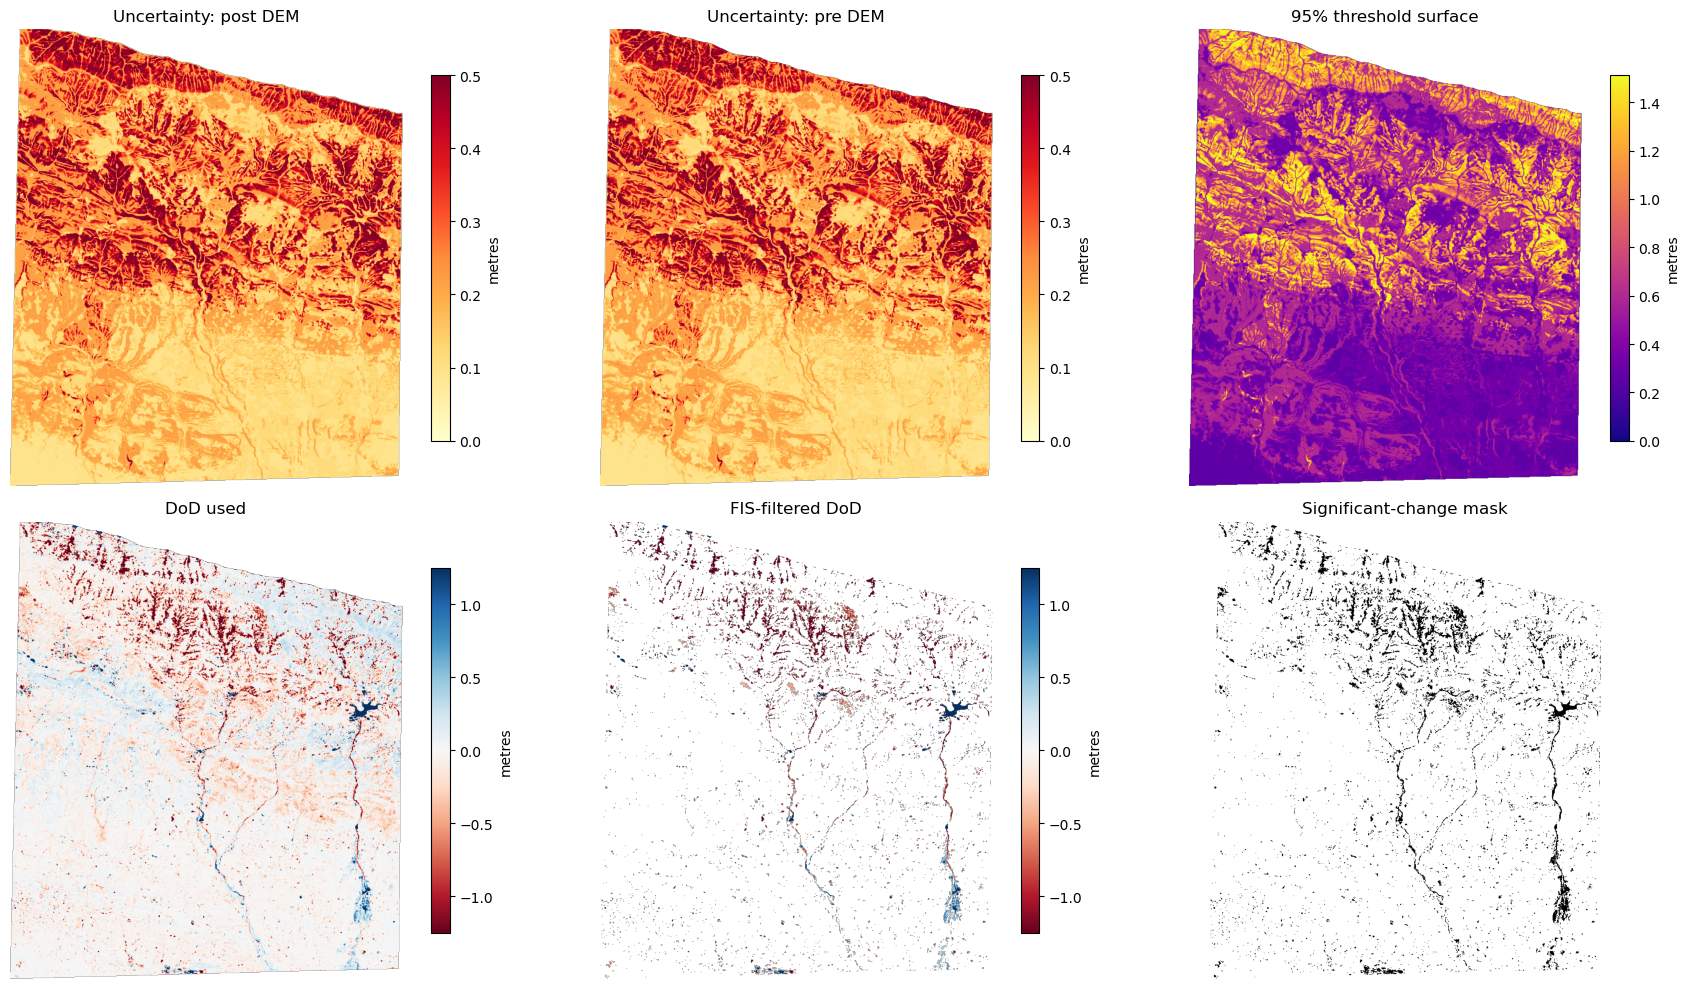

saved plot: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/plots/dod_fis_results_v1.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im0 = axes[0, 0].imshow(uncertainty_post, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0, 0].set_title("Uncertainty: post DEM")
plt.colorbar(im0, ax=axes[0, 0], label="metres", shrink=0.8)

im1 = axes[0, 1].imshow(uncertainty_pre, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0, 1].set_title("Uncertainty: pre DEM")
plt.colorbar(im1, ax=axes[0, 1], label="metres", shrink=0.8)

im2 = axes[0, 2].imshow(threshold_surface, cmap="plasma", vmin=0, vmax=np.nanpercentile(threshold_surface[valid], 98))
axes[0, 2].set_title("95% threshold surface")
plt.colorbar(im2, ax=axes[0, 2], label="metres", shrink=0.8)

vmax = np.nanpercentile(np.abs(dod_raw[valid]), 98)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im3 = axes[1, 0].imshow(dod_raw, cmap="RdBu", norm=norm)
axes[1, 0].set_title("DoD used")
plt.colorbar(im3, ax=axes[1, 0], label="metres", shrink=0.8)

im4 = axes[1, 1].imshow(dod_filtered, cmap="RdBu", norm=norm)
axes[1, 1].set_title("FIS-filtered DoD")
plt.colorbar(im4, ax=axes[1, 1], label="metres", shrink=0.8)

im5 = axes[1, 2].imshow(np.where(significant_mask == 1, 1, np.nan), cmap="gray")
axes[1, 2].set_title("Significant-change mask")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plot_path = PLOT_DIR / "dod_fis_results_v1.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved plot:", plot_path)


## 8. Elevation Change Distribution Diagnostics


valid filtered pixels: 28380
erosion pixels: 22825 (80.4%)
deposition pixels: 5555 (19.6%)
mean: -0.6193355085439797
std: 2.6915482549020977
median: -0.7550375759601593
min/max: -15.340500831604004 31.307708740234375
skewness: 4.596749907310371
kurtosis: 37.74262333559309


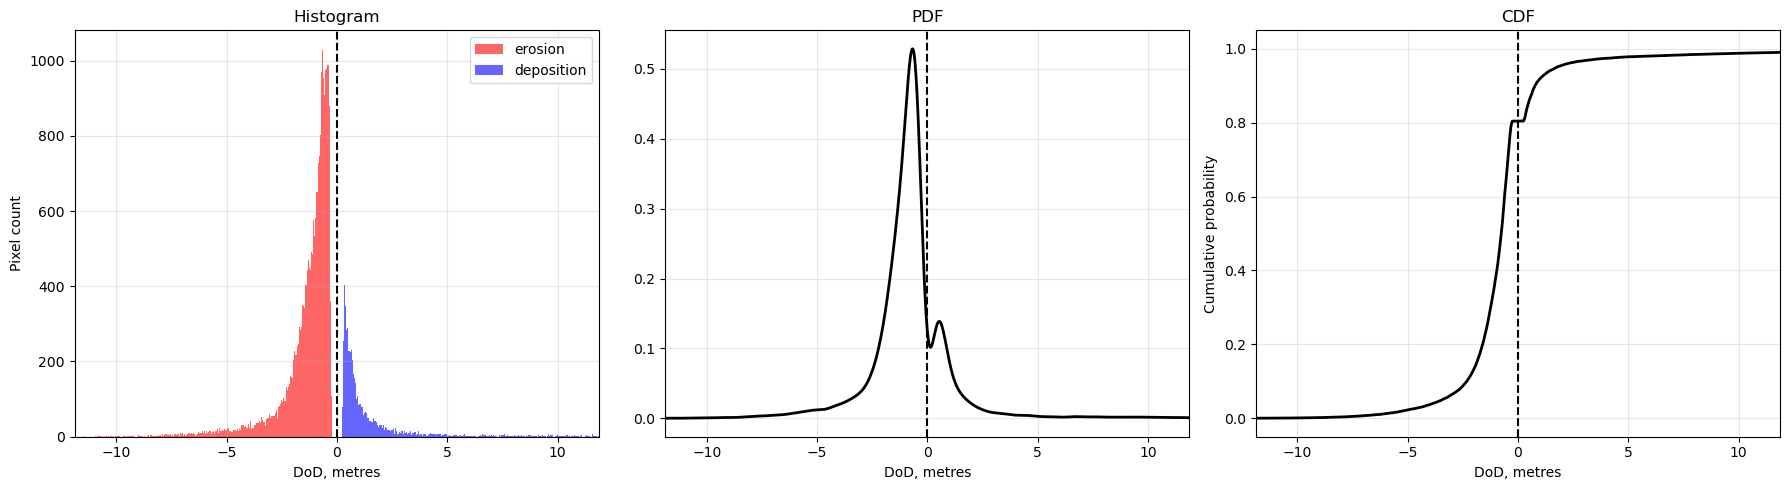

saved ECD plot: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/plots/dod_fis_ecd_analysis_v1.png


In [20]:
from scipy import stats
from scipy.stats import gaussian_kde

values = dod_filtered[np.isfinite(dod_filtered)].astype("float64")
erosion = values[values < 0]
deposition = values[values > 0]

print("valid filtered pixels:", len(values))
if len(values) > 0:
    print("erosion pixels:", len(erosion), f"({100 * len(erosion) / len(values):.1f}%)")
    print("deposition pixels:", len(deposition), f"({100 * len(deposition) / len(values):.1f}%)")
    print("mean:", float(values.mean()))
    print("std:", float(values.std()))
    print("median:", float(np.median(values)))
    print("min/max:", float(values.min()), float(values.max()))
    print("skewness:", float(stats.skew(values)))
    print("kurtosis:", float(stats.kurtosis(values)))

if len(values) > 2:
    clip_val = np.percentile(np.abs(values), 99)
    bins = np.arange(-clip_val, clip_val + 0.05, 0.05)
    x_range = np.linspace(-clip_val, clip_val, 1000)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(erosion, bins=bins, color="red", alpha=0.6, label="erosion")
    axes[0].hist(deposition, bins=bins, color="blue", alpha=0.6, label="deposition")
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("DoD, metres")
    axes[0].set_ylabel("Pixel count")
    axes[0].legend()

    kde_all = gaussian_kde(values, bw_method=0.1)
    axes[1].plot(x_range, kde_all(x_range), color="black", linewidth=2)
    axes[1].axvline(0, color="black", linestyle="--")
    axes[1].set_title("PDF")
    axes[1].set_xlabel("DoD, metres")

    sorted_values = np.sort(values)
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    axes[2].plot(sorted_values, cdf, color="black", linewidth=2)
    axes[2].axvline(0, color="black", linestyle="--")
    axes[2].set_title("CDF")
    axes[2].set_xlabel("DoD, metres")
    axes[2].set_ylabel("Cumulative probability")

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-clip_val, clip_val)

    plt.tight_layout()
    ecd_path = PLOT_DIR / "dod_fis_ecd_analysis_v1.png"
    fig.savefig(ecd_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved ECD plot:", ecd_path)


In [21]:
from ddem_thresholds import run_threshold_analysis

summary = run_threshold_analysis(
    thresholds=(0.01, 0.03, 0.05, 0.08, 0.10, 0.25, 0.50, 1.00)
)

summary

CPLE_AppDefinedError: Deleting /mnt/c/Users/amehedi/Downloads/thomas/erosion_threshold_0p01m.tif failed: Permission denied

In [ ]:
from pathlib import Path
import numpy as np
import rasterio
from scipy.ndimage import generic_filter

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Easy controls
# --------------------
OUT = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_DIFF = OUT / "dem_diff.tif"
DEM_BEFORE = OUT / "dem_pre.tif"
DEM_AFTER = OUT / "dem_post.tif"

WINDOW_SIZE = 5          # change to 5 for 5x5
ALPHA = 1.167
NEGATIVE_THRESHOLD = 0   # percent negative DoD uses DoD < 0

NODATA = -9999.0


# --------------------
# Basic raster helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_raster(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")

    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)


# --------------------
# 1. Moving-window DoD rasters
# --------------------
dem_diff, profile = read_raster(DEM_DIFF)

def nanmean_func(x):
    return np.nanmean(x) if np.isfinite(x).any() else np.nan

def nanmedian_func(x):
    return np.nanmedian(x) if np.isfinite(x).any() else np.nan

def nanstd_func(x):
    return np.nanstd(x) if np.isfinite(x).any() else np.nan

def nanrange_func(x):
    return np.nanmax(x) - np.nanmin(x) if np.isfinite(x).any() else np.nan

def percent_negative_func(x):
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.nan
    return 100 * np.sum(x[valid] < NEGATIVE_THRESHOLD) / valid.sum()

DoD_mean = generic_filter(dem_diff, nanmean_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_median = generic_filter(dem_diff, nanmedian_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_std = generic_filter(dem_diff, nanstd_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_range = generic_filter(dem_diff, nanrange_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_percent_negative = generic_filter(dem_diff, percent_negative_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)

tag = f"{WINDOW_SIZE}x{WINDOW_SIZE}"

write_raster(OUT / f"DoD_mean_{tag}.tif", DoD_mean, profile)
write_raster(OUT / f"DoD_median_{tag}.tif", DoD_median, profile)
write_raster(OUT / f"DoD_std_{tag}.tif", DoD_std, profile)
write_raster(OUT / f"DoD_range_{tag}.tif", DoD_range, profile)
write_raster(OUT / f"DoD_percent_negative_{tag}.tif", DoD_percent_negative, profile)


# --------------------
# 2. Delta-G rasters
# --------------------
def compute_G_from_dem(dem_path, alpha=1.167):
    dem, profile = read_raster(dem_path)

    transform = profile["transform"]
    dx = abs(float(transform.a))
    dy = abs(float(transform.e))

    if not np.isclose(dx, dy):
        raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

    cell_size = dx
    valid = np.isfinite(dem)

    # important: Landlab SinkFillerBarnes needs float64
    z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)

    grid = RasterModelGrid(dem.shape, xy_spacing=cell_size)
    grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

    if not np.all(valid):
        grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

    SinkFillerBarnes(grid, method="Steepest").run_one_step()
    FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()

    S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
    DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

    a = DA / cell_size
    G = a * (np.maximum(S, 0) ** alpha)

    G[~valid] = np.nan

    return G.astype("float32"), profile


G_before, profile_before = compute_G_from_dem(DEM_BEFORE, ALPHA)
G_after, profile_after = compute_G_from_dem(DEM_AFTER, ALPHA)

DeltaG = G_after - G_before
DeltaG_percent = 100 * DeltaG / G_before
DeltaG_percent[~np.isfinite(DeltaG_percent)] = np.nan

write_raster(OUT / "G_before.tif", G_before, profile_before)
write_raster(OUT / "G_after.tif", G_after, profile_after)
write_raster(OUT / "DeltaG.tif", DeltaG, profile_before)
write_raster(OUT / "DeltaG_percent.tif", DeltaG_percent, profile_before)

saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_mean_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_median_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_std_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_range_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_percent_negative_5x5.tif


/tmp/ipykernel_156411/2150340018.py:130: RuntimeWarning: invalid value encountered in divide
  DeltaG_percent = 100 * DeltaG / G_before


saved: /mnt/c/Users/amehedi/Downloads/thomas/G_before.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_after.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG_percent.tif


In [ ]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# --------------------
# Easy controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")
OUT = THOMAS / "cropped_zone_outputs"
OUT.mkdir(exist_ok=True)

zone_files = [
    THOMAS / "montecito_zone_1.shp",
    THOMAS / "montecito_zone_2.shp",
]

raster_files = [
    THOMAS / "DoD_mean_3x3.tif",
    THOMAS / "DoD_median_3x3.tif",
    THOMAS / "DoD_std_3x3.tif",
    THOMAS / "DoD_range_3x3.tif",
    THOMAS / "DoD_percent_negative_3x3.tif",
    THOMAS / "DeltaG.tif",
    THOMAS / "DeltaG_percent.tif",
]

# display ranges for JPGs
display_ranges = {
    "DoD": (-1, 1),
    "DeltaG": (-10, 10),
    "DeltaG_percent": (-100, 100),
    "DoD_percent_negative": (0, 100),
}


def get_display_range(raster_name):
    if "DoD_percent_negative" in raster_name:
        return display_ranges["DoD_percent_negative"]
    if "DeltaG_percent" in raster_name:
        return display_ranges["DeltaG_percent"]
    if "DeltaG" in raster_name:
        return display_ranges["DeltaG"]
    if "DoD" in raster_name:
        return display_ranges["DoD"]
    return (None, None)


for zone_path in zone_files:
    zone_name = zone_path.stem
    zone = gpd.read_file(zone_path)

    for raster_path in raster_files:
        if not raster_path.exists():
            print("missing:", raster_path)
            continue

        with rasterio.open(raster_path) as src:
            # match CRS
            zone_match = zone.to_crs(src.crs)

            cropped, cropped_transform = mask(
                src,
                zone_match.geometry,
                crop=True,
                nodata=src.nodata,
            )

            cropped_arr = cropped[0].astype("float32")

            if src.nodata is not None:
                cropped_arr[cropped_arr == src.nodata] = np.nan

            profile = src.profile.copy()
            profile.update(
                height=cropped_arr.shape[0],
                width=cropped_arr.shape[1],
                transform=cropped_transform,
                compress="lzw",
                nodata=-9999.0,
                dtype="float32",
            )

            out_name = f"{zone_name}_{raster_path.stem}"

            # save cropped GeoTIFF
            out_tif = OUT / f"{out_name}.tif"
            with rasterio.open(out_tif, "w", **profile) as dst:
                dst.write(np.where(np.isfinite(cropped_arr), cropped_arr, -9999.0), 1)

            # save JPG preview
            vmin, vmax = get_display_range(raster_path.name)

            plt.figure(figsize=(7, 5))
            plt.imshow(cropped_arr, cmap="RdBu_r", vmin=vmin, vmax=vmax)
            plt.colorbar(label=raster_path.stem)
            plt.title(out_name)
            plt.axis("off")
            plt.tight_layout()

            out_jpg = OUT / f"{out_name}.jpg"
            plt.savefig(out_jpg, dpi=300)
            plt.close()

            print("saved:", out_tif)
            print("saved:", out_jpg)

saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_mean_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_mean_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_median_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_median_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_std_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_std_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_range_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_range_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_percent_negative_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_D

In [ ]:
from pathlib import Path
import geopandas as gpd
import rasterio
from rasterio.mask import mask

BASE = Path("/mnt/c/Users/amehedi/Downloads/thomas_coreg")
OUT = BASE / "demcoreg_run_static"

stable_shp = BASE / "stable_control_polygons_26911.shp"
pre_dem = BASE / "pre_step_010_class_2.tif"
post_dem = BASE / "post_step_010_class_2.tif"

stable = gpd.read_file(stable_shp)
geoms = list(stable.geometry)

for src_path, out_name in [
    (pre_dem, "pre_stable_only.tif"),
    (post_dem, "post_stable_only.tif"),
]:
    with rasterio.open(src_path) as src:
        stable = stable.to_crs(src.crs)
        geoms = list(stable.geometry)
        out_img, out_transform = mask(src, geoms, crop=False, nodata=src.nodata)
        profile = src.profile.copy()
        profile.update(transform=out_transform)

        with rasterio.open(OUT / out_name, "w", **profile) as dst:
            dst.write(out_img)

In [4]:
from pathlib import Path
import numpy as np
import rasterio

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_PATH = THOMAS / "topographic__elevation.tif"

OUT_G = THOMAS / "G_from_topographic_elevation.tif"
OUT_S = THOMAS / "S_from_topographic_elevation.tif"
OUT_A = THOMAS / "a_from_topographic_elevation.tif"

ALPHA = 1.167
NODATA = -9999.0


# --------------------
# Helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_raster(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")

    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)


# --------------------
# Read DEM
# --------------------
dem, profile = read_raster(DEM_PATH)

transform = profile["transform"]
dx = abs(float(transform.a))
dy = abs(float(transform.e))

if not np.isclose(dx, dy):
    raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

cell_size = dx
valid = np.isfinite(dem)

z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)


# --------------------
# Landlab flow routing
# --------------------
grid = RasterModelGrid(dem.shape, xy_spacing=cell_size)
grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

if not np.all(valid):
    grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

SinkFillerBarnes(grid, method="Steepest").run_one_step()
FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()


# --------------------
# Compute S, a, G
# --------------------
S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

S = np.where(valid, np.maximum(S, 0), np.nan)
a = np.where(valid, DA / cell_size, np.nan)

G = a * (S ** ALPHA)
G[~valid] = np.nan


# --------------------
# Save outputs
# --------------------
write_raster(OUT_S, S, profile)
write_raster(OUT_A, a, profile)
write_raster(OUT_G, G, profile)

print("G min/mean/max:", np.nanmin(G), np.nanmean(G), np.nanmax(G))

saved: /mnt/c/Users/amehedi/Downloads/thomas/S_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/a_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_from_topographic_elevation.tif
G min/mean/max: 0.0 261.8434287360261 1108000.8566238852


In [7]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff.tif"

OUT = THOMAS / "G_DOD_separate_binary_from_topo"
OUT.mkdir(exist_ok=True)

LOD = -0.55
G_CHANNEL = 120
G_LOW_LIST = [2, 3]


# --------------------
# Helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


# --------------------
# Load
# --------------------
G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)


# --------------------
# 1. Channel cells
# --------------------
channel = valid & (G > G_CHANNEL) & (dod < LOD)

write_binary(
    OUT / "channels_Ggt_120_DoDlt_minus_0p55.tif",
    channel,
    valid,
    profile,
)


# --------------------
# 2. Low-G eroded cells for selecting Gmin
# --------------------
for gmax in G_LOW_LIST:

    low_g_eroded = valid & (G < gmax)

    write_binary(
        OUT / f"lowG_Glt_{gmax}_DoDlt.tif",
        low_g_eroded,
        valid,
        profile,
    )

saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/channels_Ggt_120_DoDlt_minus_0p55.tif
cells: 8915
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/lowG_Glt_2_DoDlt.tif
cells: 91318
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/lowG_Glt_3_DoDlt.tif
cells: 115708


In [1]:
from pathlib import Path
import numpy as np
import rasterio

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_BEFORE = THOMAS / "dem_pre.tif"
DEM_AFTER = THOMAS / "dem_post.tif"
DEM_TOPO = THOMAS / "topographic__elevation.tif"

ALPHA = 1.167
NODATA = -9999.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_float(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")
    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    print("saved:", path)


def compute_G_from_dem(dem_path, alpha=1.167):
    dem, profile = read_raster(dem_path)

    dx = abs(float(profile["transform"].a))
    dy = abs(float(profile["transform"].e))
    if not np.isclose(dx, dy):
        raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

    valid = np.isfinite(dem)
    z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)

    grid = RasterModelGrid(dem.shape, xy_spacing=dx)
    grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

    if not np.all(valid):
        grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

    SinkFillerBarnes(grid, method="Steepest").run_one_step()
    FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()

    S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
    DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

    S = np.where(valid, np.maximum(S, 0), np.nan)
    a = np.where(valid, DA / dx, np.nan)
    G = a * (S ** alpha)
    G[~valid] = np.nan

    return G, S, a, profile


# G before / after
G_before, S_before, a_before, profile_before = compute_G_from_dem(DEM_BEFORE, ALPHA)
G_after, S_after, a_after, profile_after = compute_G_from_dem(DEM_AFTER, ALPHA)

DeltaG = G_after - G_before
DeltaG_percent = 100 * DeltaG / G_before
DeltaG_percent[~np.isfinite(DeltaG_percent)] = np.nan

write_float(THOMAS / "G_before.tif", G_before, profile_before)
write_float(THOMAS / "G_after.tif", G_after, profile_after)
write_float(THOMAS / "DeltaG.tif", DeltaG, profile_before)
write_float(THOMAS / "DeltaG_percent.tif", DeltaG_percent, profile_before)

# G from topographic elevation
G_topo, S_topo, a_topo, profile_topo = compute_G_from_dem(DEM_TOPO, ALPHA)

write_float(THOMAS / "G_from_topographic_elevation.tif", G_topo, profile_topo)
write_float(THOMAS / "S_from_topographic_elevation.tif", S_topo, profile_topo)
write_float(THOMAS / "a_from_topographic_elevation.tif", a_topo, profile_topo)

print("G topo min/mean/max:", np.nanmin(G_topo), np.nanmean(G_topo), np.nanmax(G_topo))

/tmp/ipykernel_2756/2904404223.py:75: RuntimeWarning: invalid value encountered in divide
  DeltaG_percent = 100 * DeltaG / G_before


saved: /mnt/c/Users/amehedi/Downloads/thomas/G_before.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_after.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG_percent.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/S_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/a_from_topographic_elevation.tif
G topo min/mean/max: 0.0 261.8434287360261 1108000.8566238852


In [10]:
from pathlib import Path
import numpy as np
import rasterio
from scipy.ndimage import generic_filter

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DOD_PATH = THOMAS / "dem_diff_updated.tif"
WINDOWS = [3]

NEGATIVE_THRESHOLD = 0.0
NODATA = -9999.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_float(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")
    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    print("saved:", path)


def nanmean_func(x):
    return np.nanmean(x) if np.isfinite(x).any() else np.nan

def nanmedian_func(x):
    return np.nanmedian(x) if np.isfinite(x).any() else np.nan

def nanstd_func(x):
    return np.nanstd(x) if np.isfinite(x).any() else np.nan

def nanrange_func(x):
    return np.nanmax(x) - np.nanmin(x) if np.isfinite(x).any() else np.nan

def cv_func(x):
    if not np.isfinite(x).any():
        return np.nan
    mean = np.nanmean(x)
    std = np.nanstd(x)
    if abs(mean) < 1e-6:
        return np.nan
    return 100 * std / abs(mean)

def percent_negative_func(x):
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.nan
    return 100 * np.sum(x[valid] < NEGATIVE_THRESHOLD) / valid.sum()


dod, profile = read_raster(DOD_PATH)

for w in WINDOWS:
    tag = f"{w}x{w}"

    DoD_mean = generic_filter(dod, nanmean_func, size=w, mode="constant", cval=np.nan)
    DoD_median = generic_filter(dod, nanmedian_func, size=w, mode="constant", cval=np.nan)
    DoD_std = generic_filter(dod, nanstd_func, size=w, mode="constant", cval=np.nan)
    DoD_range = generic_filter(dod, nanrange_func, size=w, mode="constant", cval=np.nan)
    DoD_cv = generic_filter(dod, cv_func, size=w, mode="constant", cval=np.nan)
    DoD_percent_negative = generic_filter(dod, percent_negative_func, size=w, mode="constant", cval=np.nan)

    write_float(THOMAS / f"DoD_mean_{tag}.tif", DoD_mean, profile)
    write_float(THOMAS / f"DoD_median_{tag}.tif", DoD_median, profile)
    write_float(THOMAS / f"DoD_std_{tag}.tif", DoD_std, profile)
    write_float(THOMAS / f"DoD_range_{tag}.tif", DoD_range, profile)
    write_float(THOMAS / f"DoD_CV_{tag}.tif", DoD_cv, profile)
    write_float(THOMAS / f"DoD_percent_negative_{tag}.tif", DoD_percent_negative, profile)

saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_mean_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_median_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_std_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_range_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_CV_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_percent_negative_3x3.tif


In [4]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff.tif"

OUT = THOMAS / "source_zone_masks"
OUT.mkdir(exist_ok=True)

G_CHANNEL = 120
LOD = -0.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)

channel_mask = valid & (G > G_CHANNEL) & (dod < LOD)

write_binary(
    OUT / "channel_mask_Ggt_120_DoDlt_minus_0p55.tif",
    channel_mask,
    valid,
    profile,
)

saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/channel_mask_Ggt_120_DoDlt_minus_0p55.tif
cells: 35949


In [9]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff_updated.tif"

OUT = THOMAS / "source_zone_masks"
OUT.mkdir(exist_ok=True)

G_LOW_LIST = [5, 8, 10]
LOD = -0.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)

for gmax in G_LOW_LIST:
    low_g_eroded = valid & (G < gmax) # & (dod < LOD)

    write_binary(
        OUT / f"lowG_eroded_Glt_{gmax}_DoDlt.tif",
        low_g_eroded,
        valid,
        profile,
    )

saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_5_DoDlt.tif
cells: 159767
saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_8_DoDlt.tif
cells: 216272
saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_10_DoDlt.tif
cells: 240158


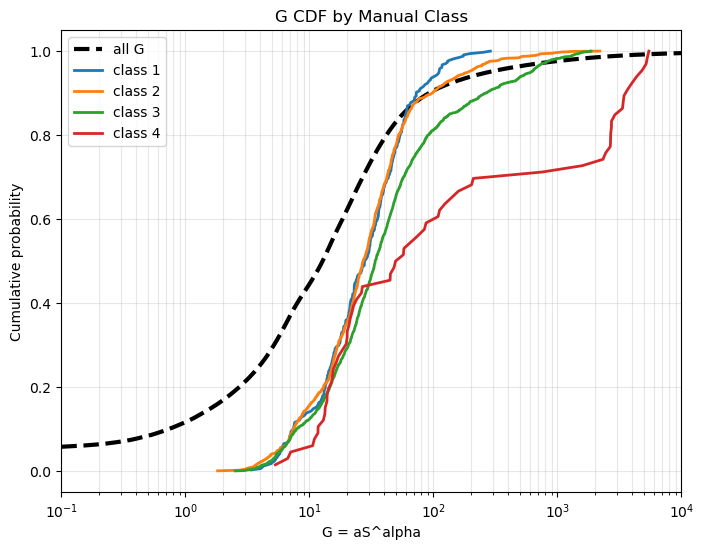

,class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,1,337,3.406621,6.042183,27.850597,37.823953,110.896991,287.901337
1,2,1368,1.817256,5.755841,27.134418,54.658538,189.778946,2204.322998
2,3,1803,2.524436,5.968795,33.940620,109.659159,612.829614,1869.972412
3,4,66,5.316273,10.709563,53.382351,1041.027475,4712.984375,5465.689941


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

G_PATH = "/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif"
CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
CLASS_FIELD = "id"

# load G
with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

# load class polygons
classes = gpd.read_file(CLASS_SHP).to_crs(raster_crs)

rows = []

plt.figure(figsize=(8, 6))

# -----------------------
# All G CDF
# -----------------------
all_values = G[np.isfinite(G) & (G > 0)]

all_sorted = np.sort(all_values)
all_cdf = np.arange(1, len(all_sorted) + 1) / len(all_sorted)

plt.plot(
    all_sorted,
    all_cdf,
    color="black",
    linewidth=3,
    linestyle="--",
    label="all G"
)

# -----------------------
# Class G CDFs
# -----------------------
for class_id in sorted(classes[CLASS_FIELD].dropna().unique()):
    
    geoms = classes[classes[CLASS_FIELD] == class_id].geometry
    
    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=transform,
        invert=True
    )
    
    values = G[mask & np.isfinite(G) & (G > 0)]
    
    if len(values) == 0:
        continue
    
    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)
    
    plt.plot(
        values_sorted,
        cdf,
        linewidth=2,
        label=f"class {class_id}"
    )
    
    rows.append({
        "class": class_id,
        "n_pixels": len(values),
        "G_min": np.min(values),
        "G_p05": np.percentile(values, 5),
        "G_median": np.median(values),
        "G_mean": np.mean(values),
        "G_p95": np.percentile(values, 95),
        "G_max": np.max(values),
    })

plt.xscale("log")
plt.xlim(1e-1, 1e4)
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("G CDF by Manual Class")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

stats = pd.DataFrame(rows)
display(stats)

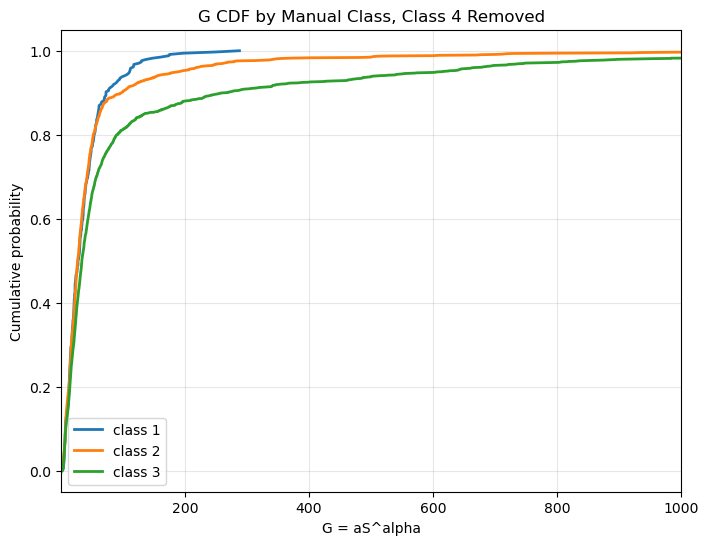

,class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,1,337,3.406621,6.042183,27.850597,37.823953,110.896991,287.901337
1,2,1368,1.817256,5.755841,27.134418,54.658538,189.778946,2204.322998
2,3,1803,2.524436,5.968795,33.940620,109.659159,612.829614,1869.972412


In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

G_PATH = "/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif"
CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
CLASS_FIELD = "id"

# load G
with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

# load class polygons
classes = gpd.read_file(CLASS_SHP).to_crs(raster_crs)

rows = []

plt.figure(figsize=(8, 6))

# -----------------------
# Class G CDFs only
# skip class 4
# -----------------------
for class_id in sorted(classes[CLASS_FIELD].dropna().unique()):

    if class_id == 4:
        continue

    geoms = classes[classes[CLASS_FIELD] == class_id].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=transform,
        invert=True
    )

    values = G[mask & np.isfinite(G) & (G > 0)]

    if len(values) == 0:
        continue

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(
        values_sorted,
        cdf,
        linewidth=2,
        label=f"class {class_id}"
    )

    rows.append({
        "class": class_id,
        "n_pixels": len(values),
        "G_min": np.min(values),
        "G_p05": np.percentile(values, 5),
        "G_median": np.median(values),
        "G_mean": np.mean(values),
        "G_p95": np.percentile(values, 95),
        "G_max": np.max(values),
    })

# plt.xscale("log")
plt.xlim(1, 1e3)
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("G CDF by Manual Class, Class 4 Removed")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

stats = pd.DataFrame(rows)
display(stats)

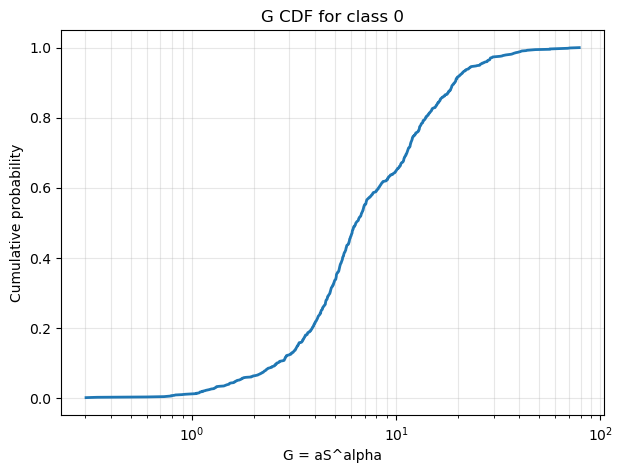

n pixels: 1052
G min/median/mean/max: 0.3023465573787689 6.3720433712005615 9.528298423204133 78.8690414428711


In [7]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

G_PATH = "/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif"
SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion1.shp"
FIELD = "id"
CLASS_ID = 0

with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

gdf = gpd.read_file(SHP).to_crs(raster_crs)
geoms = gdf[gdf[FIELD] == CLASS_ID].geometry

mask = geometry_mask(
    geoms,
    out_shape=G.shape,
    transform=transform,
    invert=True
)

values = G[mask & np.isfinite(G) & (G > 0)]

values_sorted = np.sort(values)
cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

plt.figure(figsize=(7, 5))
plt.plot(values_sorted, cdf, linewidth=2)
plt.xscale("log")
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title(f"G CDF for class {CLASS_ID}")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("n pixels:", len(values))
print("G min/median/mean/max:", np.min(values), np.median(values), np.mean(values), np.max(values))

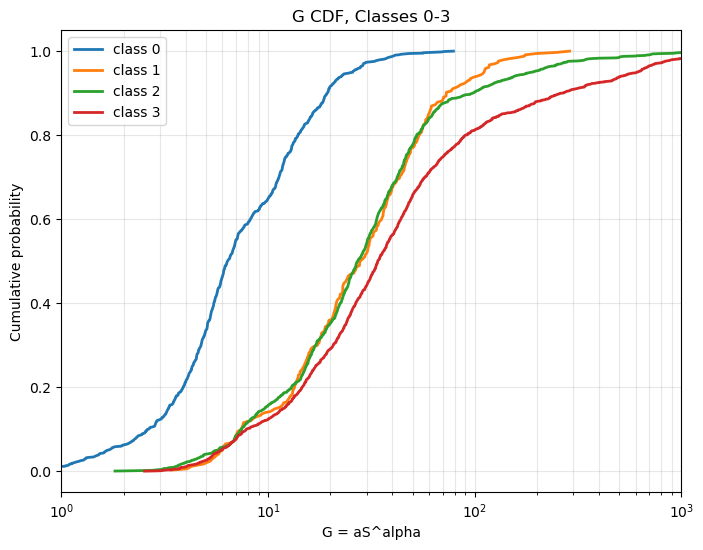

,class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,class 0,1052,0.302347,1.691356,6.372043,9.528298,25.664965,78.869041
1,class 1,337,3.406621,6.042183,27.850597,37.823953,110.896991,287.901337
2,class 2,1368,1.817256,5.755841,27.134418,54.658538,189.778946,2204.322998
3,class 3,1803,2.524436,5.968795,33.940620,109.659159,612.829614,1869.972412


In [10]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

G_PATH = "/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif"

CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
CLASS0_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion1.shp"

CLASS_FIELD = "id"

# load G
with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

rows = []

plt.figure(figsize=(8, 6))

def plot_class_cdf(shp_path, class_id, label_name):
    gdf = gpd.read_file(shp_path).to_crs(raster_crs)
    geoms = gdf[gdf[CLASS_FIELD] == class_id].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=transform,
        invert=True
    )

    values = G[mask & np.isfinite(G) & (G > 0)]

    if len(values) == 0:
        return

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2, label=label_name)

    rows.append({
        "class": label_name,
        "n_pixels": len(values),
        "G_min": np.min(values),
        "G_p05": np.percentile(values, 5),
        "G_median": np.median(values),
        "G_mean": np.mean(values),
        "G_p95": np.percentile(values, 95),
        "G_max": np.max(values),
    })

# class 0 from separate shapefile
plot_class_cdf(CLASS0_SHP, 0, "class 0")

# classes 1, 2, 3 from previous shapefile; skip class 4
for class_id in [1, 2, 3]:
    plot_class_cdf(CLASS_SHP, class_id, f"class {class_id}")

plt.xscale("log")   # remove this line if you want normal x-axis
plt.xlim(1, 1e3)
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("G CDF, Classes 0-3")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

stats = pd.DataFrame(rows)
display(stats)

,class,n_pixels,mean,median,std,min,p05,p25,p75,p95,max,percent_negative,percent_below_LOD
0,0,104691,-0.094686,0.008545,0.385210,-4.046448,-0.738342,-0.096436,0.073059,0.147949,1.845886,47.009772,6.651002
1,1,34123,-0.552069,-0.157043,0.846789,-4.481750,-2.390674,-0.943726,0.035889,0.165161,1.186401,68.622337,33.100841
2,2,137309,-0.405653,-0.116089,0.728626,-5.194275,-2.096594,-0.531311,0.028198,0.175171,3.434814,69.265671,24.470355
3,3,179954,-0.350261,-0.090454,0.701928,-4.588013,-1.951538,-0.492844,0.058655,0.247925,2.606079,64.051924,23.332074
4,4,6598,-0.752044,-0.529053,1.192384,-6.471313,-2.864880,-1.418045,-0.002808,0.639670,5.114868,75.174295,49.393756


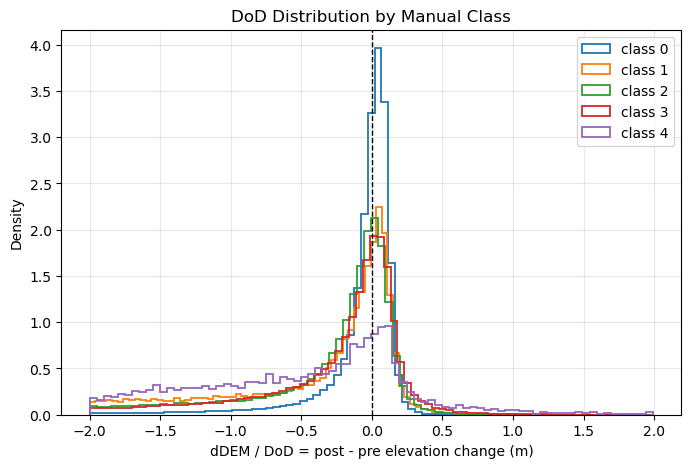

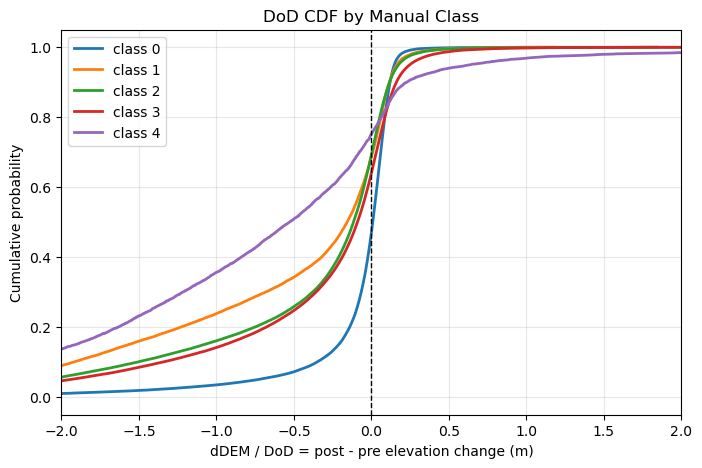

In [13]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# DOD_PATH = "/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_LoD95_filtered_change.tif"
DOD_PATH = "/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif"

CLASS0_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion1.shp"
CLASS_SHP  = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"

FIELD = "id"
# LOD = -0.55
XMIN, XMAX = -2, 2

# load dDEM / DoD
with rasterio.open(DOD_PATH) as src:
    dod = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    dod[dod == nodata] = np.nan

def get_class_values(shp, class_id):
    gdf = gpd.read_file(shp).to_crs(raster_crs)
    geoms = gdf[gdf[FIELD] == class_id].geometry

    mask = geometry_mask(
        geoms,
        out_shape=dod.shape,
        transform=transform,
        invert=True
    )

    values = dod[mask & np.isfinite(dod)]
    return values

class_sources = {
    0: CLASS0_SHP,
    1: CLASS_SHP,
    2: CLASS_SHP,
    3: CLASS_SHP,
    4: CLASS_SHP,
}

rows = []
class_values = {}

for class_id, shp in class_sources.items():
    values = get_class_values(shp, class_id)
    class_values[class_id] = values

    rows.append({
        "class": class_id,
        "n_pixels": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "std": np.std(values),
        "min": np.min(values),
        "p05": np.percentile(values, 5),
        "p25": np.percentile(values, 25),
        "p75": np.percentile(values, 75),
        "p95": np.percentile(values, 95),
        "max": np.max(values),
        "percent_negative": 100 * np.mean(values < 0),
        "percent_below_LOD": 100 * np.mean(values < LOD),
    })

stats = pd.DataFrame(rows)
display(stats)

# -----------------------
# PDF / density histogram
# -----------------------
plt.figure(figsize=(8, 5))

for class_id, values in class_values.items():
    values_plot = values[(values >= XMIN) & (values <= XMAX)]
    plt.hist(
        values_plot,
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.3,
        label=f"class {class_id}"
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
# plt.axvline(LOD, color="red", linestyle="--", linewidth=1.5, label=f"LOD = {LOD} m")
plt.xlabel("dDEM / DoD = post - pre elevation change (m)")
plt.ylabel("Density")
plt.title("DoD Distribution by Manual Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------
# CDF
# -----------------------
plt.figure(figsize=(8, 5))

for class_id, values in class_values.items():
    values = values[np.isfinite(values)]
    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2, label=f"class {class_id}")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
# plt.axvline(LOD, color="red", linestyle="--", linewidth=1.5, label=f"LOD = {LOD} m")
plt.xlim(XMIN, XMAX)
plt.xlabel("dDEM / DoD = post - pre elevation change (m)")
plt.ylabel("Cumulative probability")
plt.title("DoD CDF by Manual Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

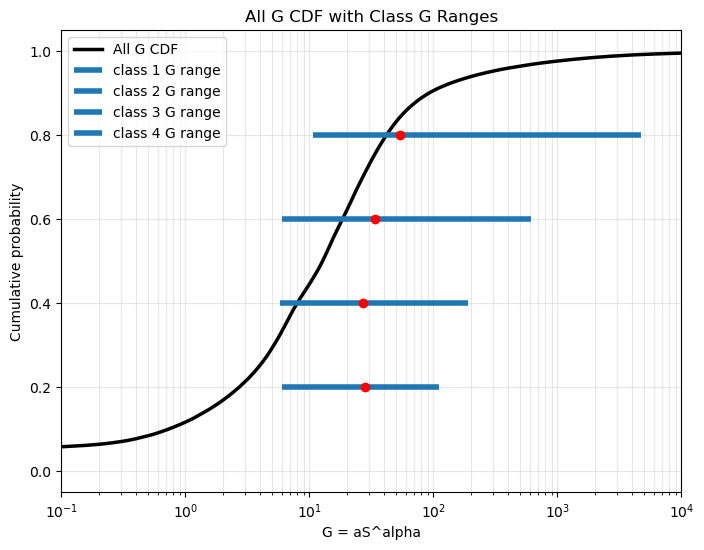

,class,n_pixels,G_p05,G_median,G_p95,G_min,G_max
0,1,337,6.042183,27.850597,110.896991,3.406621,287.901337
1,2,1368,5.755841,27.134418,189.778946,1.817256,2204.322998
2,3,1803,5.968795,33.940620,612.829614,2.524436,1869.972412
3,4,66,10.709563,53.382351,4712.984375,5.316273,5465.689941


In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

G_PATH = "/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif"
CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
CLASS_FIELD = "id"

# load G
with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

# all G CDF
all_G = G[np.isfinite(G) & (G > 0)]
all_G = np.sort(all_G)
all_cdf = np.arange(1, len(all_G) + 1) / len(all_G)

# load classes
classes = gpd.read_file(CLASS_SHP).to_crs(raster_crs)

rows = []

plt.figure(figsize=(8, 6))

# one CDF line for all G
plt.plot(all_G, all_cdf, color="black", linewidth=2.5, label="All G CDF")

# horizontal range lines for each class
for class_id in sorted(classes[CLASS_FIELD].dropna().unique()):

    geoms = classes[classes[CLASS_FIELD] == class_id].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=transform,
        invert=True
    )

    vals = G[mask & np.isfinite(G) & (G > 0)]

    if len(vals) == 0:
        continue

    g_min = np.percentile(vals, 5)
    g_max = np.percentile(vals, 95)
    g_med = np.median(vals)

    # put class lines at y = 0.2, 0.4, 0.6, 0.8 etc.
    y = class_id / 5

    plt.hlines(y, g_min, g_max, linewidth=4, label=f"class {class_id} G range")
    plt.plot(g_med, y, "o", color="red")

    rows.append({
        "class": class_id,
        "n_pixels": len(vals),
        "G_p05": g_min,
        "G_median": g_med,
        "G_p95": g_max,
        "G_min": np.min(vals),
        "G_max": np.max(vals),
    })

plt.xscale("log")
plt.xlim(0.1, 10000)
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("All G CDF with Class G Ranges")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

stats = pd.DataFrame(rows)
display(stats)

loaded polygons: 351
rill_class
0-25% bedrock/armor    91
75-100% rilled         89
0% vegetation          74
25-50% rilled          72
50-75% rilled          25
Name: count, dtype: int64


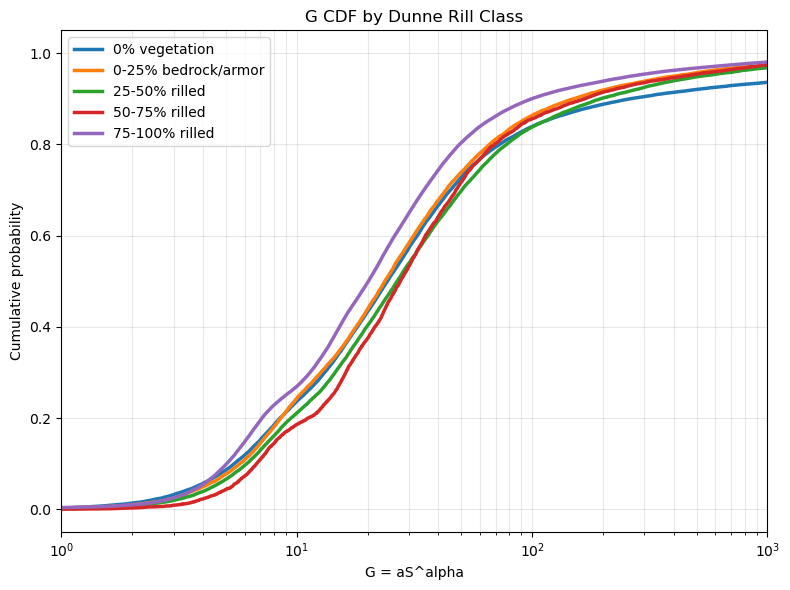

saved plot: /mnt/c/Users/amehedi/Downloads/dunne_rill_G_cdf/G_CDF_by_Dunne_rill_class.png
saved summary: /mnt/c/Users/amehedi/Downloads/dunne_rill_G_cdf/G_summary_by_Dunne_rill_class.csv


,rill_class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,0% vegetation,41552,3.559285e-16,3.740465,24.281099,891.963478,2016.587134,220091.453125
1,0-25% bedrock/armor,21292,3.559285e-16,4.025178,23.687247,324.851966,405.371986,533555.750000
2,25-50% rilled,31577,4.395694e-14,4.425731,26.709364,147.469537,529.132300,70834.656250
3,50-75% rilled,7736,8.738437e-01,5.317449,27.573349,128.506429,449.781403,10638.375000
4,75-100% rilled,79448,3.559285e-16,3.873408,20.159253,113.545868,265.023134,101819.960938


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
COMMONDATA = Path("/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata")
G_PATH = Path("/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif")

OUT = Path("/mnt/c/Users/amehedi/Downloads/dunne_rill_G_cdf")
OUT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper: classify file by name
# -----------------------------
def get_rill_class(path):
    name = path.stem.lower()

    if name.startswith("rills") or name.startswith("rilled_areas"):
        return "75-100% rilled"

    if name.startswith("50_rills") or name == "50_rills":
        return "50-75% rilled"

    if name.startswith("25_rills"):
        return "25-50% rilled"

    if name.startswith("bedrock"):
        return "0-25% bedrock/armor"

    if name.startswith("veg") or name.startswith("vegetation"):
        return "0% vegetation"

    return None

# -----------------------------
# Read all rill-class shapefiles
# -----------------------------
catchment_folders = ["csc_map", "hsc_map", "oc_map", "syc_map", "bvc_map", "rc_map"]

gdfs = []

for folder in catchment_folders:
    for shp in (COMMONDATA / folder).glob("*.shp"):

        rill_class = get_rill_class(shp)

        if rill_class is None:
            continue

        gdf = gpd.read_file(shp)
        gdf["source_file"] = shp.name
        gdf["catchment_folder"] = folder
        gdf["rill_class"] = rill_class

        gdfs.append(gdf)

rills = pd.concat(gdfs, ignore_index=True)
rills = gpd.GeoDataFrame(rills, geometry="geometry", crs=gdfs[0].crs)

print("loaded polygons:", len(rills))
print(rills["rill_class"].value_counts())

# -----------------------------
# Load G raster
# -----------------------------
with rasterio.open(G_PATH) as src:
    G = src.read(1).astype("float64")
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    G[G == nodata] = np.nan

# reproject polygons to G raster CRS
rills = rills.to_crs(raster_crs)

# -----------------------------
# Plot G CDF by rill class
# -----------------------------
class_order = [
    "0% vegetation",
    "0-25% bedrock/armor",
    "25-50% rilled",
    "50-75% rilled",
    "75-100% rilled",
]

summary_rows = []

plt.figure(figsize=(8, 6))

for rill_class in class_order:

    sub = rills[rills["rill_class"] == rill_class]

    if len(sub) == 0:
        continue

    mask = geometry_mask(
        sub.geometry,
        out_shape=G.shape,
        transform=transform,
        invert=True
    )

    values = G[mask & np.isfinite(G) & (G > 0)]

    if len(values) == 0:
        continue

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2.5, label=rill_class)

    summary_rows.append({
        "rill_class": rill_class,
        "n_pixels": len(values),
        "G_min": np.min(values),
        "G_p05": np.percentile(values, 5),
        "G_median": np.median(values),
        "G_mean": np.mean(values),
        "G_p95": np.percentile(values, 95),
        "G_max": np.max(values),
    })

plt.xscale("log")
plt.xlim(1, 1e3)
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("G CDF by Dunne Rill Class")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plot_path = OUT / "G_CDF_by_Dunne_rill_class.png"
plt.savefig(plot_path, dpi=300)
plt.show()

# -----------------------------
# Save summary
# -----------------------------
summary = pd.DataFrame(summary_rows)
csv_path = OUT / "G_summary_by_Dunne_rill_class.csv"
summary.to_csv(csv_path, index=False)

print("saved plot:", plot_path)
print("saved summary:", csv_path)

display(summary)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# -----------------------
# paths
# -----------------------
DELTAG_PATH = "/mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif"

OUR_CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
OUR_CLASS_FIELD = "id"

DUNNE_DIR = Path("/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata")

OUT = Path("/mnt/c/Users/amehedi/Downloads/deltaG_class_distributions")
OUT.mkdir(exist_ok=True)

# -----------------------
# load DeltaG
# -----------------------
with rasterio.open(DELTAG_PATH) as src:
    DeltaG = src.read(1).astype("float64")
    profile = src.profile
    transform = src.transform
    raster_crs = src.crs
    nodata = src.nodata

if nodata is not None:
    DeltaG[DeltaG == nodata] = np.nan

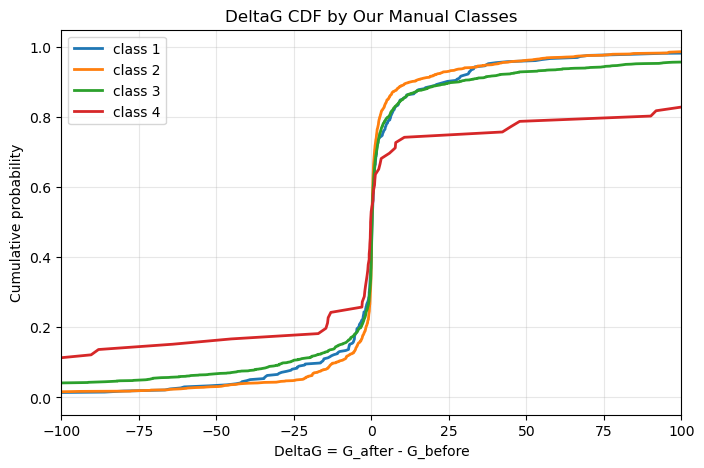

,class,DeltaG_min,DeltaG_p05,DeltaG_median,DeltaG_mean,DeltaG_p95,DeltaG_max
0,1,-180.231934,-35.552405,0.257396,1.861161,37.200639,199.254150
1,2,-697.549194,-22.826078,0.116161,1.912454,39.146148,1475.515381
2,3,-1441.879639,-72.231545,0.154886,3.113990,81.633945,1712.619507
3,4,-1143.777588,-503.906967,-0.219366,3.993062,229.500816,1651.518799


In [5]:
our = gpd.read_file(OUR_CLASS_SHP).to_crs(raster_crs)

rows = []

plt.figure(figsize=(8, 5))

for class_id in sorted(our[OUR_CLASS_FIELD].dropna().unique()):
    geoms = our[our[OUR_CLASS_FIELD] == class_id].geometry

    mask = geometry_mask(
        geoms,
        out_shape=DeltaG.shape,
        transform=transform,
        invert=True
    )

    values = DeltaG[mask & np.isfinite(DeltaG)]

    if len(values) == 0:
        continue

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2, label=f"class {class_id}")

    rows.append({
        "class": class_id,
        # "n_pixels": len(values),
        "DeltaG_min": np.min(values),
        "DeltaG_p05": np.percentile(values, 5),
        "DeltaG_median": np.median(values),
        "DeltaG_mean": np.mean(values),
        "DeltaG_p95": np.percentile(values, 95),
        "DeltaG_max": np.max(values),
    })

plt.xlabel("DeltaG = G_after - G_before")
plt.ylabel("Cumulative probability")
plt.xlim(-100, 100)
plt.title("DeltaG CDF by Our Manual Classes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

our_stats = pd.DataFrame(rows)
display(our_stats)

our_stats.to_csv(OUT / "our_manual_classes_DeltaG_stats.csv", index=False)

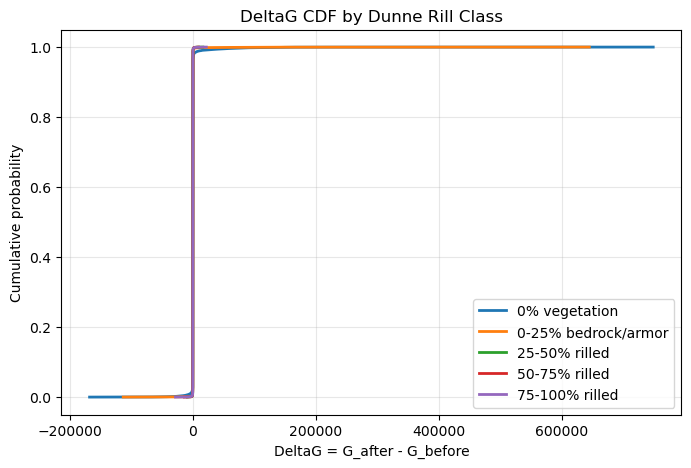

,rill_class,DeltaG_min,DeltaG_p05,DeltaG_median,DeltaG_mean,DeltaG_p95,DeltaG_max
0,0% vegetation,-167839.531250,-44.226712,0.022187,491.106256,58.874851,748556.687500
1,0-25% bedrock/armor,-113166.453125,-23.893268,0.026484,158.832516,24.647250,644619.250000
2,25-50% rilled,-8724.732422,-30.230890,0.045170,1.338096,33.020403,16304.521484
3,50-75% rilled,-13688.143555,-24.314218,0.083408,2.650902,33.623872,9153.679688
4,75-100% rilled,-28185.826172,-20.825484,0.062934,-0.794903,22.235517,21909.949219


In [7]:
# collect Dunne rill class shapefiles
dunne_classes = {
    "0% vegetation": [],
    "0-25% bedrock/armor": [],
    "25-50% rilled": [],
    "50-75% rilled": [],
    "75-100% rilled": [],
}

for shp in DUNNE_DIR.rglob("*.shp"):
    name = shp.name.lower()

    if "veg" in name:
        dunne_classes["0% vegetation"].append(shp)
    elif "bedrock" in name:
        dunne_classes["0-25% bedrock/armor"].append(shp)
    elif "25_rills" in name:
        dunne_classes["25-50% rilled"].append(shp)
    elif "50_rills" in name:
        dunne_classes["50-75% rilled"].append(shp)
    elif "rills" in name and "25_rills" not in name and "50_rills" not in name:
        dunne_classes["75-100% rilled"].append(shp)

rows = []

plt.figure(figsize=(8, 5))

for class_name, shp_list in dunne_classes.items():

    geoms_all = []

    for shp in shp_list:
        gdf = gpd.read_file(shp).to_crs(raster_crs)
        geoms_all.extend(list(gdf.geometry))

    if len(geoms_all) == 0:
        continue

    mask = geometry_mask(
        geoms_all,
        out_shape=DeltaG.shape,
        transform=transform,
        invert=True
    )

    values = DeltaG[mask & np.isfinite(DeltaG)]

    if len(values) == 0:
        continue

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2, label=class_name)

    rows.append({
        "rill_class": class_name,
        # "n_pixels": len(values),
        "DeltaG_min": np.min(values),
        "DeltaG_p05": np.percentile(values, 5),
        "DeltaG_median": np.median(values),
        "DeltaG_mean": np.mean(values),
        "DeltaG_p95": np.percentile(values, 95),
        "DeltaG_max": np.max(values),
    })

plt.xlabel("DeltaG = G_after - G_before")
plt.ylabel("Cumulative probability")
# plt.xlim(-100, 100)
plt.title("DeltaG CDF by Dunne Rill Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

dunne_stats = pd.DataFrame(rows)
display(dunne_stats)

dunne_stats.to_csv(OUT / "dunne_rill_classes_DeltaG_stats.csv", index=False)

In [8]:
from pathlib import Path
import numpy as np
import rasterio

DDEM_PATH = Path("/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif")
SIGMA_PATH = Path("/mnt/c/Users/amehedi/Downloads/final_uncertainty_sigma_dh (1).tif")
OUT_DIR = Path("/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM")
OUT_DIR.mkdir(exist_ok=True)

LOD_MULT = 1.96

with rasterio.open(DDEM_PATH) as src:
    ddem = src.read(1).astype("float32")
    profile = src.profile.copy()
    ddem_nodata = src.nodata

with rasterio.open(SIGMA_PATH) as src:
    sigma = src.read(1).astype("float32")
    sigma_nodata = src.nodata

valid = np.isfinite(ddem) & np.isfinite(sigma) & (sigma >= 0)

if ddem_nodata is not None:
    valid &= ddem != ddem_nodata
if sigma_nodata is not None:
    valid &= sigma != sigma_nodata

lod95 = 1.96 * sigma

sig_erosion = valid & (ddem < -lod95)
sig_deposition = valid & (ddem > lod95)
sig_any = sig_erosion | sig_deposition

# filtered dDEM: significant change kept, nonsignificant = 0
filtered = np.full(ddem.shape, -9999, dtype="float32")
filtered[valid] = 0
filtered[sig_any] = ddem[sig_any]

profile.update(dtype="float32", nodata=-9999, compress="lzw")

with rasterio.open(OUT_DIR / "dDEM_LoD95_filtered_change.tif", "w", **profile) as dst:
    dst.write(filtered, 1)

# class raster: 0 none, 1 erosion, 2 deposition
classes = np.full(ddem.shape, 255, dtype="uint8")
classes[valid] = 0
classes[sig_erosion] = 1
classes[sig_deposition] = 2

class_profile = profile.copy()
class_profile.update(dtype="uint8", nodata=255)

with rasterio.open(
    OUT_DIR / "dDEM_LoD95_classes_0none_1erosion_2deposition.tif",
    "w",
    **class_profile
) as dst:
    dst.write(classes, 1)

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# -----------------------
# Paths
# -----------------------

# 10 m dDEM, bias-corrected
DOD_BIAS_PATH = "/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/xdem_stable_filter_comparison10/full_overlap/no_stable_mask_elev_gt_2m/best_corrected_products/final_DoD_post_minus_pre.tif"

# 10 m uncertainty raster, if available
SIGMA_PATH = None  # update if Lauren provides 10 m final_uncertainty_sigma_dh.tif

# 1 m examples, keep for later
# DOD_BIAS_PATH = "/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif"
# SIGMA_PATH = "/mnt/c/Users/amehedi/Downloads/final_uncertainty_sigma_dh (1).tif"

CLASS_SHP = "/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp"
CLASS_FIELD = "id"

DELTAG_PATH = "/mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif"

DUNNE_DIR = Path("/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata")

LOD_CONST = -0.55

In [18]:
# -----------------------
# Load dDEM and classes
# -----------------------

dod_bias, profile, transform, crs = read_raster(DOD_BIAS_PATH)
classes = gpd.read_file(CLASS_SHP).to_crs(crs)

# If no sigma raster, make a simple fixed-LoD filtered version.
# Non-significant values become 0.
if SIGMA_PATH is None:
    dod_lod = dod_bias.copy()
    dod_lod[(dod_lod > LOD_CONST) & (dod_lod < abs(LOD_CONST))] = 0
else:
    sigma, _, _, _ = read_raster(SIGMA_PATH)
    lod95 = 1.96 * sigma
    dod_lod = np.full(dod_bias.shape, np.nan)
    valid = np.isfinite(dod_bias) & np.isfinite(lod95)
    dod_lod[valid] = 0
    dod_lod[valid & (np.abs(dod_bias) > lod95)] = dod_bias[valid & (np.abs(dod_bias) > lod95)]

dod_bias_by_class = get_values_by_polygons(dod_bias, transform, classes, crs, CLASS_FIELD)
dod_lod_by_class = get_values_by_polygons(dod_lod, transform, classes, crs, CLASS_FIELD)

NameError: name 'read_raster' is not defined

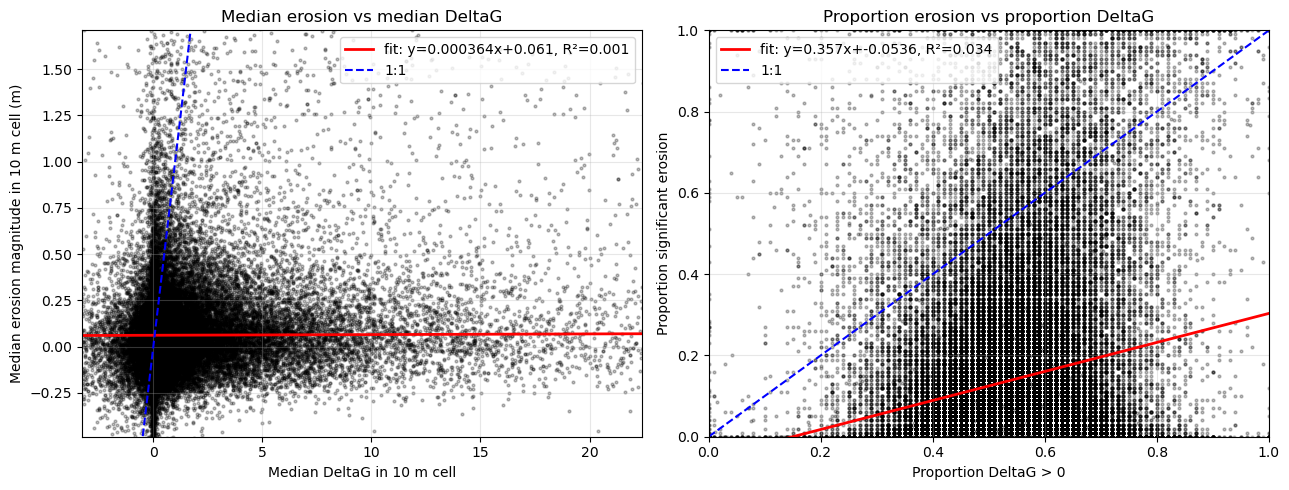

In [9]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def read(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

def crop_same(a, b):
    rows = min(a.shape[0], b.shape[0])
    cols = min(a.shape[1], b.shape[1])
    return a[:rows, :cols], b[:rows, :cols]

def fit_line(x, y):
    m, b = np.polyfit(x, y, 1)
    yhat = m * x + b
    r2 = 1 - np.sum((y - yhat) ** 2) / np.sum((y - np.mean(y)) ** 2)
    return m, b, r2

def sample_xy(x, y, n=80000):
    if len(x) <= n:
        return x, y
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x), n, replace=False)
    return x[idx], y[idx]

# files
median_dod = read("/mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/median_DoD_10m.tif")
frac_erosion = read("/mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/frac_sig_erosion_10m.tif")

median_dg = read("/mnt/c/Users/amehedi/Downloads/DeltaG_10m_blocks_from_1m/DeltaG_median_10m_from_1m.tif")
frac_dg = read("/mnt/c/Users/amehedi/Downloads/DeltaG_10m_blocks_from_1m/DeltaG_fraction_positive_10m_from_1m.tif")

# make same shape
median_dod, median_dg = crop_same(median_dod, median_dg)
frac_erosion, frac_dg = crop_same(frac_erosion, frac_dg)

# erosion magnitude: positive means erosion, negative means deposition
median_erosion = -median_dod

# valid pixels
v1 = np.isfinite(median_erosion) & np.isfinite(median_dg)
v2 = np.isfinite(frac_erosion) & np.isfinite(frac_dg)

x1 = median_dg[v1]
y1 = median_erosion[v1]

x2 = frac_dg[v2]
y2 = frac_erosion[v2]

m1, b1, r2_1 = fit_line(x1, y1)
m2, b2, r2_2 = fit_line(x2, y2)

x1s, y1s = sample_xy(x1, y1)
x2s, y2s = sample_xy(x2, y2)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# plot 1
ax[0].scatter(x1s, y1s, s=4, alpha=0.25, color="black")
xx = np.linspace(np.nanpercentile(x1, 1), np.nanpercentile(x1, 99), 200)
ax[0].plot(xx, m1 * xx + b1, color="red", linewidth=2, label=f"fit: y={m1:.3g}x+{b1:.3g}, R²={r2_1:.3f}")
ax[0].plot(xx, xx, color="blue", linestyle="--", linewidth=1.5, label="1:1")
ax[0].set_xlim(np.nanpercentile(x1, 1), np.nanpercentile(x1, 99))
ax[0].set_ylim(np.nanpercentile(y1, 1), np.nanpercentile(y1, 99))
ax[0].set_xlabel("Median DeltaG in 10 m cell")
ax[0].set_ylabel("Median erosion magnitude in 10 m cell (m)")
ax[0].set_title("Median erosion vs median DeltaG")
ax[0].legend()
ax[0].grid(alpha=0.3)

# plot 2
ax[1].scatter(x2s, y2s, s=4, alpha=0.25, color="black")
xx = np.linspace(0, 1, 200)
ax[1].plot(xx, m2 * xx + b2, color="red", linewidth=2, label=f"fit: y={m2:.3g}x+{b2:.3g}, R²={r2_2:.3f}")
ax[1].plot([0, 1], [0, 1], color="blue", linestyle="--", linewidth=1.5, label="1:1")
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[1].set_xlabel("Proportion DeltaG > 0")
ax[1].set_ylabel("Proportion significant erosion")
ax[1].set_title("Proportion erosion vs proportion DeltaG")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

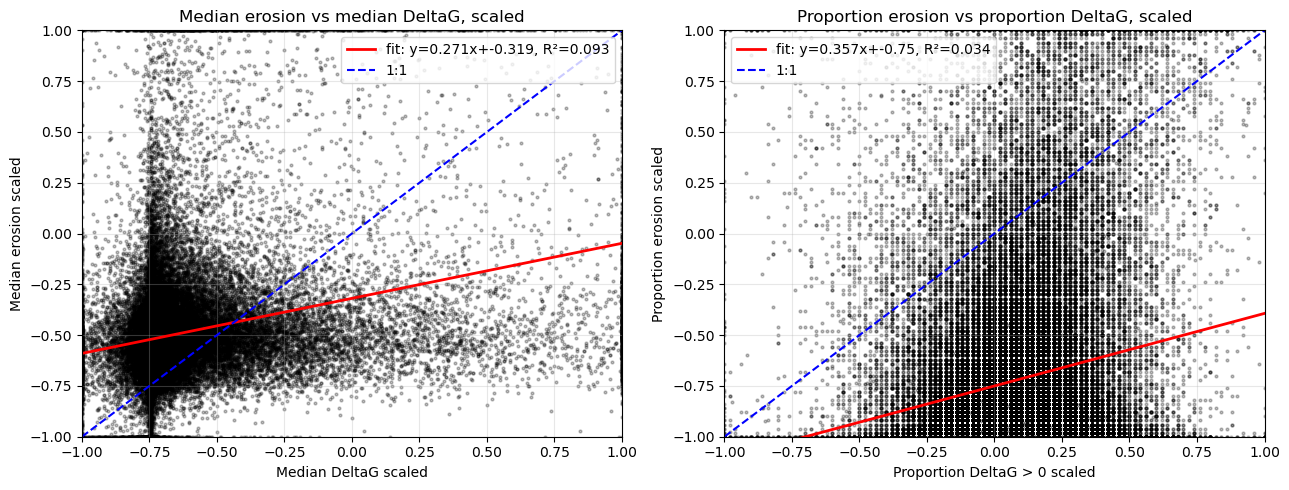

In [10]:
def scale_minus1_to_1(a, p_low=1, p_high=99):
    lo = np.nanpercentile(a, p_low)
    hi = np.nanpercentile(a, p_high)
    scaled = 2 * (a - lo) / (hi - lo) - 1
    return np.clip(scaled, -1, 1)

# robust -1 to 1 scaling for median variables
x1_scaled = scale_minus1_to_1(x1)
y1_scaled = scale_minus1_to_1(y1)

# direct 0-1 to -1 to 1 scaling for proportions
x2_scaled = 2 * x2 - 1
y2_scaled = 2 * y2 - 1

m1s, b1s, r2_1s = fit_line(x1_scaled, y1_scaled)
m2s, b2s, r2_2s = fit_line(x2_scaled, y2_scaled)

x1p, y1p = sample_xy(x1_scaled, y1_scaled)
x2p, y2p = sample_xy(x2_scaled, y2_scaled)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

xx = np.linspace(-1, 1, 200)

ax[0].scatter(x1p, y1p, s=4, alpha=0.25, color="black")
ax[0].plot(xx, m1s * xx + b1s, color="red", linewidth=2, label=f"fit: y={m1s:.3g}x+{b1s:.3g}, R²={r2_1s:.3f}")
ax[0].plot(xx, xx, color="blue", linestyle="--", linewidth=1.5, label="1:1")
ax[0].set_xlim(-1, 1)
ax[0].set_ylim(-1, 1)
ax[0].set_xlabel("Median DeltaG scaled")
ax[0].set_ylabel("Median erosion scaled")
ax[0].set_title("Median erosion vs median DeltaG, scaled")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].scatter(x2p, y2p, s=4, alpha=0.25, color="black")
ax[1].plot(xx, m2s * xx + b2s, color="red", linewidth=2, label=f"fit: y={m2s:.3g}x+{b2s:.3g}, R²={r2_2s:.3f}")
ax[1].plot(xx, xx, color="blue", linestyle="--", linewidth=1.5, label="1:1")
ax[1].set_xlim(-1, 1)
ax[1].set_ylim(-1, 1)
ax[1].set_xlabel("Proportion DeltaG > 0 scaled")
ax[1].set_ylabel("Proportion erosion scaled")
ax[1].set_title("Proportion erosion vs proportion DeltaG, scaled")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

,variable,n_valid,min,p01,p05,median,mean,std,p95,p99,max,iqr_low_cut,iqr_high_cut,outlier_count,outlier_percent
0,median_erosion,615325,-31.549377,-0.487411,-0.180420,0.008789,0.061504,0.652223,0.457391,1.709275,27.605225,-0.217844,0.276507,76838,12.487385
1,median_DeltaG,615325,-408.033142,-3.274816,-0.543643,0.027386,1.358321,42.778124,7.605510,22.414481,30518.492188,-1.102672,1.814073,114655,18.633243
2,proportion_erosion,615325,0.000000,0.000000,0.000000,0.040000,0.138034,0.212338,0.640000,0.960000,1.000000,-0.270000,0.450000,57409,9.329866
3,proportion_DeltaG_positive,615325,0.000000,0.250000,0.370000,0.530000,0.536717,0.109570,0.720000,0.830000,1.000000,0.275000,0.795000,18510,3.008166


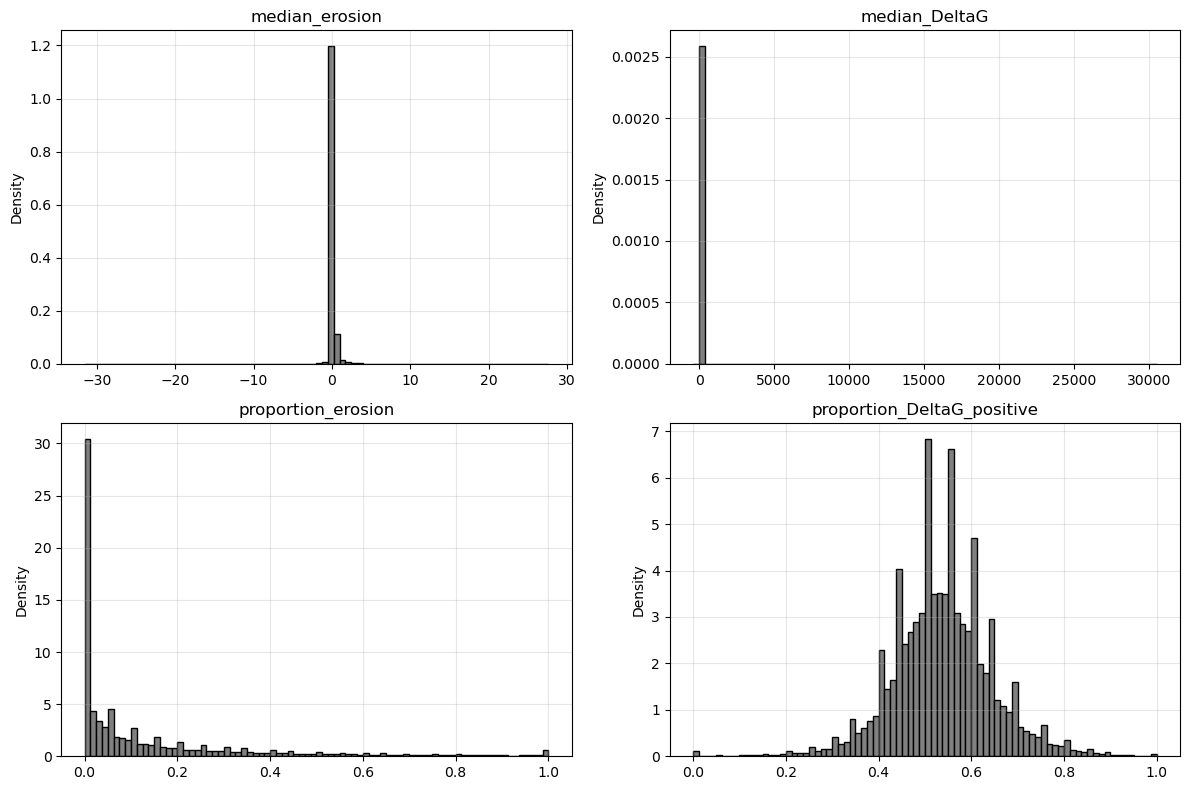

In [11]:
import pandas as pd

def describe_with_outliers(name, arr):
    values = arr[np.isfinite(arr)].ravel()

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    low_cut = q1 - 1.5 * iqr
    high_cut = q3 + 1.5 * iqr

    outliers = (values < low_cut) | (values > high_cut)

    return {
        "variable": name,
        "n_valid": len(values),
        "min": np.min(values),
        "p01": np.percentile(values, 1),
        "p05": np.percentile(values, 5),
        "median": np.median(values),
        "mean": np.mean(values),
        "std": np.std(values),
        "p95": np.percentile(values, 95),
        "p99": np.percentile(values, 99),
        "max": np.max(values),
        "iqr_low_cut": low_cut,
        "iqr_high_cut": high_cut,
        "outlier_count": np.sum(outliers),
        "outlier_percent": 100 * np.sum(outliers) / len(values),
    }

stats = pd.DataFrame([
    describe_with_outliers("median_erosion", median_erosion),
    describe_with_outliers("median_DeltaG", median_dg),
    describe_with_outliers("proportion_erosion", frac_erosion),
    describe_with_outliers("proportion_DeltaG_positive", frac_dg),
])

display(stats)

# quick histograms
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

items = [
    ("median_erosion", median_erosion),
    ("median_DeltaG", median_dg),
    ("proportion_erosion", frac_erosion),
    ("proportion_DeltaG_positive", frac_dg),
]

for a, (name, arr) in zip(ax.ravel(), items):
    values = arr[np.isfinite(arr)]
    a.hist(values, bins=80, density=True, color="gray", edgecolor="black")
    a.set_title(name)
    a.set_ylabel("Density")
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def read(path):
    with rasterio.open(path) as src:
        a = src.read(1).astype("float64")
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
    return a

def plot_cdf(values, label):
    v = values[np.isfinite(values)]
    v = v[(v > -500) & (v < 500)]   # simple outlier clip for display
    v = np.sort(v)
    cdf = np.arange(1, len(v) + 1) / len(v)
    plt.plot(v, cdf, label=label, linewidth=2)

# paths
DELTA_G_1M = "/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif"
DELTA_G_10M = "/mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif"

# read
dg_1m = read(DELTA_G_1M)
dg_10m = read(DELTA_G_10M)

# plot
plt.figure(figsize=(7, 5))
plot_cdf(dg_1m, "DeltaG 1 m")
plot_cdf(dg_10m, "DeltaG 10 m")
plt.axvline(0, color="black", linestyle="--", label="DeltaG = 0")
plt.xlabel("DeltaG = G_after - G_before")
plt.ylabel("Cumulative probability")
plt.title("DeltaG CDF: 1 m vs 10 m")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [1]:
from pathlib import Path
import numpy as np
import rasterio
import whitebox

# -----------------------
# Paths
# -----------------------
PRE_DEM  = Path("/mnt/c/Users/amehedi/Downloads/final_pre_reference.tif")
POST_DEM = Path("/mnt/c/Users/amehedi/Downloads/final_post_corrected.tif")

OUT = Path("/mnt/c/Users/amehedi/Downloads/G_1m_dinf_delta")
OUT.mkdir(exist_ok=True)

ALPHA = 1.167

wbt = whitebox.WhiteboxTools()
wbt.verbose = False

# -----------------------
# Helpers
# -----------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        profile = src.profile
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile

def write_raster(path, arr, profile):
    profile = profile.copy()
    profile.update(dtype="float32", nodata=-9999.0, compress="lzw")
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(out, 1)

def make_G_dinf(dem_path, tag):
    filled = OUT / f"{tag}_filled.tif"
    slope_pct = OUT / f"S_{tag}_percent.tif"
    sca = OUT / f"a_{tag}_dinf_sca.tif"
    G_path = OUT / f"G_{tag}_dinf.tif"

    # fill sinks
    wbt.fill_depressions_wang_and_liu(str(dem_path), str(filled), fix_flats=True)

    # slope in percent, then convert to m/m
    wbt.slope(str(filled), str(slope_pct), units="percent")

    # D-infinity specific contributing area
    wbt.d_inf_flow_accumulation(str(filled), str(sca), out_type="sca")

    S_pct, profile = read_raster(slope_pct)
    a, _ = read_raster(sca)

    S = S_pct / 100.0
    G = a * (S ** ALPHA)

    G[~np.isfinite(G)] = np.nan
    G[G < 0] = np.nan

    write_raster(G_path, G, profile)

    print("saved:", G_path)
    print(tag, "G min/mean/max:", np.nanmin(G), np.nanmean(G), np.nanmax(G))

    return G, profile

# -----------------------
# Compute G before/after
# -----------------------
G_pre, profile = make_G_dinf(PRE_DEM, "pre")
G_post, _ = make_G_dinf(POST_DEM, "post")

# -----------------------
# DeltaG
# -----------------------
DeltaG = G_post - G_pre
write_raster(OUT / "DeltaG_1m_dinf.tif", DeltaG, profile)

print("saved:", OUT / "DeltaG_1m_dinf.tif")
print("DeltaG min/mean/max:", np.nanmin(DeltaG), np.nanmean(DeltaG), np.nanmax(DeltaG))

saved: /mnt/c/Users/amehedi/Downloads/G_1m_dinf_delta/G_pre_dinf.tif
pre G min/mean/max: 0.0 33019277416.5879 9.27026367411149e+16
saved: /mnt/c/Users/amehedi/Downloads/G_1m_dinf_delta/G_post_dinf.tif
post G min/mean/max: 0.0 86231180667.53429 8.92811496903324e+16
saved: /mnt/c/Users/amehedi/Downloads/G_1m_dinf_delta/DeltaG_1m_dinf.tif
DeltaG min/mean/max: -9.270263504978539e+16 53116099270.177 8.92811496903324e+16


In [2]:
path = "/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif"

with rasterio.open(path) as src:
    dg = src.read(1).astype("float64")
    if src.nodata is not None:
        dg[dg == src.nodata] = np.nan

values = dg[np.isfinite(dg)]

p5 = np.percentile(values, 5)

print("DeltaG 5th percentile:", p5)

DeltaG 5th percentile: -44.68207054138183


In [7]:
thr = np.nanpercentile(np.abs(DeltaG[np.isfinite(DeltaG) & (DeltaG != 0)]), 5)
print(thr)

0.012190654184459119


In [8]:
DeltaG_clean = DeltaG.copy()
DeltaG_clean[np.abs(DeltaG_clean) < thr] = 0

In [9]:
from pathlib import Path
import numpy as np
import rasterio

out_path = Path("/mnt/c/Users/amehedi/Downloads/DeltaG_small_values_binary.tif")

small_dg = np.full(DeltaG.shape, 255, dtype="uint8")  # 255 = nodata
valid = np.isfinite(DeltaG)

small_dg[valid] = 0
small_dg[valid & (np.abs(DeltaG) < thr)] = 1

meta = profile.copy()
meta.update(dtype="uint8", nodata=255, compress="lzw")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(small_dg, 1)

print("saved:", out_path)
print("threshold used:", thr)

saved: /mnt/c/Users/amehedi/Downloads/DeltaG_small_values_binary.tif
threshold used: 0.012190654184459119


/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


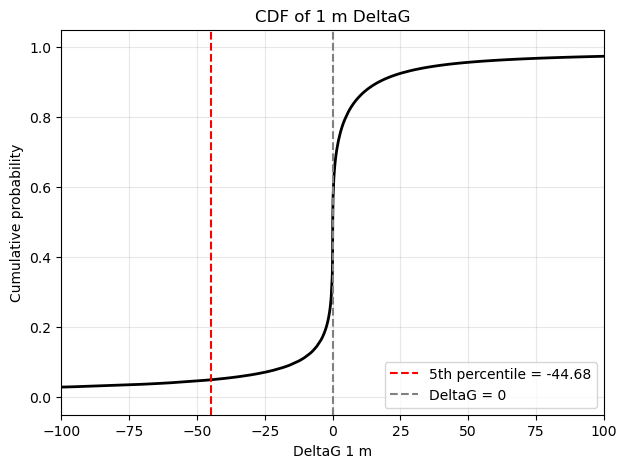

In [6]:
values_sorted = np.sort(values)
cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

plt.figure(figsize=(7, 5))
plt.plot(values_sorted, cdf, color="black", linewidth=2)
plt.axvline(p5, color="red", linestyle="--", label=f"5th percentile = {p5:.2f}")
plt.axvline(0, color="gray", linestyle="--", label="DeltaG = 0")
plt.xlim(-100, 100)
plt.xlabel("DeltaG 1 m")
plt.ylabel("Cumulative probability")
plt.title("CDF of 1 m DeltaG")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================
import numpy as np
import rasterio
from rasterio.transform import Affine
from pathlib import Path
import pandas as pd
from scipy.ndimage import label as scipy_label

print("Imports OK")

# ================================================================
# CELL 2 — PATHS & FIXED SETTINGS (edit once)
# ================================================================
G_PRE_PATH   = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif"
DELTA_G_PATH = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif"
DDEM_PATH    = r"/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_LoD95_filtered_change.tif"
OUT_DIR      = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels")
OUT_DIR.mkdir(exist_ok=True)

BLOCK_SIZE   = 10   # fixed: 1m → 10m

# ================================================================
# CELL 3 — LOAD RASTERS ONCE (expensive — only run once)
# ================================================================
def _load(path, nodata=None):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = nodata if nodata is not None else src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        return arr, src.profile

g_pre,   PROF   = _load(G_PRE_PATH)
delta_g, _      = _load(DELTA_G_PATH)
ddem,    _      = _load(DDEM_PATH, nodata=-9999.0)

print(f"G_pre   {g_pre.shape}   [{np.nanmin(g_pre):.1f}, {np.nanmax(g_pre):.1f}]")
print(f"DeltaG  {delta_g.shape} [{np.nanmin(delta_g):.1f}, {np.nanmax(delta_g):.1f}]")
print(f"dDEM    {ddem.shape}    [{np.nanmin(ddem):.2f}, {np.nanmax(ddem):.2f}]")

# ================================================================
# CELL 4 — HELPER FUNCTIONS
# ================================================================
def make_tag(cfg: dict) -> str:
    """Short param string embedded in every output filename."""
    bt = int(cfg["BINARY_THRESH"] * 100)
    return (
        f"g{cfg['G_MIN']}"
        f"_dg{int(cfg['DELTA_G_LOD'])}"
        f"_gc{cfg['G_CHANNEL']}"
        f"_s{cfg['SCORE_HIGH_THRESH']}"
        f"_bt{bt}"
    )


def _block_reduce(arr, pad_h, pad_w, block):
    """Pad and reshape 1m array for block-wise aggregation."""
    padded = np.pad(
        arr.astype("float32"),
        ((0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=np.nan,
    )
    H2, W2 = padded.shape
    return padded.reshape(H2 // block, block, W2 // block, block)


def _write(path, arr, dtype, nodata, transform, crs):
    H, W = arr.shape
    with rasterio.open(
        path, "w", driver="GTiff",
        height=H, width=W, count=1,
        dtype=dtype, crs=crs,
        transform=transform,
        nodata=nodata, compress="lzw",
    ) as dst:
        dst.write(arr.astype(dtype), 1)


def run_pipeline(cfg: dict) -> dict:
    """
    Run one sensitivity configuration end-to-end.
    Returns a stats dict for the summary CSV.
    """
    G_MIN             = cfg["G_MIN"]
    G_CHANNEL         = cfg["G_CHANNEL"]
    DELTA_G_LOD       = cfg["DELTA_G_LOD"]
    SCORE_HIGH_THRESH = cfg["SCORE_HIGH_THRESH"]
    BINARY_THRESH     = cfg["BINARY_THRESH"]
    tag               = make_tag(cfg)

    # ── STEP 1: score each 1m pixel (0–3, aerial slot reserved) ──
    c1 = (g_pre   >= G_MIN) & (g_pre < G_CHANNEL)
    c2 =  delta_g >  DELTA_G_LOD
    c3 =  ddem    <  0.0

    score = c1.astype("uint8") + c2.astype("uint8") + c3.astype("uint8")

    # ── STEP 2: mask channels ──
    score[g_pre >= G_CHANNEL] = 0

    # mask below G_MIN
    score[g_pre < G_MIN] = 0

    # ── STEP 3: optional morphological cleaning ──
    # (comment/uncomment independently of everything else)
    MIN_PATCH_SIZE = cfg.get("MIN_PATCH_SIZE", 5)
    # labeled, _ = scipy_label(score >= SCORE_HIGH_THRESH)
    # sizes = np.bincount(labeled.ravel())
    # small = np.isin(labeled, np.where(sizes < MIN_PATCH_SIZE)[0])
    # score[small & (score >= SCORE_HIGH_THRESH)] = 0

    # ── STEP 4: aggregate 1m → 10m ──
    H, W   = score.shape
    pad_h  = (BLOCK_SIZE - H % BLOCK_SIZE) % BLOCK_SIZE
    pad_w  = (BLOCK_SIZE - W % BLOCK_SIZE) % BLOCK_SIZE

    s = _block_reduce(score, pad_h, pad_w, BLOCK_SIZE)

    with np.errstate(all="ignore"):
        frac_hi   = np.nanmean(s >= SCORE_HIGH_THRESH,     axis=(1, 3))
        frac_med  = np.nanmean(s >= max(1, SCORE_HIGH_THRESH - 1), axis=(1, 3))
        mean_score = np.nanmean(s,                          axis=(1, 3))

    binary_10m = (frac_hi >= BINARY_THRESH).astype("uint8")

    # ── STEP 5: write outputs ──
    t0 = PROF["transform"]
    t10 = Affine(t0.a * BLOCK_SIZE, t0.b, t0.c,
                 t0.d, t0.e * BLOCK_SIZE, t0.f)
    crs = PROF["crs"]

    _write(OUT_DIR / f"src_conf_1m_{tag}.tif",
           score,        "uint8",   255,    t0,  crs)
    _write(OUT_DIR / f"src_hi_{tag}.tif",
           frac_hi,      "float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_med_{tag}.tif",
           frac_med,     "float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_score_{tag}.tif",
           mean_score,   "float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_bin_{tag}.tif",
           binary_10m,   "uint8",   255,    t10, crs)

    # ── stats for summary ──
    n_total_1m  = score.size
    n_pos_1m    = int((score >= SCORE_HIGH_THRESH).sum())
    n_total_10m = binary_10m.size
    n_pos_10m   = int(binary_10m.sum())

    stats = {
        "tag"               : tag,
        "G_MIN"             : G_MIN,
        "DELTA_G_LOD"       : DELTA_G_LOD,
        "G_CHANNEL"         : G_CHANNEL,
        "SCORE_HIGH_THRESH" : SCORE_HIGH_THRESH,
        "BINARY_THRESH"     : BINARY_THRESH,
        "n_pos_1m"          : n_pos_1m,
        "pct_pos_1m"        : round(100 * n_pos_1m  / n_total_1m,  3),
        "n_pos_10m"         : n_pos_10m,
        "pct_pos_10m"       : round(100 * n_pos_10m / n_total_10m, 3),
    }
    print(f"[{tag}]  1m pos: {n_pos_1m:>8,} ({stats['pct_pos_1m']:.2f}%)  "
          f"| 10m pos: {n_pos_10m:>6,} ({stats['pct_pos_10m']:.2f}%)")
    return stats


def write_summary(results: list[dict], path: Path) -> None:
    df = pd.DataFrame(results)
    df.to_csv(path, index=False)
    print(f"\nSummary → {path}")
    print(df.to_string(index=False))

# ================================================================
# CELL 5 — SENSITIVITY RUNS (edit this cell to add/remove runs)
# ================================================================
runs = [
    # vary G_MIN (most sensitive)
    dict(G_MIN=5,  DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=3, BINARY_THRESH=0.05),
    dict(G_MIN=10, DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=3, BINARY_THRESH=0.05),
    dict(G_MIN=20, DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=3, BINARY_THRESH=0.05),

    # # vary BINARY_THRESH at 10m
    # dict(G_MIN=10, DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=3, BINARY_THRESH=0.10),
    # dict(G_MIN=10, DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=3, BINARY_THRESH=0.20),

    # relax SCORE_HIGH_THRESH (medium confidence as positive)
    dict(G_MIN=10, DELTA_G_LOD=1,  G_CHANNEL=120, SCORE_HIGH_THRESH=2, BINARY_THRESH=0.05),
]

Imports OK
G_pre   (10986, 7425)   [0.0, 23199890.0]
DeltaG  (10986, 7425) [-23199888.0, 13161083.0]
dDEM    (10986, 7425)    [-28.45, 32.22]


In [21]:
# ================================================================
# CELL 6 — RUN ALL & WRITE SUMMARY (run this cell)
# ================================================================
results = [run_pipeline(cfg) for cfg in runs]
write_summary(results, OUT_DIR / "sensitivity_summary.csv")

[g5_dg1_gc120_s3_bt5]  1m pos:  649,365 (0.80%)  | 10m pos: 43,552 (5.33%)
[g10_dg1_gc120_s3_bt5]  1m pos:  323,350 (0.40%)  | 10m pos: 20,385 (2.50%)
[g20_dg1_gc120_s3_bt5]  1m pos:  139,606 (0.17%)  | 10m pos:  6,840 (0.84%)
[g10_dg1_gc120_s2_bt5]  1m pos: 3,362,699 (4.12%)  | 10m pos: 215,988 (26.45%)

Summary → /mnt/c/Users/amehedi/Downloads/source_zone_labels/sensitivity_summary.csv
                 tag  G_MIN  DELTA_G_LOD  G_CHANNEL  SCORE_HIGH_THRESH  BINARY_THRESH  n_pos_1m  pct_pos_1m  n_pos_10m  pct_pos_10m
 g5_dg1_gc120_s3_bt5      5            1        120                  3           0.05    649365       0.796      43552        5.334
g10_dg1_gc120_s3_bt5     10            1        120                  3           0.05    323350       0.396      20385        2.496
g20_dg1_gc120_s3_bt5     20            1        120                  3           0.05    139606       0.171       6840        0.838
g10_dg1_gc120_s2_bt5     10            1        120                  2           

In [ ]:
# ================================================================
# C2 + C3 SCORING  —  no terrain prior (no C1)
#
# Requires g_pre, delta_g, ddem already loaded from the cell above.
# Outputs four 10m rasters to source_zone_labels/:
#   frac_c2c3  — fraction of 1m pixels where BOTH signals fired  <- primary label
#   frac_c2    — fraction where delta_g > LOD (rill network)
#   frac_c3    — fraction where dDEM < 0  (any erosion)
#   mean_score — mean(c2 + c3) per block, 0-2 continuous
# ================================================================
import numpy as np
import rasterio
from rasterio.transform import Affine
from pathlib import Path

OUT_DIR     = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels")
BLOCK       = 10      # 1m -> 10m
G_CHANNEL   = 120     # still mask main channels
DELTA_G_LOD = 1.0     # delta_g detection threshold

# -- 1. Binary evidence maps at 1m --
c2 = (delta_g > DELTA_G_LOD).astype("float32")   # flow network reorganized
c3 = (ddem    < 0.0        ).astype("float32")   # surface lowered

# Mask main channels from both maps
channel_mask = g_pre >= G_CHANNEL
c2[channel_mask] = np.nan
c3[channel_mask] = np.nan

# -- 2. Pad to be divisible by BLOCK --
H, W  = c2.shape
pad_h = (BLOCK - H % BLOCK) % BLOCK
pad_w = (BLOCK - W % BLOCK) % BLOCK
def _pad(arr):
    return np.pad(arr, ((0, pad_h), (0, pad_w)),
                  mode="constant", constant_values=np.nan)

c2p = _pad(c2)
c3p = _pad(c3)

# -- 3. Reshape into 10x10 blocks --
H2, W2 = c2p.shape
c2b = c2p.reshape(H2 // BLOCK, BLOCK, W2 // BLOCK, BLOCK)
c3b = c3p.reshape(H2 // BLOCK, BLOCK, W2 // BLOCK, BLOCK)

# -- 4. Aggregate --
with np.errstate(all="ignore"):
    frac_c2c3  = np.nanmean((c2b == 1) & (c3b == 1), axis=(1, 3)).astype("float32")
    frac_c2    = np.nanmean(c2b,                      axis=(1, 3)).astype("float32")
    frac_c3    = np.nanmean(c3b,                      axis=(1, 3)).astype("float32")
    mean_score = np.nanmean(c2b + c3b,                axis=(1, 3)).astype("float32")

# -- 5. Build 10m transform --
t0  = PROF["transform"]
t10 = Affine(t0.a * BLOCK, t0.b, t0.c, t0.d, t0.e * BLOCK, t0.f)
crs = PROF["crs"]

# -- 6. Write outputs --
def _write(path, arr, nodata=-9999.0):
    out = np.where(np.isfinite(arr), arr, nodata).astype("float32")
    H, W = out.shape
    with rasterio.open(path, "w", driver="GTiff",
                       height=H, width=W, count=1, dtype="float32",
                       crs=crs, transform=t10,
                       nodata=nodata, compress="lzw") as dst:
        dst.write(out, 1)
    valid = out[out != nodata]
    print(f"  {Path(path).name}  n_valid={len(valid):,}  max={valid.max():.3f}")

print("Writing 10m outputs...")
_write(OUT_DIR / "frac_c2c3_dg1_gc120.tif",      frac_c2c3)
_write(OUT_DIR / "frac_c2_dg1_gc120.tif",         frac_c2)
_write(OUT_DIR / "frac_c3_gc120.tif",             frac_c3)
_write(OUT_DIR / "mean_score_c2c3_dg1_gc120.tif", mean_score)
print("Done.")


In [30]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from rasterio.warp import reproject, Resampling
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

# ================================================================
# CELL 2 — PARAMETERS (edit here)
# ================================================================
AOI_PATH     = r"/mnt/c/Users/amehedi/Downloads/montecito_zone_1.shp"
AERIAL_PATH  = r"/mnt/c/Users/amehedi/Downloads/Dunne data 6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata/raster_data4/montecito_mosaic_NAD83UTM11.tif"
SRC_HI_PATH  = r"/mnt/c/Users/amehedi/Downloads/source_zone_labels/src_hi_g10_dg1_gc120_s2_bt5.tif"
OUT_DIR      = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels/plots")
OUT_DIR.mkdir(exist_ok=True)

# ── visual controls ──────────────────────────────
OVERLAY_ALPHA    = 0.7          # 0 = invisible, 1 = fully opaque
OVERLAY_CMAP     = "Reds"     # try: "hot", "Reds", "YlOrRd", "plasma"
OVERLAY_VMIN     = 0.0          # clip colormap low end
OVERLAY_VMAX     = 1.0          # clip colormap high end
OVERLAY_THRESH   = 0.05          # mask overlay pixels below this (0 = show all)
DPI              = 200
FIG_SIZE         = (10, 8)      # inches per panel

# ================================================================
# CELL 3 — HELPER FUNCTIONS
# ================================================================
def clip_raster(path, geometry, crs):
    """Clip raster to a single polygon geometry, reproject if needed."""
    with rasterio.open(path) as src:
        if src.crs != crs:
            from rasterio.warp import transform_geom
            geom = transform_geom(crs, src.crs, geometry)
        else:
            geom = geometry

        out_arr, out_transform = rio_mask(src, [geom], crop=True)
        out_profile = src.profile.copy()
        out_profile.update(transform=out_transform,
                           height=out_arr.shape[-2],
                           width=out_arr.shape[-1])

        # only use nan for float rasters
        if np.issubdtype(out_arr.dtype, np.floating):
            nd = src.nodata
            if nd is not None:
                out_arr = out_arr.astype("float32")
                out_arr[out_arr == nd] = np.nan

    return out_arr, out_transform, out_profile


def to_rgb(arr):
    """Normalise multi-band aerial array to 0–1 float RGB."""
    rgb = arr[:3].astype("float32")
    for i in range(3):
        p2, p98 = np.nanpercentile(rgb[i], 2), np.nanpercentile(rgb[i], 98)
        rgb[i] = np.clip((rgb[i] - p2) / (p98 - p2 + 1e-9), 0, 1)
    return np.moveaxis(rgb, 0, -1)   # (H, W, 3)


def match_extent(src_arr, src_profile, ref_profile):
    """Resample src_arr to match ref_profile grid (same shape/transform)."""
    dst = np.full(
        (1, ref_profile["height"], ref_profile["width"]),
        np.nan, dtype="float32"
    )
    reproject(
        source=src_arr.astype("float32"),
        destination=dst,
        src_transform=src_profile["transform"],
        src_crs=src_profile["crs"],
        dst_transform=ref_profile["transform"],
        dst_crs=ref_profile["crs"],
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst[0]

# ================================================================
# CELL 4 — MAIN LOOP (run this cell)
# ================================================================
aois = gpd.read_file(AOI_PATH)
print(f"Found {len(aois)} AOI(s) in {AOI_PATH}")

for idx, row in aois.iterrows():
    geom   = row.geometry.__geo_interface__
    name   = str(row.get("name", row.get("id", idx)))
    tag    = f"aoi{idx}_{name}".replace(" ", "_")

    print(f"\n[{tag}] Clipping...")

    # ── clip aerial ──
    aerial_arr, _, aerial_prof = clip_raster(AERIAL_PATH, geom, aois.crs)
    rgb = to_rgb(aerial_arr)

    # ── clip src_hi and match to aerial grid ──
    src_arr, _, src_prof = clip_raster(SRC_HI_PATH, geom, aois.crs)
    src_matched = match_extent(src_arr, src_prof, aerial_prof)

    # ── mask below threshold ──
    overlay = np.where(src_matched >= OVERLAY_THRESH, src_matched, np.nan)

    # ── plot ──
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.imshow(rgb, interpolation="none")

    cmap = plt.get_cmap(OVERLAY_CMAP).copy()
    cmap.set_bad(alpha=0)   # NaN pixels fully transparent

    im = ax.imshow(
        overlay,
        cmap=cmap,
        vmin=OVERLAY_VMIN,
        vmax=OVERLAY_VMAX,
        alpha=OVERLAY_ALPHA,
        interpolation="none",
    )
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="src_hi (fraction)")
    ax.set_title(f"{tag}  |  src_hi_g10_dg1_gc120_s2_bt5", fontsize=10)
    ax.axis("off")
    plt.tight_layout()

    out_path = OUT_DIR / f"{tag}_src_hi.jpg"
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight", format="jpg")
    plt.close(fig)
    print(f"  saved → {out_path}")

print(f"\nDone. All plots in: {OUT_DIR}")

Imports OK
Found 11 AOI(s) in /mnt/c/Users/amehedi/Downloads/montecito_zone_1.shp

[aoi0_10] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi0_10_src_hi.jpg

[aoi1_20] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi1_20_src_hi.jpg

[aoi2_21] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi2_21_src_hi.jpg

[aoi3_22] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi3_22_src_hi.jpg

[aoi4_24] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi4_24_src_hi.jpg

[aoi5_25] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi5_25_src_hi.jpg

[aoi6_11] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi6_11_src_hi.jpg

[aoi7_12] Clipping...
  saved → /mnt/c/Users/amehedi/Downloads/source_zone_labels/plots/aoi7_12_src_hi.jpg

[aoi8_13] Clipping...
  saved → /mnt/c/Users/amehedi/

In [5]:
# ── CELL 1 — imports ──────────────────────────────────────────
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling, calculate_default_transform
import geopandas as gpd
from pathlib import Path

# ── CELL 2 — parameters (only cell to edit) ──────────────────
AOI_PATH   = r"/mnt/c/Users/amehedi/Downloads/thomas/montecito_aoi.shp"
OUT_DIR    = Path(r"/mnt/c/Users/amehedi/Downloads/thomas/aligned")

# Reference grid — everything snaps to this
REFERENCE  = r"/mnt/c/Users/amehedi/Downloads/source_zone_labels/src_hi_g10_dg1_gc120_s2_bt5.tif"

RASTERS = {
    "slope":         r"/mnt/c/Users/amehedi/Downloads/thomas/S_from_topographic_elevation.tif",
    "drainage_area": r"/mnt/c/Users/amehedi/Downloads/thomas/a_from_topographic_elevation.tif",
    "target_src_hi": REFERENCE,
}

# ── CELL 3 — align & save ────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)
aoi = gpd.read_file(AOI_PATH)

# Open reference to get target grid
with rasterio.open(REFERENCE) as ref:
    # Reproject AOI to reference CRS for clipping
    aoi_ref = aoi.to_crs(ref.crs)
    geoms   = [g.__geo_interface__ for g in aoi_ref.geometry]
    ref_arr, ref_transform = rio_mask(ref, geoms, crop=True)
    ref_profile = ref.profile.copy()
    ref_profile.update(
        transform=ref_transform,
        height=ref_arr.shape[1],
        width=ref_arr.shape[2],
        nodata=-9999.0,
        dtype="float32",
        count=1,
    )

for name, path in RASTERS.items():
    with rasterio.open(path) as src:
        # Reproject AOI to source CRS for clipping
        aoi_src = aoi.to_crs(src.crs)
        geoms_src = [g.__geo_interface__ for g in aoi_src.geometry]
        clipped, _ = rio_mask(src, geoms_src, crop=True)

        # Reproject + snap to reference grid
        dst = np.full((1, ref_profile["height"], ref_profile["width"]),
                      -9999.0, dtype="float32")
        reproject(
            source=clipped[0].astype("float32"),
            destination=dst[0],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=-9999.0,
        )

    out_path = OUT_DIR / f"{name}_aligned.tif"
    with rasterio.open(out_path, "w", **ref_profile) as dst_f:
        dst_f.write(dst)
    print(f"  saved → {out_path}  shape={dst.shape[1:]}")

print("Done.")

  saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/slope_aligned.tif  shape=(835, 717)
  saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/drainage_area_aligned.tif  shape=(835, 717)
  saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/target_src_hi_aligned.tif  shape=(835, 717)
Done.


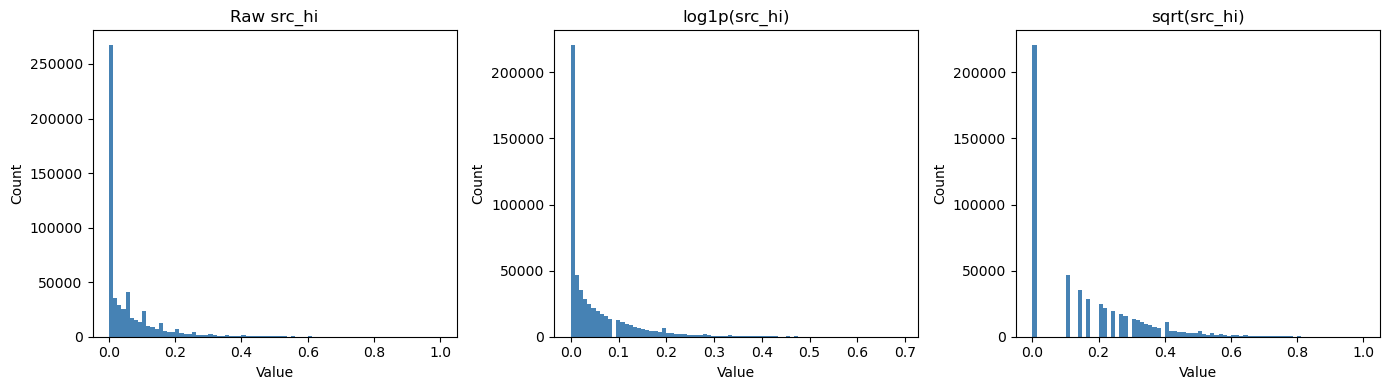

raw   — mean=0.0568  std=0.0897  max=1.0000
log1p — mean=0.0520  std=0.0773  max=0.6931
sqrt  — mean=0.1649  std=0.1720  max=1.0000
Saved → /mnt/c/Users/amehedi/Downloads/thomas/aligned/target_src_hi_log1p_aligned.tif


In [6]:
# CELL 1 — load target and plot distributions
import numpy as np
import rasterio
import matplotlib.pyplot as plt

TARGET = r"/mnt/c/Users/amehedi/Downloads/thomas/aligned/target_src_hi_aligned.tif"

with rasterio.open(TARGET) as src:
    arr = src.read(1).astype("float32")
    nodata = src.nodata

valid = arr[np.isfinite(arr) & (arr != nodata) & (arr >= 0)]

# three transforms to compare
log1p   = np.log1p(valid)           # log(1 + x), zero-safe
sqrt    = np.sqrt(valid)             # square root
raw     = valid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes,
    [raw, log1p, sqrt],
    ["Raw src_hi", "log1p(src_hi)", "sqrt(src_hi)"]):
    ax.hist(data, bins=80, color="steelblue", edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"raw   — mean={raw.mean():.4f}  std={raw.std():.4f}  max={raw.max():.4f}")
print(f"log1p — mean={log1p.mean():.4f}  std={log1p.std():.4f}  max={log1p.max():.4f}")
print(f"sqrt  — mean={sqrt.mean():.4f}  std={sqrt.std():.4f}  max={sqrt.max():.4f}")

# CELL 2 — save the transformed target (pick whichever looks best above)
import rasterio

TRANSFORM = "log1p"   # ← change to "sqrt" or "raw" to compare

with rasterio.open(TARGET) as src:
    arr = src.read(1).astype("float32")
    profile = src.profile.copy()
    nodata = src.nodata

valid_mask = np.isfinite(arr) & (arr != nodata) & (arr >= 0)
out = np.full(arr.shape, -9999.0, dtype="float32")

if TRANSFORM == "log1p":
    out[valid_mask] = np.log1p(arr[valid_mask])
elif TRANSFORM == "sqrt":
    out[valid_mask] = np.sqrt(arr[valid_mask])
else:
    out[valid_mask] = arr[valid_mask]

profile.update(dtype="float32", nodata=-9999.0)
out_path = TARGET.replace("target_src_hi_aligned.tif", f"target_src_hi_{TRANSFORM}_aligned.tif")
with rasterio.open(out_path, "w", **profile) as dst:
    dst.write(out, 1)

print(f"Saved → {out_path}")

In [3]:
from pathlib import Path
from datetime import date, timedelta
import requests
import zipfile

OUT = Path("/mnt/c/Users/amehedi/Downloads/thomas/prism")
OUT.mkdir(parents=True, exist_ok=True)

# Edit these dates if needed
date_windows = {
    "pre_lidar":  ("2016-04-28", "2016-05-28"),
    "event":      ("2018-01-08", "2018-01-11"),
    "post_lidar": ("2018-01-11", "2018-01-11"),
}

variables = ["ppt", "tmin", "tmax"]  # precipitation, min temp, max temp

def dates_between(start, end):
    d = date.fromisoformat(start)
    end = date.fromisoformat(end)
    while d <= end:
        yield d
        d += timedelta(days=1)

def download_prism(var, day, out_dir):
    ymd = day.strftime("%Y%m%d")
    url = f"https://services.nacse.org/prism/data/get/us/4km/{var}/{ymd}"

    zip_path = out_dir / var / f"PRISM_{var}_{ymd}.zip"
    extract_dir = out_dir / var / ymd
    extract_dir.mkdir(parents=True, exist_ok=True)
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if any(extract_dir.glob("*.bil")):
        print("exists:", var, ymd)
        return

    r = requests.get(url, timeout=120)
    r.raise_for_status()
    zip_path.write_bytes(r.content)

    if not zipfile.is_zipfile(zip_path):
        print("not a zip:", var, ymd)
        print("URL:", url)
        print(r.text[:300])
        zip_path.unlink()
        return

    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)

    print("downloaded:", var, ymd)

In [4]:

for window_name, (start, end) in date_windows.items():
    for var in variables:
        for day in dates_between(start, end):
            download_prism(var, day, OUT / window_name)

print("done:", OUT)

downloaded: ppt 20160428
downloaded: ppt 20160429
downloaded: ppt 20160430
downloaded: ppt 20160501
downloaded: ppt 20160502
downloaded: ppt 20160503
downloaded: ppt 20160504
downloaded: ppt 20160505
downloaded: ppt 20160506
downloaded: ppt 20160507
downloaded: ppt 20160508
downloaded: ppt 20160509
downloaded: ppt 20160510
downloaded: ppt 20160511
downloaded: ppt 20160512
downloaded: ppt 20160513
downloaded: ppt 20160514
downloaded: ppt 20160515
downloaded: ppt 20160516
downloaded: ppt 20160517
downloaded: ppt 20160518
downloaded: ppt 20160519
downloaded: ppt 20160520
downloaded: ppt 20160521
downloaded: ppt 20160522
downloaded: ppt 20160523
downloaded: ppt 20160524
downloaded: ppt 20160525
downloaded: ppt 20160526
downloaded: ppt 20160527
downloaded: ppt 20160528
downloaded: tmin 20160428
downloaded: tmin 20160429
downloaded: tmin 20160430
downloaded: tmin 20160501
downloaded: tmin 20160502
downloaded: tmin 20160503
downloaded: tmin 20160504
downloaded: tmin 20160505
downloaded: tmin 

In [5]:
from pathlib import Path
import requests
import zipfile
import shutil

OUT = Path("/mnt/c/Users/amehedi/Downloads/thomas/prism_single_layers")
OUT.mkdir(parents=True, exist_ok=True)

PRE_DATE = "20160528"   # pre-lidar date
POST_DATE = "20180111"  # post-lidar date

variables = ["ppt", "tmin", "tmax"]

def download_one_prism(var, ymd, label):
    url = f"https://services.nacse.org/prism/data/get/us/4km/{var}/{ymd}"
    
    tmp_zip = OUT / f"{var}_{label}.zip"
    tmp_dir = OUT / f"{var}_{label}_raw"
    final_tif = OUT / f"{var}_{label}.tif"
    
    if final_tif.exists():
        print("exists:", final_tif)
        return
    
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    tmp_zip.write_bytes(r.content)
    
    if not zipfile.is_zipfile(tmp_zip):
        print("not zip:", url)
        print(r.text[:300])
        return
    
    tmp_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(tmp_zip) as z:
        z.extractall(tmp_dir)
    
    tif = list(tmp_dir.glob("*.tif"))[0]
    shutil.copy(tif, final_tif)
    
    print("saved:", final_tif)

for var in variables:
    download_one_prism(var, PRE_DATE, "pre")
    download_one_prism(var, POST_DATE, "post")

saved: /mnt/c/Users/amehedi/Downloads/thomas/prism_single_layers/ppt_pre.tif
not zip: https://services.nacse.org/prism/data/get/us/4km/ppt/20180111
You have tried to download the file prism_ppt_us_25m_20180111.zip more than twice in one day (Pacific local time).  Note that repeated offenses may result in your IP address being blocked.
saved: /mnt/c/Users/amehedi/Downloads/thomas/prism_single_layers/tmin_pre.tif
not zip: https://services.nacse.org/prism/data/get/us/4km/tmin/20180111
You have tried to download the file prism_tmin_us_25m_20180111.zip more than twice in one day (Pacific local time).  Note that repeated offenses may result in your IP address being blocked.
saved: /mnt/c/Users/amehedi/Downloads/thomas/prism_single_layers/tmax_pre.tif
not zip: https://services.nacse.org/prism/data/get/us/4km/tmax/20180111
You have tried to download the file prism_tmax_us_25m_20180111.zip more than twice in one day (Pacific local time).  Note that repeated offenses may result in your IP addres

In [1]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================
import numpy as np
import rasterio
from rasterio.transform import Affine
from pathlib import Path
import pandas as pd
from scipy.ndimage import label as scipy_label

print("Imports OK")

# ================================================================
# CELL 2 — PATHS & FIXED SETTINGS (edit once)
# ================================================================
G_PRE_PATH   = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif"
DELTA_G_PATH = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif"
DDEM_PATH    = r"/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_LoD95_filtered_change.tif"
OUT_DIR      = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels")
OUT_DIR.mkdir(exist_ok=True)

BLOCK_SIZE   = 10   # fixed: 1m → 10m

# ================================================================
# CELL 3 — LOAD RASTERS ONCE (expensive — only run once)
# ================================================================
def _load(path, nodata=None):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = nodata if nodata is not None else src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        return arr, src.profile

g_pre,   PROF   = _load(G_PRE_PATH)
delta_g, _      = _load(DELTA_G_PATH)
ddem,    _      = _load(DDEM_PATH, nodata=-9999.0)

print(f"G_pre   {g_pre.shape}   [{np.nanmin(g_pre):.1f}, {np.nanmax(g_pre):.1f}]")
print(f"DeltaG  {delta_g.shape} [{np.nanmin(delta_g):.1f}, {np.nanmax(delta_g):.1f}]")
print(f"dDEM    {ddem.shape}    [{np.nanmin(ddem):.2f}, {np.nanmax(ddem):.2f}]")

# ================================================================
# CELL 4 — HELPER FUNCTIONS
# ================================================================
def make_tag(cfg: dict) -> str:
    bt = int(cfg["BINARY_THRESH"] * 100)
    return (
        f"c2c3"
        f"_dg{int(cfg['DELTA_G_LOD'])}"
        f"_gc{cfg['G_CHANNEL']}"
        f"_s{cfg['SCORE_HIGH_THRESH']}"
        f"_bt{bt}"
    )


def _block_reduce(arr, pad_h, pad_w, block):
    padded = np.pad(
        arr.astype("float32"),
        ((0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=np.nan,
    )
    H2, W2 = padded.shape
    return padded.reshape(H2 // block, block, W2 // block, block)


def _write(path, arr, dtype, nodata, transform, crs):
    H, W = arr.shape
    with rasterio.open(
        path, "w", driver="GTiff",
        height=H, width=W, count=1,
        dtype=dtype, crs=crs,
        transform=transform,
        nodata=nodata, compress="lzw",
    ) as dst:
        dst.write(arr.astype(dtype), 1)


def run_pipeline(cfg: dict) -> dict:
    G_CHANNEL         = cfg["G_CHANNEL"]
    DELTA_G_LOD       = cfg["DELTA_G_LOD"]
    SCORE_HIGH_THRESH = cfg["SCORE_HIGH_THRESH"]
    BINARY_THRESH     = cfg["BINARY_THRESH"]
    tag               = make_tag(cfg)

    # ── STEP 1: score each 1m pixel — C2 + C3 only, no C1 ──
    # c1 = (g_pre >= G_MIN) & (g_pre < G_CHANNEL)   # OMITTED
    c2 = delta_g > DELTA_G_LOD
    c3 = ddem    < 0.0

    score = c2.astype("uint8") + c3.astype("uint8")  # max = 2

    # ── STEP 2: still exclude main channels ──
    score[g_pre >= G_CHANNEL] = 0
    # score[g_pre < G_MIN] = 0   # REMOVED — no C1 floor

    # ── STEP 3: aggregate 1m → 10m ──
    H, W   = score.shape
    pad_h  = (BLOCK_SIZE - H % BLOCK_SIZE) % BLOCK_SIZE
    pad_w  = (BLOCK_SIZE - W % BLOCK_SIZE) % BLOCK_SIZE

    s = _block_reduce(score, pad_h, pad_w, BLOCK_SIZE)

    with np.errstate(all="ignore"):
        frac_hi    = np.nanmean(s >= SCORE_HIGH_THRESH,                axis=(1, 3))
        frac_med   = np.nanmean(s >= max(1, SCORE_HIGH_THRESH - 1),    axis=(1, 3))
        mean_score = np.nanmean(s,                                      axis=(1, 3))

    binary_10m = (frac_hi >= BINARY_THRESH).astype("uint8")

    # ── STEP 4: write outputs ──
    t0  = PROF["transform"]
    t10 = Affine(t0.a * BLOCK_SIZE, t0.b, t0.c,
                 t0.d, t0.e * BLOCK_SIZE, t0.f)
    crs = PROF["crs"]

    _write(OUT_DIR / f"src_conf_1m_{tag}.tif",  score,      "uint8",   255,    t0,  crs)
    _write(OUT_DIR / f"src_hi_{tag}.tif",        frac_hi,   "float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_med_{tag}.tif",       frac_med,  "float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_score_{tag}.tif",     mean_score,"float32", -9999., t10, crs)
    _write(OUT_DIR / f"src_bin_{tag}.tif",       binary_10m,"uint8",   255,    t10, crs)

    n_total_1m  = score.size
    n_pos_1m    = int((score >= SCORE_HIGH_THRESH).sum())
    n_total_10m = binary_10m.size
    n_pos_10m   = int(binary_10m.sum())

    stats = {
        "tag"               : tag,
        "DELTA_G_LOD"       : DELTA_G_LOD,
        "G_CHANNEL"         : G_CHANNEL,
        "SCORE_HIGH_THRESH" : SCORE_HIGH_THRESH,
        "BINARY_THRESH"     : BINARY_THRESH,
        "n_pos_1m"          : n_pos_1m,
        "pct_pos_1m"        : round(100 * n_pos_1m  / n_total_1m,  3),
        "n_pos_10m"         : n_pos_10m,
        "pct_pos_10m"       : round(100 * n_pos_10m / n_total_10m, 3),
    }
    print(f"[{tag}]  1m pos: {n_pos_1m:>8,} ({stats['pct_pos_1m']:.2f}%)  "
          f"| 10m pos: {n_pos_10m:>6,} ({stats['pct_pos_10m']:.2f}%)")
    return stats


def write_summary(results: list[dict], path: Path) -> None:
    df = pd.DataFrame(results)
    df.to_csv(path, index=False)
    print(f"\nSummary → {path}")
    print(df.to_string(index=False))

# ================================================================
# CELL 5 — RUNS  (SCORE_HIGH_THRESH=2 because max score is now 2)
# ================================================================
runs = [
    dict(DELTA_G_LOD=1, G_CHANNEL=120, SCORE_HIGH_THRESH=2, BINARY_THRESH=0.05),
]

# ================================================================
# CELL 6 — RUN ALL & WRITE SUMMARY
# ================================================================
results = [run_pipeline(cfg) for cfg in runs]
write_summary(results, OUT_DIR / "sensitivity_summary_c2c3.csv")

Imports OK
G_pre   (10986, 7425)   [0.0, 23199890.0]
DeltaG  (10986, 7425) [-23199888.0, 13161083.0]
dDEM    (10986, 7425)    [-28.45, 32.22]
[c2c3_dg1_gc120_s2_bt5]  1m pos: 3,903,147 (4.79%)  | 10m pos: 193,001 (23.64%)

Summary → /mnt/c/Users/amehedi/Downloads/source_zone_labels/sensitivity_summary_c2c3.csv
                  tag  DELTA_G_LOD  G_CHANNEL  SCORE_HIGH_THRESH  BINARY_THRESH  n_pos_1m  pct_pos_1m  n_pos_10m  pct_pos_10m
c2c3_dg1_gc120_s2_bt5            1        120                  2           0.05   3903147       4.785     193001       23.636


In [3]:
import numpy as np
import rasterio
from pathlib import Path

# ── Load rasters ──
def _load(path, nodata=None):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = nodata if nodata is not None else src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        return arr, src.profile

G_PRE_PATH   = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif"
DELTA_G_PATH = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif"
DDEM_PATH    = r"/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_LoD95_filtered_change.tif"
OUT_DIR      = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels")

g_pre,   PROF = _load(G_PRE_PATH)
delta_g, _    = _load(DELTA_G_PATH)
ddem,    _    = _load(DDEM_PATH, nodata=-9999.0)
print(f"Loaded  g_pre{g_pre.shape}  delta_g{delta_g.shape}  ddem{ddem.shape}")

# ════════════════════════════════
# CONTROLS — edit here
DELTA_G_LOD    = 1.0    # ΔG detection threshold
G_CHANNEL      = 120    # channel G threshold
MASK_CHANNELS  = False  # True = zero out channel pixels, False = keep them
# ════════════════════════════════

NODATA = 255

# ── Signals ──
c2 = delta_g > DELTA_G_LOD
c3 = ddem    < 0.0

# ── Optional channel mask ──
channel = (g_pre >= G_CHANNEL) if MASK_CHANNELS else np.zeros_like(g_pre, dtype=bool)

def _make(boolean_arr):
    return np.where(channel, NODATA, boolean_arr.astype("uint8")).astype("uint8")

c2_map    = _make(c2)
c3_map    = _make(c3)
c2_and_c3 = _make(c2 & c3)
c2_or_c3  = _make(c2 | c3)
score     = np.where(channel, NODATA, c2.astype("uint8") + c3.astype("uint8")).astype("uint8")

# ── Write ──
def _write(path, arr):
    H, W = arr.shape
    prof = PROF.copy()
    prof.update(driver="GTiff", height=H, width=W, count=1,
                dtype="uint8", nodata=NODATA, compress="lzw")
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr, 1)
    vals, counts = np.unique(arr[arr != NODATA], return_counts=True)
    summary = "  ".join(f"val={int(v)} n={c:,}" for v, c in zip(vals, counts))
    print(f"  {Path(path).name}  |  {summary}")

tag = f"dg{int(DELTA_G_LOD)}" + ("_gc120" if MASK_CHANNELS else "")

print(f"Writing 1m outputs  [channel mask: {MASK_CHANNELS}]...")
_write(OUT_DIR / f"1m_c2_{tag}.tif",          c2_map)
_write(OUT_DIR / f"1m_c3_{tag}.tif",          c3_map)
_write(OUT_DIR / f"1m_c2_and_c3_{tag}.tif",   c2_and_c3)
_write(OUT_DIR / f"1m_c2_or_c3_{tag}.tif",    c2_or_c3)
_write(OUT_DIR / f"1m_score_c2c3_{tag}.tif",  score)
print("Done.")

Loaded  g_pre(10986, 7425)  delta_g(10986, 7425)  ddem(10986, 7425)
Writing 1m outputs  [channel mask: False]...
  1m_c2_dg1.tif  |  val=0 n=61,780,691  val=1 n=19,790,359
  1m_c3_dg1.tif  |  val=0 n=73,111,539  val=1 n=8,459,511
  1m_c2_and_c3_dg1.tif  |  val=0 n=77,590,872  val=1 n=3,980,178
  1m_c2_or_c3_dg1.tif  |  val=0 n=57,301,358  val=1 n=24,269,692
  1m_score_c2c3_dg1.tif  |  val=0 n=57,301,358  val=1 n=20,289,514  val=2 n=3,980,178
Done.


Valid cells: 547,600
G_star  min=5.0  max=200.0  mean=82.4
p_obs   min=0.0000  max=1.0000  mean=0.0698


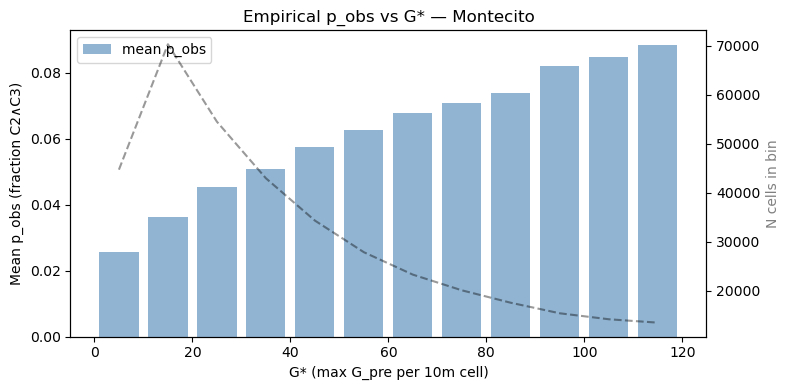

  G*=    5  mean_p_obs=0.0256  n=44,725
  G*=   15  mean_p_obs=0.0361  n=70,324
  G*=   25  mean_p_obs=0.0455  n=54,516
  G*=   35  mean_p_obs=0.0508  n=42,968
  G*=   45  mean_p_obs=0.0575  n=34,332
  G*=   55  mean_p_obs=0.0627  n=27,872
  G*=   65  mean_p_obs=0.0677  n=23,296
  G*=   75  mean_p_obs=0.0709  n=20,093
  G*=   85  mean_p_obs=0.0738  n=17,553
  G*=   95  mean_p_obs=0.0819  n=15,403
  G*=  105  mean_p_obs=0.0848  n=14,188
  G*=  115  mean_p_obs=0.0884  n=13,493


In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Load aligned rasters
ALIGNED = "/mnt/c/Users/amehedi/Downloads/thomas/aligned"

with rasterio.open(f"{ALIGNED}/p_obs_c2c3_aligned.tif") as src:
    p_obs = src.read(1).astype("float32")
    p_obs[p_obs == src.nodata] = np.nan

with rasterio.open(f"{ALIGNED}/G_star_aligned.tif") as src:
    g_star = src.read(1).astype("float32")
    g_star[g_star == src.nodata] = np.nan

# Flatten and drop NaNs
mask = np.isfinite(p_obs) & np.isfinite(g_star)
pv = p_obs[mask]
gv = g_star[mask]

print(f"Valid cells: {mask.sum():,}")
print(f"G_star  min={gv.min():.1f}  max={gv.max():.1f}  mean={gv.mean():.1f}")
print(f"p_obs   min={pv.min():.4f}  max={pv.max():.4f}  mean={pv.mean():.4f}")

# Bin G_star and compute mean p_obs per bin
bins = np.arange(0, 130, 10)  # 0-10, 10-20, ..., 110-120
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_mean_p  = []
bin_n       = []

for lo, hi in zip(bins[:-1], bins[1:]):
    in_bin = (gv >= lo) & (gv < hi)
    bin_mean_p.append(np.nanmean(pv[in_bin]) if in_bin.sum() > 0 else np.nan)
    bin_n.append(in_bin.sum())

bin_mean_p = np.array(bin_mean_p)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_centers, bin_mean_p, width=8, alpha=0.6, color="steelblue", label="mean p_obs")
ax.set_xlabel("G* (max G_pre per 10m cell)")
ax.set_ylabel("Mean p_obs (fraction C2∧C3)")
ax.set_title("Empirical p_obs vs G* — Montecito")
ax2 = ax.twinx()
ax2.plot(bin_centers, bin_n, "k--", alpha=0.4, label="n cells")
ax2.set_ylabel("N cells in bin", color="gray")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

for c, p, n in zip(bin_centers, bin_mean_p, bin_n):
    print(f"  G*={c:5.0f}  mean_p_obs={p:.4f}  n={n:,}")


Fitted Gamma: k=0.506  scale=200.000  amplitude=0.1197
  → mean C_eff = k × scale = 101.12  (units of G)


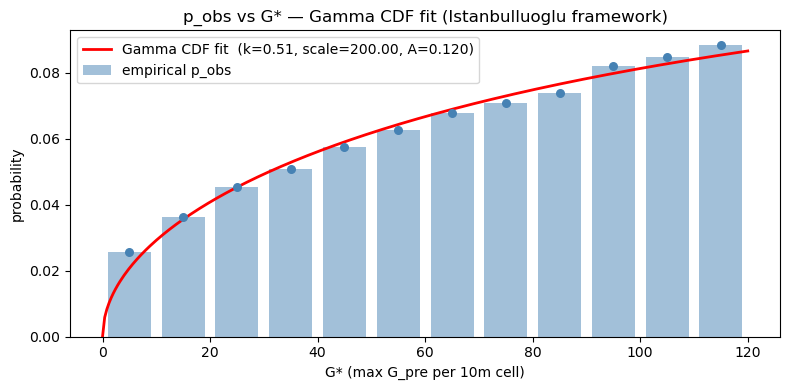

In [2]:
from scipy.stats import gamma
from scipy.optimize import curve_fit

# Scaled Gamma CDF: p_obs won't reach 1.0 (not all terrain produces rills)
# p_theory(G*) = A * Gamma_CDF(G*; k, scale)
def gamma_cdf_scaled(g, k, scale, amplitude):
    return amplitude * gamma.cdf(g, a=k, scale=scale)

# Use only valid bins for fitting
valid = ~np.isnan(bin_mean_p)
g_fit = bin_centers[valid]
p_fit = bin_mean_p[valid]

# Fit: k=shape, scale=1/rate, amplitude=max p_obs reachable
popt, pcov = curve_fit(
    gamma_cdf_scaled, g_fit, p_fit,
    p0=[2.0, 30.0, 0.10],
    bounds=([0.1, 0.1, 0.0], [20.0, 200.0, 1.0]),
    maxfev=5000
)
k_fit, scale_fit, amp_fit = popt
print(f"Fitted Gamma: k={k_fit:.3f}  scale={scale_fit:.3f}  amplitude={amp_fit:.4f}")
print(f"  → mean C_eff = k × scale = {k_fit * scale_fit:.2f}  (units of G)")

# Smooth curve for plotting
g_smooth = np.linspace(0, 120, 300)
p_smooth = gamma_cdf_scaled(g_smooth, *popt)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_centers, bin_mean_p, width=8, alpha=0.5, color="steelblue", label="empirical p_obs")
ax.plot(g_smooth, p_smooth, "r-", lw=2,
        label=f"Gamma CDF fit  (k={k_fit:.2f}, scale={scale_fit:.2f}, A={amp_fit:.3f})")
ax.scatter(g_fit, p_fit, color="steelblue", zorder=5, s=30)
ax.set_xlabel("G* (max G_pre per 10m cell)")
ax.set_ylabel("probability")
ax.set_title("p_obs vs G* — Gamma CDF fit (Istanbulluoglu framework)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_319638/901400919.py:15: RuntimeWarning: Mean of empty slice
  bin_mean_p = [np.nanmean(p_all[(g_all >= lo) & (g_all < hi)]) for lo, hi in zip(bins[:-1], bins[1:])]


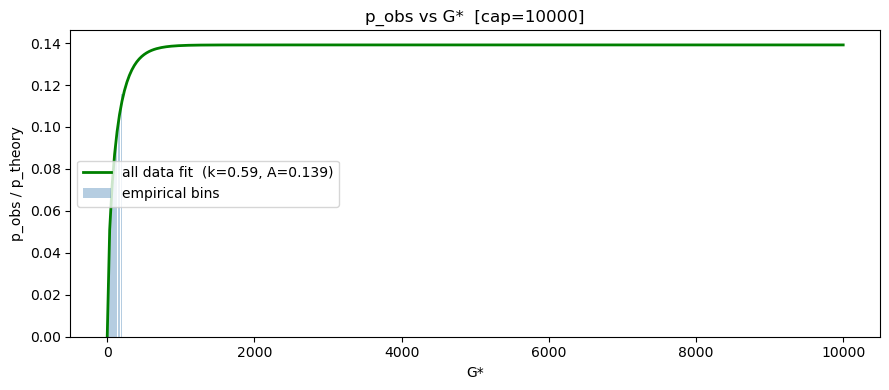

In [3]:
CAP = 10000  # change to None for all data, or any value like 120, 500

# Apply cap
if CAP is not None:
    mask_plot = np.isfinite(gv) & np.isfinite(pv) & (gv > 0) & (gv <= CAP)
else:
    mask_plot = np.isfinite(gv) & np.isfinite(pv) & (gv > 0)

g_all = gv[mask_plot]
p_all = pv[mask_plot]

# Bins
bins = np.arange(0, (CAP or 500) + 10, 10)
centers = (bins[:-1] + bins[1:]) / 2
bin_mean_p = [np.nanmean(p_all[(g_all >= lo) & (g_all < hi)]) for lo, hi in zip(bins[:-1], bins[1:])]

# Fit on all data within cap
popt_all, _ = curve_fit(gamma_cdf_scaled, g_all, p_all,
                        p0=[2.0, 30.0, 0.10],
                        bounds=([0.1, 0.1, 0.0], [20.0, 200.0, 1.0]), maxfev=10000)

g_smooth = np.linspace(0, CAP or 500, 300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(centers, bin_mean_p, width=8, alpha=0.4, color="steelblue", label="empirical bins")
ax.plot(g_smooth, gamma_cdf_scaled(g_smooth, *popt_all), "g-", lw=2,
        label=f"all data fit  (k={popt_all[0]:.2f}, A={popt_all[2]:.3f})")
ax.set_xlabel("G*")
ax.set_ylabel("p_obs / p_theory")
ax.set_title(f"p_obs vs G*  [cap={CAP}]")
ax.legend()
plt.tight_layout()
plt.show()

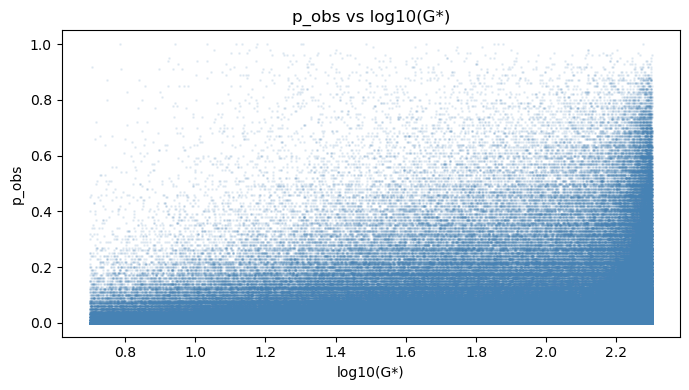

In [9]:
mask2 = np.isfinite(gv) & np.isfinite(pv) & (gv <= 1000000)

plt.figure(figsize=(7, 4))
plt.scatter(np.log10(gv[mask2]), pv[mask2], s=1, alpha=0.1, color="steelblue")
plt.xlabel("log10(G*)")
plt.ylabel("p_obs")
plt.title("p_obs vs log10(G*)")
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import rasterio
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from pathlib import Path

PRE = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre")

def _load(p):
    with rasterio.open(p) as src:
        arr = src.read(1).astype("float64")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

slope_pct = _load(PRE / "S_pre_percent.tif")
sca       = _load(PRE / "a_pre_dinf_sca.tif")

slope = slope_pct / 100.0          # percent → m/m
G     = slope * sca                # G = S × a

mask = (
    np.isfinite(slope) & np.isfinite(sca) &
    (slope > 0.001) & (slope < 2.0) & (sca > 1) &
    (G < 200)
)
s = slope[mask].ravel()
a = sca[mask].ravel()

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(np.log10(a), s, gridsize=150, cmap="Blues", norm=LogNorm(), mincnt=1)
plt.colorbar(hb, ax=ax, label="cell count (log)")

bins    = np.linspace(0, 4, 40)
centers = (bins[:-1] + bins[1:]) / 2
log_a   = np.log10(a)
means   = [np.nanmean(s[(log_a>=lo)&(log_a<hi)]) for lo,hi in zip(bins[:-1],bins[1:])]
ax.plot(centers, means, "r-o", lw=2, ms=4, label="bin mean")

ax.set_xlim(0, 4); ax.set_ylim(0, 1.5)
ax.set_xlabel("log10(SCA, m)"); ax.set_ylabel("Slope (m/m)")
ax.set_title("Slope-Area — pre-fire 1m  (G < 200, hillslopes only)")
ax.legend(); plt.tight_layout(); plt.show()


RasterioIOError: /mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/S_pre_percent.tif: No such file or directory

In [6]:
print(f"SCA max: {a.max():.1f}  →  log10={np.log10(a.max()):.2f}")
print(f"pixels with log10(SCA) > 4: {(np.log10(a) > 4).sum():,}")

SCA max: 17121820.0  →  log10=7.23
pixels with log10(SCA) > 4: 498,720


In [7]:
# At break: SCA ~ 25m, S ~ 0.57 m/m
ALPHA = 1.167
SCA_break = 25.0
S_break   = 0.57

G_channel = SCA_break * (S_break ** ALPHA)
print(f"G_channel = {G_channel:.2f}")

# Or from actual data at break point
break_mask = (np.log10(a) >= 1.3) & (np.log10(a) <= 1.5)
G_at_break = a[break_mask] * (s[break_mask] ** ALPHA)
print(f"G at break: mean={G_at_break.mean():.2f}  median={np.median(G_at_break):.2f}")


G_channel = 12.97
G at break: mean=13.53  median=13.75


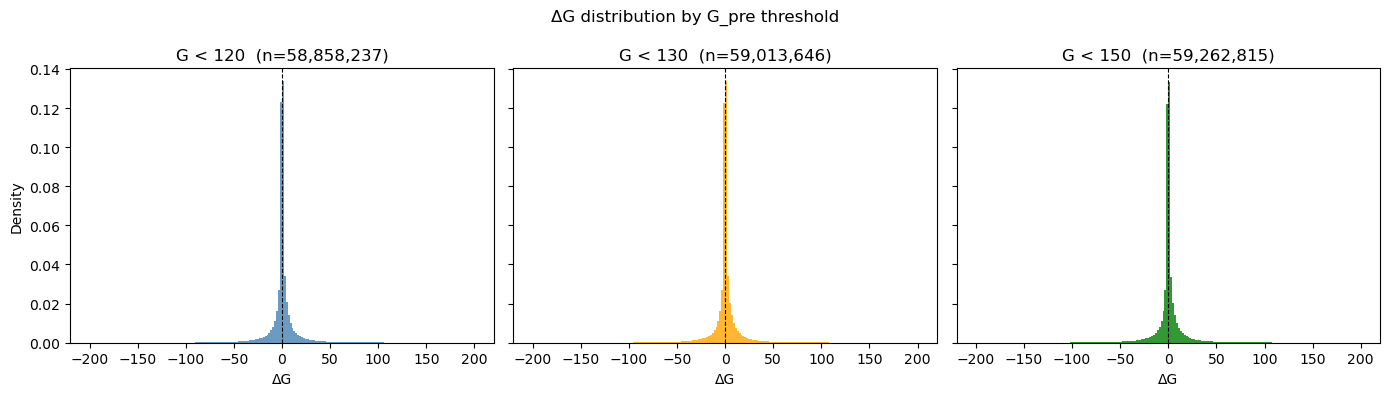

In [10]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/G_pre_dinf.tif") as src:
    g_pre = src.read(1).astype("float32")
    g_pre[g_pre == src.nodata] = np.nan

with rasterio.open("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/DeltaG_1m_dinf.tif") as src:
    delta_g = src.read(1).astype("float32")
    delta_g[delta_g == src.nodata] = np.nan

thresholds = [120, 130, 150]
colors     = ["steelblue", "orange", "green"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, thr, col in zip(axes, thresholds, colors):
    mask = (g_pre < thr) & np.isfinite(delta_g) & np.isfinite(g_pre)
    ax.hist(delta_g[mask], bins=200, range=(-200, 200),
            color=col, alpha=0.8, density=True)
    ax.axvline(0, color="k", lw=0.8, linestyle="--")
    ax.set_title(f"G < {thr}  (n={mask.sum():,})")
    ax.set_xlabel("ΔG")
axes[0].set_ylabel("Density")
plt.suptitle("ΔG distribution by G_pre threshold")
plt.tight_layout()
plt.show()

In [11]:
OUT = "/mnt/c/Users/amehedi/Downloads/source_zone_labels"

with rasterio.open("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/G_pre_dinf.tif") as src:
    profile = src.profile.copy()

profile.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")

for thr in thresholds:
    mask = (g_pre < thr).astype("float32")
    mask[~np.isfinite(g_pre)] = -9999.0
    out_path = f"{OUT}/G_pre_mask_lt{thr}.tif"
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(mask, 1)
    print(f"Saved -> {out_path}")


Saved -> /mnt/c/Users/amehedi/Downloads/source_zone_labels/G_pre_mask_lt120.tif
Saved -> /mnt/c/Users/amehedi/Downloads/source_zone_labels/G_pre_mask_lt130.tif
Saved -> /mnt/c/Users/amehedi/Downloads/source_zone_labels/G_pre_mask_lt150.tif


In [8]:
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

filtered_dem = "/home/abdullah/GeoNet/GeoOutputs/GIS/montecito/PM_filtered_grassgis.tif"
d8_fac_out   = "/home/abdullah/GeoNet/GeoOutputs/GIS/montecito/pre_dem_d8_fac.tif"

wbt.d8_flow_accumulation(filtered_dem, d8_fac_out, out_type="cells")
print("D8 accumulation done")


D8 accumulation done


Curvature: min=-1.998  max=2.000
D8 FAC:    min=1    max=1641253  p90=67


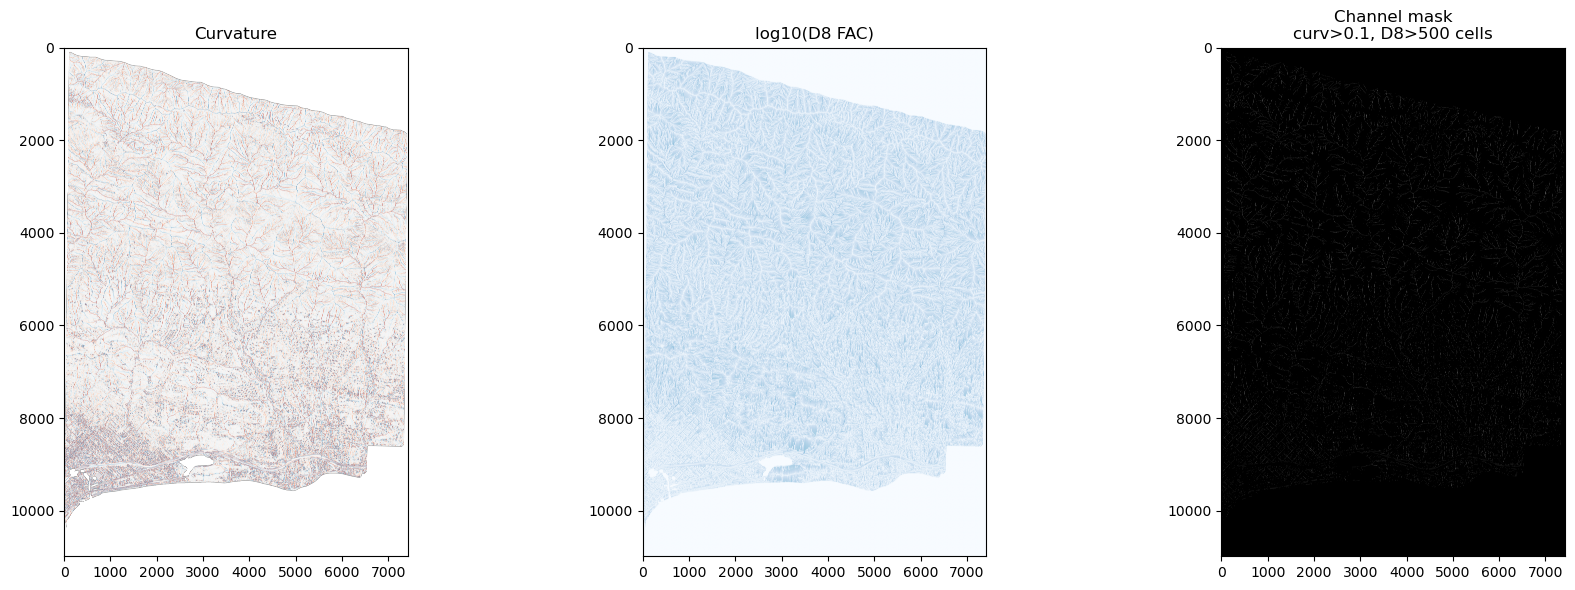

Channel pixels: 765,652  (0.9% of AOI)


In [9]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
    return arr

curv = load("/home/abdullah/GeoNet/GeoOutputs/GIS/montecito/pre_dem_curvature.tif")
d8   = load(d8_fac_out)

print(f"Curvature: min={np.nanmin(curv):.3f}  max={np.nanmax(curv):.3f}")
print(f"D8 FAC:    min={np.nanmin(d8):.0f}    max={np.nanmax(d8):.0f}  p90={np.nanpercentile(d8,90):.0f}")

# Try thresholds
curv_thr = 0.1     # positive curvature → concave
d8_thr   = 500     # at least 500 upstream pixels at 1m = 500 m²

channel = (curv > curv_thr) & (d8 > d8_thr)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(curv, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[0].set_title("Curvature")
axes[1].imshow(np.log10(d8 + 1), cmap="Blues")
axes[1].set_title("log10(D8 FAC)")
axes[2].imshow(channel, cmap="binary_r")
axes[2].set_title(f"Channel mask\ncurv>{curv_thr}, D8>{d8_thr} cells")
plt.tight_layout()
plt.show()

print(f"Channel pixels: {channel.sum():,}  ({100*channel.mean():.1f}% of AOI)")

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace
from pathlib import Path

DOWNLOADS = Path("/mnt/c/Users/amehedi/Downloads")
DEM_PATH  = "/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/final_pre_reference.tif"

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        prof = src.profile.copy()
    return arr, prof

dem, prof = load(DEM_PATH)
print(f"DEM shape: {dem.shape}  min={np.nanmin(dem):.1f}  max={np.nanmax(dem):.1f}")


DEM shape: (10986, 7425)  min=2.0  max=1179.9


In [2]:
sigmas = [2, 4, 8, 16]   # pixels = 2m, 4m, 8m, 16m at 1m resolution

# Fill NaNs with mean for convolution (restore after)
nan_mask = ~np.isfinite(dem)
dem_filled = dem.copy()
dem_filled[nan_mask] = np.nanmean(dem)

responses = []
for s in sigmas:
    # negative LoG → positive = concave = channel
    r = -gaussian_laplace(dem_filled, sigma=s)
    r[nan_mask] = np.nan
    responses.append(r)
    print(f"  sigma={s}m  min={np.nanmin(r):.4f}  max={np.nanmax(r):.4f}")

# Max response across all scales → picks each channel at its natural width
wavelet_curv = np.nanmax(np.stack(responses, axis=0), axis=0)
print(f"\nWavelet curvature: min={np.nanmin(wavelet_curv):.4f}  max={np.nanmax(wavelet_curv):.4f}")


  sigma=2m  min=-71.9921  max=59.1952
  sigma=4m  min=-14.8443  max=14.7209
  sigma=8m  min=-3.7726  max=3.7030
  sigma=16m  min=-0.9900  max=0.9190

Wavelet curvature: min=-0.8736  max=59.1952


/tmp/ipykernel_227656/1053056306.py:17: RuntimeWarning: All-NaN slice encountered
  wavelet_curv = np.nanmax(np.stack(responses, axis=0), axis=0)


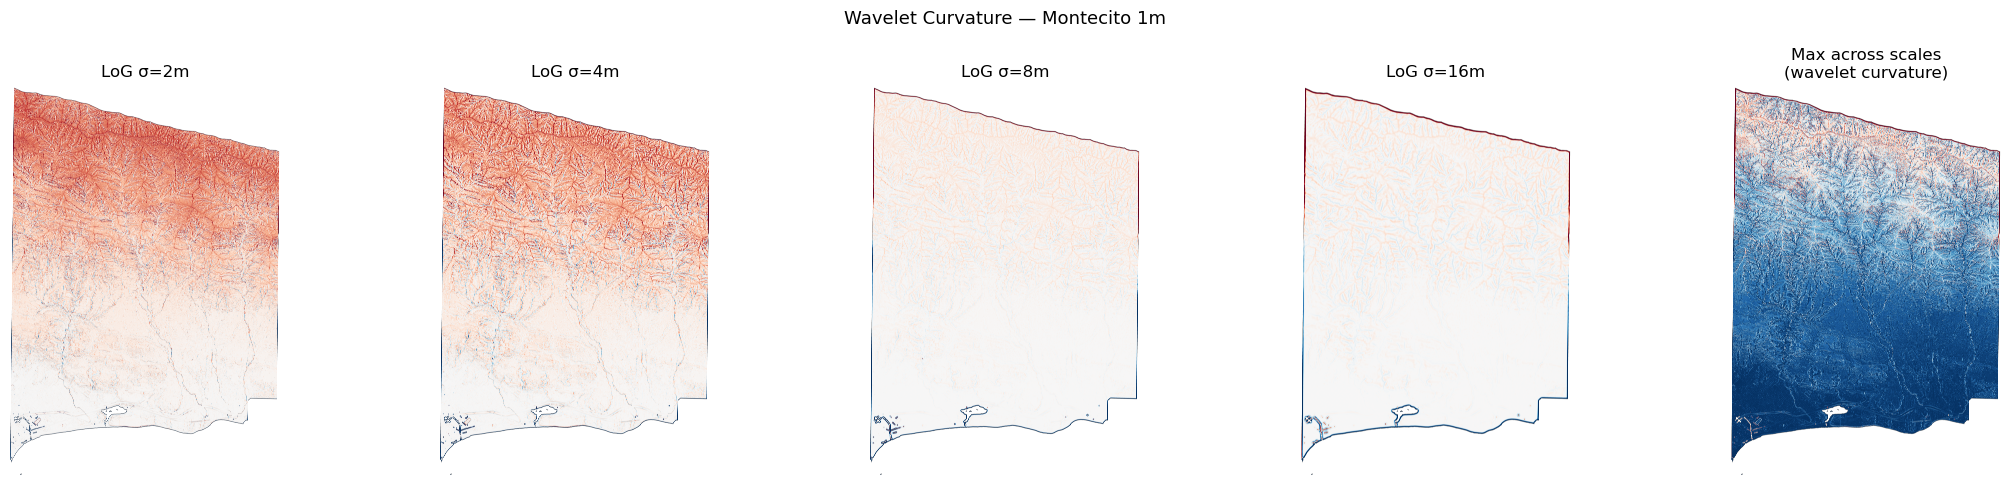

Plot saved.


In [3]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, (r, s) in enumerate(zip(responses, sigmas)):
    v = np.nanpercentile(np.abs(r), 99)
    axes[i].imshow(r, cmap="RdBu_r", vmin=-v, vmax=v)
    axes[i].set_title(f"LoG σ={s}m")
    axes[i].axis("off")

v = np.nanpercentile(wavelet_curv, 99)
axes[4].imshow(wavelet_curv, cmap="RdBu_r", vmin=0, vmax=v)
axes[4].set_title("Max across scales\n(wavelet curvature)")
axes[4].axis("off")

plt.suptitle("Wavelet Curvature — Montecito 1m", fontsize=13)
plt.tight_layout()
plt.savefig(DOWNLOADS / "wavelet_curvature_scales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")


In [4]:
def save(path, arr, prof):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    p   = prof.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    print(f"Saved -> {path}")

# Save wavelet curvature
save(DOWNLOADS / "wavelet_curvature_1m.tif", wavelet_curv, prof)

# Channel mask: threshold wavelet curvature
# Start with 99th percentile as threshold — adjust after visual check
thr = float(np.nanpercentile(wavelet_curv, 99))
print(f"Curvature threshold (99th pct): {thr:.4f}")

channel_wavelet = (wavelet_curv > thr).astype("float32")
channel_wavelet[nan_mask] = np.nan
save(DOWNLOADS / "channel_mask_wavelet_1m.tif", channel_wavelet, prof)

print(f"Channel pixels: {int(np.nansum(channel_wavelet==1)):,}  "
      f"({100*np.nanmean(channel_wavelet==1):.1f}% of AOI)")


Saved -> /mnt/c/Users/amehedi/Downloads/wavelet_curvature_1m.tif
Curvature threshold (99th pct): 0.3579
Saved -> /mnt/c/Users/amehedi/Downloads/channel_mask_wavelet_1m.tif
Channel pixels: 615,373  (0.8% of AOI)


In [29]:
import numpy as np
import rasterio

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        prof = src.profile.copy()
    return arr, prof

g_pre, prof = load("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/G_pre_dinf.tif")
elev, _     = load("/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/final_pre_reference.tif")

stable_1m = ((g_pre < 5) & (elev > 600)).astype("float32")
stable_1m[~np.isfinite(g_pre) | ~np.isfinite(elev)] = np.nan

out = np.where(np.isfinite(stable_1m), stable_1m, -9999.0).astype("float32")
p = prof.copy()
p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
with rasterio.open("/mnt/c/Users/amehedi/Downloads/stable_1m_G5_elev300.tif", "w", **p) as dst:
    dst.write(out, 1)

print(f"Stable pixels (G<5 AND elev>300): {int(np.nansum(stable_1m==1)):,}  ({100*np.nanmean(stable_1m==1):.1f}%)")

Stable pixels (G<5 AND elev>300): 6,109,889  (7.5%)


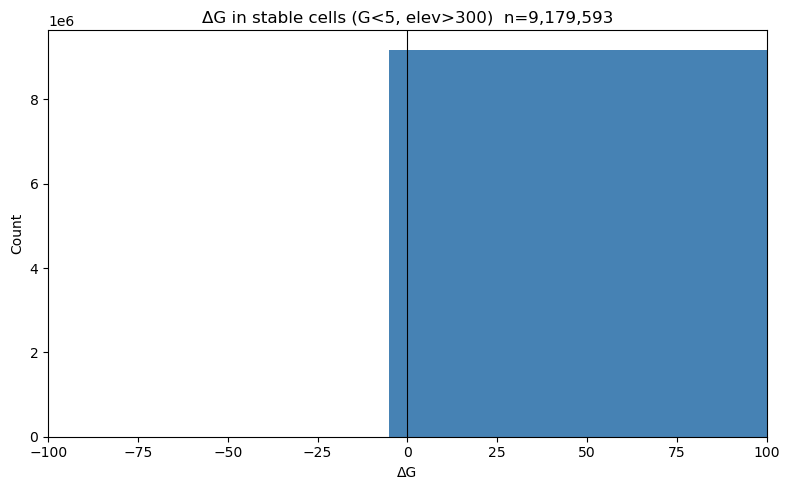

n        = 9,179,593
mean     = 287.2568
std      = 10805.2119
p95 |ΔG| = 36.0751


In [ ]:
dg, _ = load("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/DeltaG_1m_dinf.tif")

dg_stable = dg[(stable_1m == 1) & np.isfinite(dg)]

plt.figure(figsize=(8, 5))
plt.hist(dg_stable, bins=20, color="steelblue", edgecolor="none")
plt.xlim(-100, 100)
plt.xlabel("ΔG")
plt.ylabel("Count")
plt.title(f"ΔG in stable cells (G<5, elev>300)  n={len(dg_stable):,}")
plt.axvline(0, color="k", linewidth=0.8)
plt.tight_layout()
plt.savefig("/mnt/c/Users/amehedi/Downloads/dg_stable_G5_elev300_hist.png", dpi=150)
plt.show()

print(f"n        = {len(dg_stable):,}")
print(f"mean     = {dg_stable.mean():.4f}")
print(f"std      = {dg_stable.std():.4f}")
print(f"p95 |ΔG| = {np.percentile(np.abs(dg_stable), 95):.4f}")

In [30]:
dg, _ = load("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/DeltaG_1m_dinf.tif")
stable_lauren, _ = load("/mnt/c/Users/amehedi/Downloads/stable_1m_G5_elev300.tif")

dg_stable = dg[(stable_lauren == 1) & np.isfinite(dg)]

# Check percentiles first
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"p{p:2d}: {np.percentile(dg_stable, p):.4f}")

p 1: -2.4773
p 5: -1.2463
p25: 0.0757
p50: 1.6208
p75: 6.5754
p95: 39.6004
p99: 529.5500


In [31]:
nmad = 1.4826 * np.median(np.abs(dg_stable))
lod  = 2 * nmad
print(f"NMAD   = {nmad:.4f}")
print(f"LoD    = {lod:.4f}  (2×NMAD)")
print(f"p95 |ΔG| = {np.percentile(np.abs(dg_stable), 95):.4f}")

NMAD   = 2.7551
LoD    = 5.5103  (2×NMAD)
p95 |ΔG| = 39.6004


In [32]:
LOD = 5.51

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        prof = src.profile.copy()
    return arr, prof

dg, prof = load("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/DeltaG_1m_dinf.tif")

# Zero out pixels below LoD (noise), keep real signal
dg_lod = np.where(np.abs(dg) > LOD, dg, 0.0).astype("float32")
dg_lod[~np.isfinite(dg)] = np.nan

out = np.where(np.isfinite(dg_lod), dg_lod, -9999.0).astype("float32")
p = prof.copy()
p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
with rasterio.open("/mnt/c/Users/amehedi/Downloads/DeltaG_1m_LoD5p51_filtered.tif", "w", **p) as dst:
    dst.write(out, 1)

print(f"Pixels above LoD: {int(np.sum(np.abs(dg_lod) > 0)):,}")
print(f"Saved -> Downloads/DeltaG_1m_LoD5p51_filtered.tif")

Pixels above LoD: 21,026,478
Saved -> Downloads/DeltaG_1m_LoD5p51_filtered.tif


In [16]:
import numpy as np
import rasterio
from scipy.stats import gamma
from pathlib import Path

DOWNLOADS = Path("/mnt/c/Users/amehedi/Downloads")

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
        prof = src.profile.copy()
    return arr, prof

def save(path, arr, prof):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    p = prof.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    print(f"Saved -> {path}")

# ── Load ──────────────────────────────────────────────────────────────────
g_star, prof = load(DOWNLOADS / "source_zone_labels/G_star_10m.tif")
p_obs,  _    = load(DOWNLOADS / "source_zone_labels/p_obs_c2c3.tif")

# ── Step 1: Fit Gamma to G* distribution → get k ─────────────────────────
g_flat = g_star[np.isfinite(g_star) & (g_star > 0) & (g_star < 500)].ravel()
k_fit, _, scale_fit = gamma.fit(g_flat, floc=0)
print(f"k={k_fit:.4f}  scale={scale_fit:.4f}  mean G*={k_fit*scale_fit:.2f}")

# ── Step 2: Invert cell by cell → local scale + mean ─────────────────────
A = 0.102

valid = (np.isfinite(g_star) & np.isfinite(p_obs) &
         (g_star > 0) & (g_star < 500) & (p_obs > 0))

ratio    = np.full_like(p_obs, np.nan)
ratio[valid] = np.clip(p_obs[valid] / A, 1e-6, 1 - 1e-6)

quantile = np.full_like(p_obs, np.nan)
quantile[valid] = gamma.ppf(ratio[valid], a=k_fit)

scale_map = np.full_like(p_obs, np.nan)
mask = valid & (quantile > 0)
scale_map[mask] = g_star[mask] / quantile[mask]

mean_map = k_fit * scale_map

print(f"Mean map: min={np.nanmin(mean_map):.2f}  max={np.nanmax(mean_map):.2f}  median={np.nanmedian(mean_map):.2f}")

save(DOWNLOADS / "soil_resistance_scale_10m.tif", scale_map, prof)
save(DOWNLOADS / "soil_resistance_mean_10m.tif",  mean_map,  prof)


k=0.6112  scale=125.7727  mean G*=76.87
Mean map: min=0.00  max=16187.27  median=622.78
Saved -> /mnt/c/Users/amehedi/Downloads/soil_resistance_scale_10m.tif
Saved -> /mnt/c/Users/amehedi/Downloads/soil_resistance_mean_10m.tif


In [2]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from scipy.stats import gamma
from pathlib import Path

DOWNLOADS = Path("/mnt/c/Users/amehedi/Downloads")

# ── Load G_star (reference shape) ────────────────────────────────────────
with rasterio.open(DOWNLOADS / "source_zone_labels/G_star_10m.tif") as src:
    g_star = src.read(1).astype("float32")
    g_star[g_star == src.nodata] = np.nan
    H, W = src.height, src.width

# ── Load p_obs ────────────────────────────────────────────────────────────
with rasterio.open(DOWNLOADS / "source_zone_labels/p_obs_intersection.tif") as src:
    p_obs = src.read(1).astype("float32")
    p_obs[p_obs == src.nodata] = np.nan

# ── Load + resample elevation to match G_star ─────────────────────────────
with rasterio.open("/mnt/c/Users/amehedi/Downloads/thomas/dem_pre.tif") as src:
    elev = src.read(1, out_shape=(H, W), resampling=Resampling.bilinear).astype("float32")
    nd = src.nodata
    if nd is not None:
        elev[elev == nd] = np.nan

print(f"g_star:{g_star.shape}  p_obs:{p_obs.shape}  elev:{elev.shape}")

# ── Hillslope filter: elev > 600 AND 0 < G < 200 ─────────────────────────
hillslope = np.isfinite(g_star) & np.isfinite(elev) & (elev > 600) & (g_star > 0) & (g_star < 200)
g_flat = g_star[hillslope].ravel()
print(f"Hillslope cells: {len(g_flat):,}")

# ── Fit Gamma to G* on hillslopes ─────────────────────────────────────────
k_fit, _, scale_fit = gamma.fit(g_flat, floc=0)
print(f"k={k_fit:.4f}  scale={scale_fit:.4f}  mean={k_fit*scale_fit:.2f}")


g_star:(1099, 743)  p_obs:(1099, 743)  elev:(1099, 743)
Hillslope cells: 176,209
k=1.6574  scale=37.6092  mean=62.33


g_mean:(1099, 743)  p_obs:(1099, 743)  elev:(1099, 743)

Step 1 — Hillslope cells: 257,720
k=2.4426  scale=10.6846  mean G=26.10

Soil resistance C_eff:
  median=41.88  mean=51.21
Saved -> /mnt/c/Users/amehedi/Downloads/soil_resistance_scale_10m.tif
Saved -> /mnt/c/Users/amehedi/Downloads/soil_resistance_mean_10m.tif


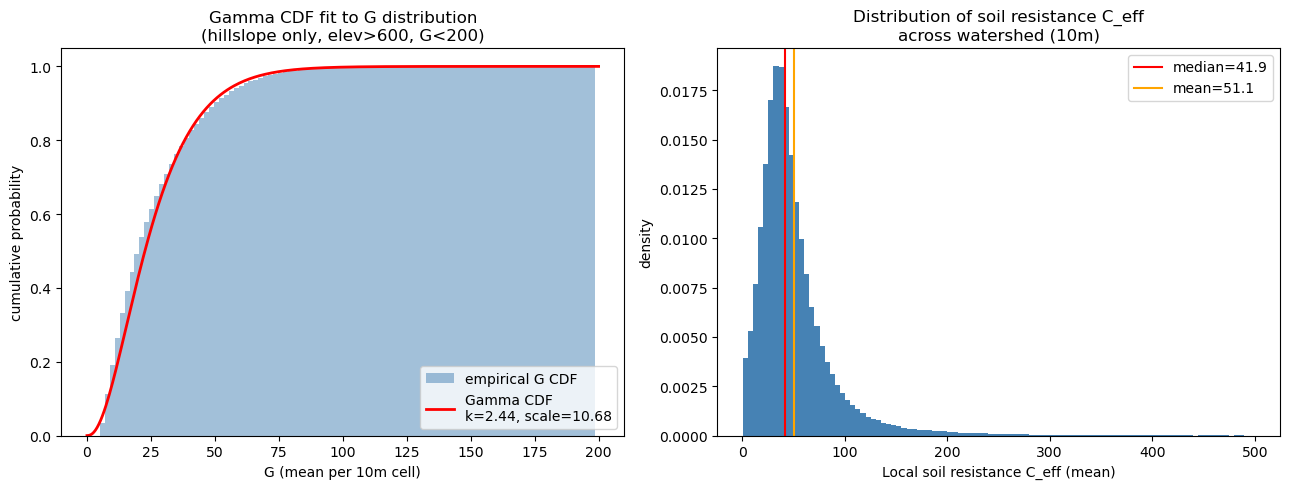

Saved -> erkan_gamma_results.png


In [13]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from scipy.stats import gamma
import matplotlib.pyplot as plt
from pathlib import Path

DOWNLOADS = Path("/mnt/c/Users/amehedi/Downloads")

def load_match(path, H, W):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=(H, W), resampling=Resampling.bilinear).astype("float32")
        nd = src.nodata
        if nd is not None:
            arr[arr == nd] = np.nan
    return arr

def save(path, arr, prof):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    p = prof.copy()
    p.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(out, 1)
    print(f"Saved -> {path}")

# ── Load G_mean (10m mean G, not max) ────────────────────────────────────
with rasterio.open(DOWNLOADS / "source_zone_labels/G_mean_10m.tif") as src:
    g_mean = src.read(1).astype("float32")
    g_mean[g_mean == src.nodata] = np.nan
    prof = src.profile.copy()
    H, W = src.height, src.width

# ── Load p_obs union ──────────────────────────────────────────────────────
with rasterio.open(DOWNLOADS / "source_zone_labels/p_obs_union.tif") as src:
    p_obs = src.read(1).astype("float32")
    p_obs[p_obs == src.nodata] = np.nan

# ── Load elevation resampled to match G_mean ──────────────────────────────
elev = load_match("/mnt/c/Users/amehedi/Downloads/thomas/dem_pre.tif", H, W)

print(f"g_mean:{g_mean.shape}  p_obs:{p_obs.shape}  elev:{elev.shape}")

# ── Step 1: Fit Gamma to G on hillslopes (elev>600, G<200) ───────────────
hillslope = (np.isfinite(g_mean) & np.isfinite(elev) &
             (elev > 600) & (g_mean > 0) & (g_mean < 200))
g_flat = g_mean[hillslope].ravel()
k_fit, _, scale_fit = gamma.fit(g_flat, floc=0)
print(f"\nStep 1 — Hillslope cells: {len(g_flat):,}")
print(f"k={k_fit:.4f}  scale={scale_fit:.4f}  mean G={k_fit*scale_fit:.2f}")

# ── Step 2: Inversion using p_obs ────────────────────────────────────────
valid = (np.isfinite(g_mean) & np.isfinite(p_obs) &
         (g_mean > 0) & (g_mean < 200) & (p_obs > 0))

ratio = np.full_like(p_obs, np.nan)
ratio[valid] = np.clip(p_obs[valid], 1e-6, 1 - 1e-6)

inv_std = np.full_like(g_mean, np.nan)
inv_std[valid] = gamma.ppf(ratio[valid], a=k_fit, scale=1)

scale_map = np.full_like(g_mean, np.nan)
mask = valid & (inv_std > 0)
scale_map[mask] = g_mean[mask] / inv_std[mask]
mean_map = k_fit * scale_map

print(f"\nSoil resistance C_eff:")
print(f"  median={np.nanmedian(mean_map):.2f}  mean={np.nanmean(mean_map):.2f}")

save(DOWNLOADS / "soil_resistance_scale_10m.tif", scale_map, prof)
save(DOWNLOADS / "soil_resistance_mean_10m.tif",  mean_map,  prof)

# ── Plot 1: Gamma CDF of G (terrain, goes to 1) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

g_range     = np.linspace(0, 200, 300)
cdf_terrain = gamma.cdf(g_range, a=k_fit, scale=scale_fit)

axes[0].hist(g_flat, bins=100, density=True, cumulative=True,
             color="steelblue", alpha=0.5, label="empirical G CDF")
axes[0].plot(g_range, cdf_terrain, "r-", lw=2,
             label=f"Gamma CDF\nk={k_fit:.2f}, scale={scale_fit:.2f}")
axes[0].set_xlabel("G (mean per 10m cell)")
axes[0].set_ylabel("cumulative probability")
axes[0].set_title("Gamma CDF fit to G distribution\n(hillslope only, elev>600, G<200)")
axes[0].legend()

# ── Plot 2: Soil resistance C_eff histogram ───────────────────────────────
mean_flat = mean_map[np.isfinite(mean_map) & (mean_map > 0) & (mean_map < 500)]
axes[1].hist(mean_flat, bins=100, color="steelblue", edgecolor="none", density=True)
axes[1].axvline(np.nanmedian(mean_flat), color="red",    lw=1.5, label=f"median={np.nanmedian(mean_flat):.1f}")
axes[1].axvline(np.nanmean(mean_flat),   color="orange", lw=1.5, label=f"mean={np.nanmean(mean_flat):.1f}")
axes[1].set_xlabel("Local soil resistance C_eff (mean)")
axes[1].set_ylabel("density")
axes[1].set_title("Distribution of soil resistance C_eff\nacross watershed (10m)")
axes[1].legend()

plt.tight_layout()
plt.savefig(DOWNLOADS / "erkan_gamma_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> erkan_gamma_results.png")


/tmp/ipykernel_321282/1354565908.py:29: RuntimeWarning: divide by zero encountered in log10
  hb = ax.hexbin(np.log10(a), s, gridsize=150, cmap="Blues", norm=LogNorm(), mincnt=1)
/tmp/ipykernel_321282/1354565908.py:34: RuntimeWarning: divide by zero encountered in log10
  log_a   = np.log10(a)
/tmp/ipykernel_321282/1354565908.py:35: RuntimeWarning: Mean of empty slice
  means   = [np.nanmean(s[(log_a>=lo)&(log_a<hi)]) for lo,hi in zip(bins[:-1],bins[1:])]


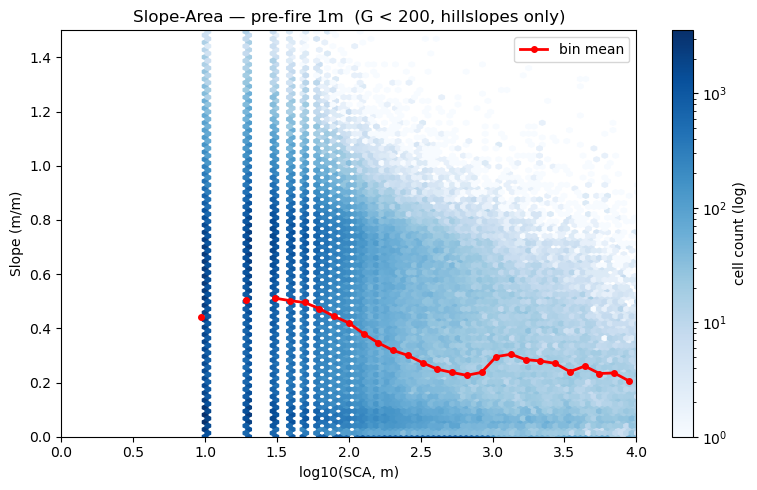

In [13]:
import numpy as np
import rasterio
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from pathlib import Path

THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

def _load(p):
    with rasterio.open(p) as src:
        arr = src.read(1).astype("float64")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

slope = _load(THOMAS / "S_from_topographic_elevation.tif")
sca   = _load(THOMAS / "a_from_topographic_elevation.tif")
G     = _load(THOMAS / "G_before.tif")

mask = (
    np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G)
    # (slope > 0.001) & (slope < 2.0) & (sca > 1)
    # (G < 10000)
)
s = slope[mask].ravel()
a = sca[mask].ravel()

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(np.log10(a), s, gridsize=150, cmap="Blues", norm=LogNorm(), mincnt=1)
plt.colorbar(hb, ax=ax, label="cell count (log)")

bins    = np.linspace(0, 4, 40)
centers = (bins[:-1] + bins[1:]) / 2
log_a   = np.log10(a)
means   = [np.nanmean(s[(log_a>=lo)&(log_a<hi)]) for lo,hi in zip(bins[:-1],bins[1:])]
ax.plot(centers, means, "r-o", lw=2, ms=4, label="bin mean")

ax.set_xlim(0, 4); ax.set_ylim(0, 1.5)
ax.set_xlabel("log10(SCA, m)"); ax.set_ylabel("Slope (m/m)")
ax.set_title("Slope-Area — pre-fire 1m  (G < 200, hillslopes only)")
ax.legend(); plt.tight_layout(); plt.show()


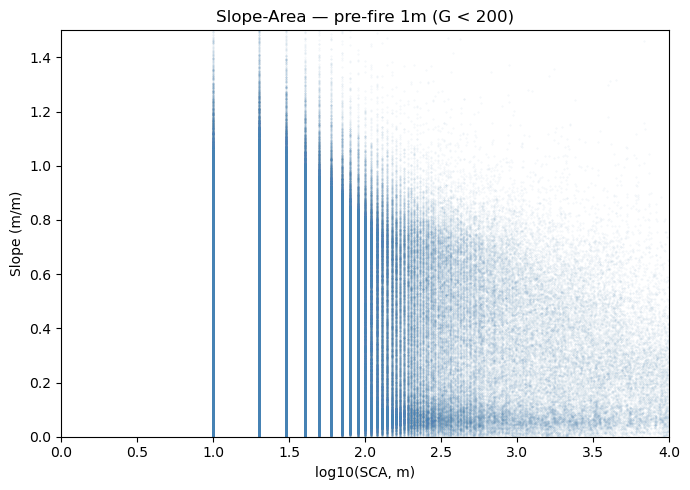

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log10(a), s, s=0.1, alpha=0.1, color="steelblue", rasterized=True)
ax.set_xlim(0, 4); ax.set_ylim(0, 1.5)
ax.set_xlabel("log10(SCA, m)"); ax.set_ylabel("Slope (m/m)")
ax.set_title("Slope-Area — pre-fire 1m (G < 200)")
plt.tight_layout(); plt.show()


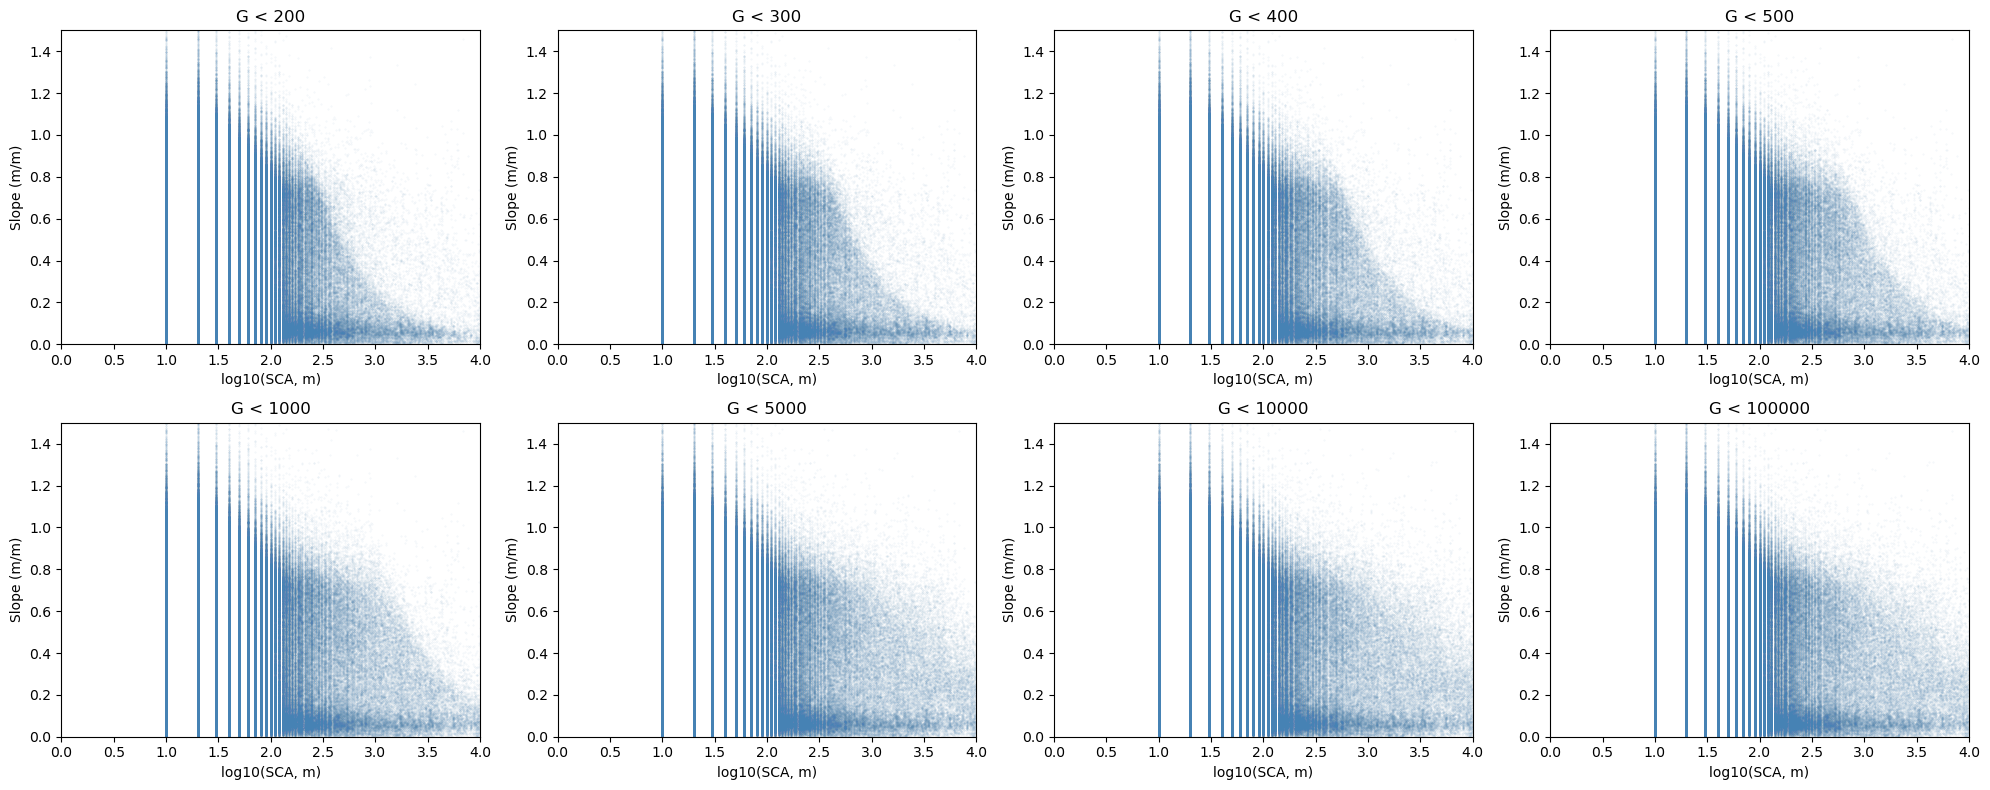

In [ ]:
thresholds = [200, 300, 400, 500, 1000, 5000, 10000, 100000]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for ax, thr in zip(axes, thresholds):
    m = np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G) & \
        (slope > 0.001) & (slope < 2.0) & (sca > 1) & (G < thr)
    ax.scatter(np.log10(sca[m]), slope[m], s=0.1, alpha=0.1, color="steelblue", rasterized=True)
    ax.set_xlim(0, 4); ax.set_ylim(0, 1.5)
    ax.set_title(f"G < {thr}")
    ax.set_xlabel("log10(SCA, m)")
    ax.set_ylabel("Slope (m/m)")

plt.tight_layout()
plt.show()

Saved S_pre_10m.tif  (1098, 742)
Saved a_pre_10m.tif  (1098, 742)
Saved G_pre_10m.tif  (1098, 742)


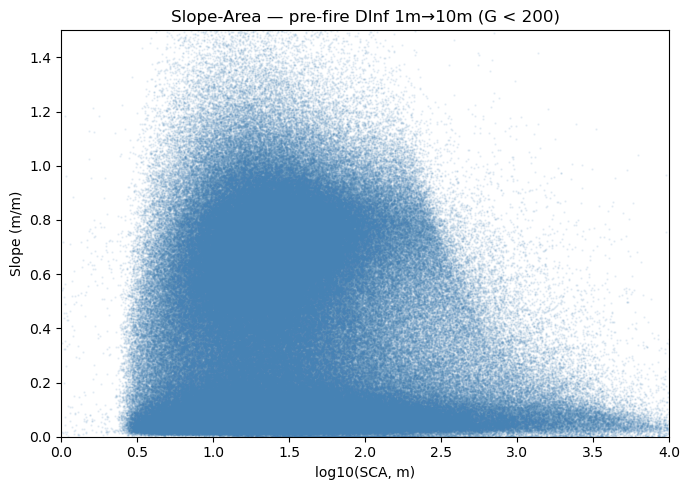

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from pathlib import Path
import matplotlib.pyplot as plt

SRC = Path("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta")
OUT = Path("/mnt/c/Users/amehedi/Downloads/thomas/G_1m_dinf_delta/10m")
OUT.mkdir(exist_ok=True)

SCALE = 10  # 1m → 10m

def resample_to_10m(src_path, dst_path):
    with rasterio.open(src_path) as src:
        data = src.read(
            1,
            out_shape=(src.height // SCALE, src.width // SCALE),
            resampling=Resampling.average
        ).astype("float32")
        nd = src.nodata
        if nd is not None:
            data[data == nd] = np.nan
        prof = src.profile.copy()
        prof.update(height=data.shape[0], width=data.shape[1],
                    transform=src.transform * src.transform.scale(SCALE, SCALE),
                    dtype="float32", nodata=-9999.0, compress="lzw")
    out = np.where(np.isfinite(data), data, -9999.0)
    with rasterio.open(dst_path, "w", **prof) as dst:
        dst.write(out, 1)
    print(f"Saved {dst_path.name}  {data.shape}")
    return data

slope_pct = resample_to_10m(SRC / "S_pre_percent.tif", OUT / "S_pre_10m.tif")
sca       = resample_to_10m(SRC / "a_pre_dinf_sca.tif", OUT / "a_pre_10m.tif")
G         = resample_to_10m(SRC / "G_pre_dinf.tif",     OUT / "G_pre_10m.tif")

slope = slope_pct / 100.0

# mask = (np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G) &
#         (slope > 0.001) & (slope < 2.0) & (sca > 1) & (G > 200))

mask = (np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G) & (sca > 1) & (G < 200))

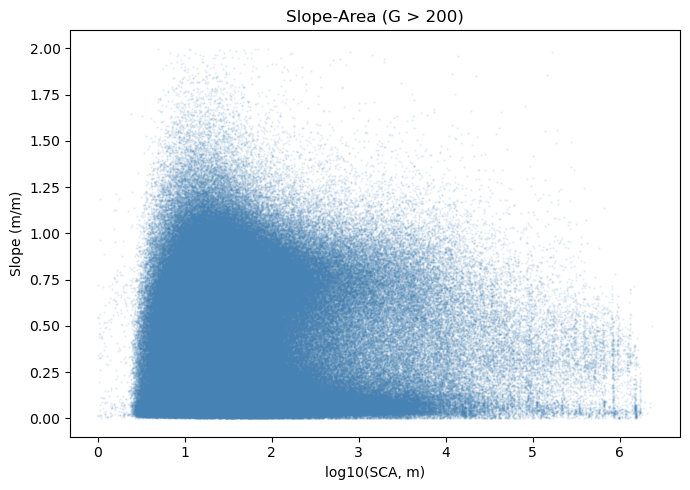

In [20]:
# mask = (np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G) &
#         (slope > 0.001) & (slope < 2.0) & (sca > 1) & (G > 200))

mask = (np.isfinite(slope) & np.isfinite(sca) & np.isfinite(G) &
        (slope > 0.001) & (slope < 2.0) & (sca > 1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log10(sca[mask]), slope[mask], s=0.5, alpha=0.1, color="steelblue", rasterized=True)
#ax.set_xlim(0, 4); ax.set_ylim(0, 1.5)
ax.set_xlabel("log10(SCA, m)"); ax.set_ylabel("Slope (m/m)")
ax.set_title("Slope-Area (G > 200)")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from scipy.stats import gamma
from pathlib import Path

LABELS = Path("/mnt/c/Users/amehedi/Downloads/source_zone_labels")
DEM_PRE = "/mnt/c/Users/amehedi/Downloads/thomas/dem_pre.tif"

def _load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

g_mean = _load(LABELS / "G_mean_10m.tif")
p_obs  = _load(LABELS / "p_obs_union.tif")
H, W   = g_mean.shape

with rasterio.open(DEM_PRE) as src:
    elev = src.read(1, out_shape=(H, W), resampling=Resampling.bilinear).astype("float32")
    if src.nodata is not None:
        elev[elev == src.nodata] = np.nan

print(f"g_mean: {g_mean.shape}  p_obs: {p_obs.shape}  elev: {elev.shape}")


k=2.4426  scale=10.6846  mean G=26.10  n=257,720


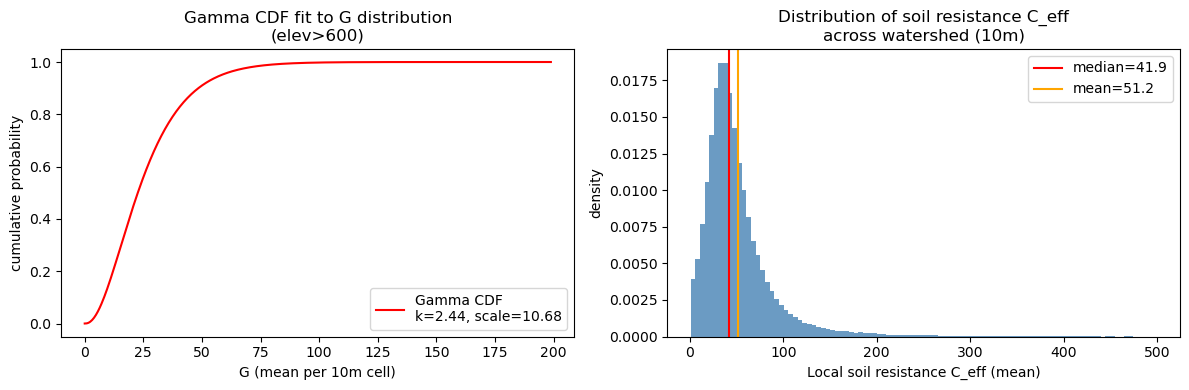

In [31]:
from scipy.stats import gamma
import matplotlib.pyplot as plt
import numpy as np

# hillslope filter: elev > 600 only, no G cap
hillslope = np.isfinite(g_mean) & np.isfinite(elev) & (elev > 600) & (g_mean < 10000)
g_flat = g_mean[hillslope].ravel()

k_fit, _, scale_fit = gamma.fit(g_flat, floc=0)
print(f"k={k_fit:.4f}  scale={scale_fit:.4f}  mean G={k_fit*scale_fit:.2f}  n={len(g_flat):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — Gamma CDF
ax = axes[0]
g_sorted = np.sort(g_flat)
ecdf = np.arange(1, len(g_sorted)+1) / len(g_sorted)
# ax.step(g_sorted, ecdf, where="post", alpha=0.4, label="empirical G CDF")
g_range = np.linspace(0, g_flat.max(), 500)
ax.plot(g_range, gamma.cdf(g_range, a=k_fit, scale=scale_fit), "r-",
        label=f"Gamma CDF\nk={k_fit:.2f}, scale={scale_fit:.2f}")
ax.set_xlabel("G (mean per 10m cell)")
ax.set_ylabel("cumulative probability")
ax.set_title("Gamma CDF fit to G distribution\n(elev>600)")
ax.legend()

# Right — C_eff histogram
valid = np.isfinite(g_mean) & np.isfinite(p_obs) & (g_mean > 0) & (p_obs > 0)
ratio = np.clip(p_obs[valid], 1e-6, 1-1e-6)
inv_std = gamma.ppf(ratio, a=k_fit, scale=1)
mask2 = inv_std > 0
ceff = np.full(g_mean.shape, np.nan)
ceff_vals = k_fit * (g_mean[valid][mask2] / inv_std[mask2])

ax = axes[1]
ax.hist(ceff_vals[ceff_vals < 500], bins=100, density=True, color="steelblue", alpha=0.8)
ax.axvline(np.median(ceff_vals), color="red",    lw=1.5, label=f"median={np.median(ceff_vals):.1f}")
ax.axvline(np.mean(ceff_vals),   color="orange", lw=1.5, label=f"mean={np.mean(ceff_vals):.1f}")
ax.set_xlabel("Local soil resistance C_eff (mean)")
ax.set_ylabel("density")
ax.set_title("Distribution of soil resistance C_eff\nacross watershed (10m)")
ax.legend()

plt.tight_layout()
plt.show()